# 1. Project Motivation
---
With the large amount of news published online every day, it is becoming more difficult to manually organize articles into the right categories. Automatic news classification helps solve this problem by allowing computer systems to sort news articles quickly and accurately. This is useful for news websites, recommendation systems, search engines, and other applications that need to manage large volumes of text data.

This project uses the AG News Classification Dataset, which contains news articles grouped into four categories: World, Sports, Business, and Science/Technology. The dataset is widely used in natural language processing because it is well-structured and suitable for training and testing text classification models.

The motivation for this project is to explore how machine learning can be used to classify text automatically. By building a model on this dataset, the project shows how NLP techniques can help improve the organization of digital news content and support faster access to relevant information.


# 2. Description of the Business Problem
---
The main objective of this project is to compare different text classification approaches on the AG News dataset in order to automatically categorize news articles into the classes World, Sports, Business, and Science/Technology. This project compares alternative machine learning or deep learning models to determine which approach achieves stronger classification accuracy and better generalization on real-world news text data.

# 3. Description of the Dataset / Data Source
---

## 3.1 Description

Dataset: **AG News Classification**
- A collection of more than 1 million news articles gathered from more than 2,000 news sources by ComeToMyHead, an academic news search engine running since July 2004.

- It consists of news articles collected over more than one year of activity.

- The dataset was provided by the academic community for research purposes, including data mining tasks such as clustering and classification, information retrieval tasks such as ranking and search, XML research, data compression, data streaming, and other non-commercial activities.

- The AG’s News Topic Classification Dataset was constructed by selecting the 4 largest classes from the original AG corpus. These classes are World, Sports, Business, and Science/Technology.

- Each class contains 30,000 training samples and 1,900 testing samples, giving a total of 120,000 training samples and 7,600 testing samples.

- In the commonly used classification version of the dataset, each record includes a class label, a news title, and a news description, making it suitable for supervised text classification tasks.

- The complete dataset can be found at Kaggle: [AG News Classification Dataset.](https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset)

## 3.2 Dataset Structure

The dataset is divided into two .csv files and is organized within the `data\` folder, as outlined below:

- `train.csv`: This file includes 120,000 samples for training set.
- `test.csv`: This file includes 7,600 samples for testing set.

## 3.3 Load and Analyze the Data
In this section, we begin by setting up the working environment and preparing the dataset for analysis. If running in Google Colab, the workflow includes mounting the Google Drive to access project files and datasets. Next, we define the project directory structure, organizing paths for `data/`, `plots/`, `models/` and `saved_models/` to ensure consistency and reproducibility.  

Once the environment is configured, the dataset is loaded and explored through initial analysis steps outlined in the **EDA in Section 4**.

In [1]:
# Optional installation - uncomment and run if needed
#!pip install pandas numpy scipy seaborn scikit-learn matplotlib tensorflow torch torchvision transformers pandoc

In [2]:
%%capture
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math
import re
import torch
import torch.nn as nn
import gc
import tensorflow as tf
import torch.utils.data
import torch.nn.functional as F
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM
from pathlib import Path
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import get_linear_schedule_with_warmup
from transformers import (AutoConfig, AutoModelForSequenceClassification, AutoTokenizer)
from transformers import RobertaModel, RobertaTokenizer
from transformers import RobertaConfig, RobertaForSequenceClassification
from transformers import AutoModel

os.environ["DISABLE_WIDGETS"] = "1"
os.environ["HF_HOME"] = "./hf_cache"

# Detect Colab
IN_COLAB = False
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    pass

if IN_COLAB:
    from google.colab import drive

    drive.mount('/content/drive', force_remount=True) # Added force_remount=True

    # Teacher/local Colab: change this one line only if folder is elsewhere
    PROJECT_ROOT = Path('/content/drive/MyDrive/tafe/src/news')

    print("Google Drive mounted successfully.")
else:
    # Local machine: notebook is inside news
    PROJECT_ROOT = Path.cwd().resolve()

SAVED_MODELS_DIR = PROJECT_ROOT / 'saved_models'
PLOTS_DIR = PROJECT_ROOT / 'plots'
DATA_DIR = PROJECT_ROOT / 'data'
MODELS_DIR = PROJECT_ROOT / 'models'

for d in [SAVED_MODELS_DIR, PLOTS_DIR, DATA_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("IN_COLAB:", IN_COLAB)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SAVED_MODELS_DIR:", SAVED_MODELS_DIR)
print("PLOTS_DIR:", PLOTS_DIR)
print("DATA_DIR:", DATA_DIR)
print("MODELS_DIR:", MODELS_DIR)

def safe_torch_save(obj, path):
    temp_path = path + ".tmp"
    torch.save(obj, temp_path)
    os.replace(temp_path, path)

# ----------------------------
# Predownload DeBERTa-v3 model
# ----------------------------
deberta_save_path = MODELS_DIR / "deberta-v3-base"
deberta_save_path.mkdir(parents=True, exist_ok=True)

# Load config with custom dropout
deberta_config = AutoConfig.from_pretrained(
    "microsoft/deberta-v3-base",
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)

# Download model from HF
deberta_model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-base",
    config=deberta_config
)

# Download tokenizer
deberta_tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")

# Save locally
deberta_model.save_pretrained(deberta_save_path)
deberta_tokenizer.save_pretrained(deberta_save_path)
print("DeBERTa v3 model downloaded and saved locally.")

# ----------------------------
# Predownload RoBERTa model
# ----------------------------
roberta_save_path = MODELS_DIR / "roberta-base"
roberta_save_path.mkdir(parents=True, exist_ok=True)

roberta_config = RobertaConfig.from_pretrained(
    "roberta-base",
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)

# Download from HF
roberta_model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    config=roberta_config
)
roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# Save locally
roberta_model.save_pretrained(roberta_save_path)
roberta_tokenizer.save_pretrained(roberta_save_path)

print("RoBERTa model downloaded and saved locally.")

# ----------------------------
# Predownload Electra model
# ----------------------------
electra_save_path = MODELS_DIR / "electra-base-discriminator"
electra_save_path.mkdir(parents=True, exist_ok=True)

# Load config with custom dropout
electra_config = AutoConfig.from_pretrained(
    "google/electra-base-discriminator",
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)

# Download model from HF
electra_model = AutoModelForSequenceClassification.from_pretrained(
    "google/electra-base-discriminator",
    config=electra_config
)

# Download tokenizer
electra_tokenizer = AutoTokenizer.from_pretrained("google/electra-base-discriminator")

# Save locally
electra_model.save_pretrained(electra_save_path)
electra_tokenizer.save_pretrained(electra_save_path)

print("Electra model downloaded and saved locally.")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
# ---------------- CONFIG ----------------
random_state = 42
batch_size = 64

# Print data files to use
print(os.listdir(DATA_DIR))

['train.csv', 'test.csv', 'glove.6B.300d.txt']


# 4. Exploratory Data Analysis (EDA) and Data Preparation Process

## 4.1 Dataset Exploration

The AG News dataset was first explored to understand its structure, class distribution, and text characteristics. The training and testing datasets were loaded from CSV files, and the columns were labeled as class index, title, and description. Missing values and duplicate records were checked to ensure data quality. In addition, text length and word count distributions were examined for the title and description fields to better understand the size and variability of the input text before preprocessing and model training.

**Dataset Loading and Inspection.** The AG News training and test datasets were loaded from CSV files and inspected to verify their structure, attributes, and dimensions. The first few records were examined to ensure the data was imported correctly and to gain an initial understanding of the dataset contents.

In [4]:
# Load train and test CSV files
train_df = pd.read_csv(DATA_DIR / "train.csv", header=0)
test_df = pd.read_csv(DATA_DIR / "test.csv", header=0)

# Assign column names
train_df.columns = train_df.columns.str.strip().str.lower().str.replace(" ", "_")
test_df.columns = test_df.columns.str.strip().str.lower().str.replace(" ", "_")

# Check columns
print(f"Training data columns: {train_df.columns}")
print(f"Test data columns: {test_df.columns}")

# Check the first few rows
print("Training data:")
print(train_df.head())

print("\nTest data:")
print(test_df.head())

# Check shapes
print("\nTrain shape:", train_df.shape)
print("Test shape:", test_df.shape)

Training data columns: Index(['class_index', 'title', 'description'], dtype='object')
Test data columns: Index(['class_index', 'title', 'description'], dtype='object')
Training data:
   class_index                                              title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  

Test data:
   class_index                                              

The above confirms that the AG News dataset was successfully loaded. The training set contains 120,000 records, while the test set contains 7,600 records. The dataset consists of news articles and their corresponding class labels used for supervised text classification.  

**Data Structure Verification.** The dataset columns and data types were examined to verify that each attribute was imported correctly. This step ensured that the class labels were represented using appropriate numeric data types and that the news article content was stored as text data suitable for subsequent preprocessing and model training.

In [5]:
# Check column info and data types
print(train_df.info())
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   class_index  120000 non-null  int64 
 1   title        120000 non-null  object
 2   description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   class_index  7600 non-null   int64 
 1   title        7600 non-null   object
 2   description  7600 non-null   object
dtypes: int64(1), object(2)
memory usage: 178.3+ KB
None


**Text Column Standardization.** The text-related columns were explicitly assigned a string data type to ensure consistent handling of textual information throughout preprocessing and model training. This step helps prevent data type inconsistencies and facilitates subsequent natural language processing operations.

In [6]:
# Make text columns explicit
train_df["title"] = train_df["title"].astype(str)
train_df["description"] = train_df["description"].astype(str)
test_df["title"] = test_df["title"].astype(str)
test_df["description"] = test_df["description"].astype(str)

**Missing Value Analysis.** The dataset was examined for missing or null values to assess data quality and completeness. This verification step ensured that all required information was available and that no additional imputation or data cleaning procedures were necessary.

In [7]:
# Check for missing values
print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in test data:")
print(test_df.isnull().sum())

Missing values in training data:
class_index    0
title          0
description    0
dtype: int64

Missing values in test data:
class_index    0
title          0
description    0
dtype: int64


The results indicated that no missing values were present in the dataset, allowing preprocessing and model training to proceed without data imputation.  

**Duplicate Record Detection.** The dataset was inspected for duplicate records to identify potential redundancies that could bias model training and evaluation. Removing duplicates helps ensure that each observation contributes uniquely to the learning process.

In [8]:
# Check duplicate rows
print("Duplicate rows in training data:", train_df.duplicated().sum())
print("Duplicate rows in test data:", test_df.duplicated().sum())

Duplicate rows in training data: 0
Duplicate rows in test data: 0


No duplicate records were detected, indicating that the dataset contained unique observations.  

A subset of records was displayed to examine the structure and content of the dataset. This manual inspection verified that the class labels and news article text were correctly loaded and provided an initial understanding of the classification task.

In [9]:
# Show a few sample records
for i in range(5):
    print(f"\nSample {i+1}")
    print("Class:", train_df.loc[i, "class_index"])
    print("Title:", train_df.loc[i, "title"])
    print("Description:", train_df.loc[i, "description"])


Sample 1
Class: 3
Title: Wall St. Bears Claw Back Into the Black (Reuters)
Description: Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Sample 2
Class: 3
Title: Carlyle Looks Toward Commercial Aerospace (Reuters)
Description: Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.

Sample 3
Class: 3
Title: Oil and Economy Cloud Stocks' Outlook (Reuters)
Description: Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.

Sample 4
Class: 3
Title: Iraq Halts Oil Exports from Main Southern Pipeline (Reuters)
Description: Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could

**Class Distribution Analysis.** The distribution of samples across the four AG News categories was examined to identify potential class imbalance prior to model training.

class_index
1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64
class_index
1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64
Plot already exists at /content/drive/MyDrive/tafe/src/news/plots/class_distribution.png. Loading it...


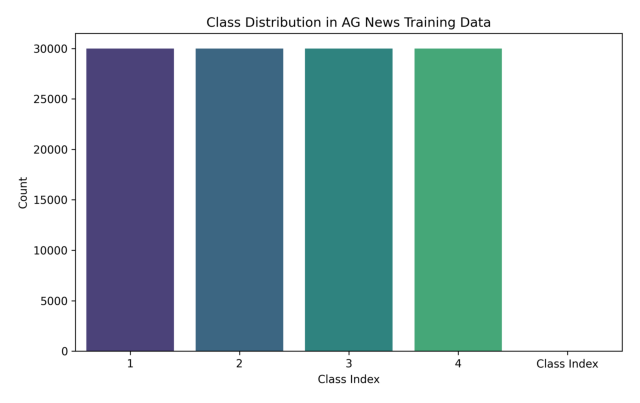

In [10]:
# Class distribution
class_counts = train_df["class_index"].value_counts().sort_index()
print(class_counts)

class_distribution_path = PLOTS_DIR / "class_distribution.png"

def plot_class_distribution(train_df, class_distribution_path="class_distribution.png"):
    class_counts = train_df["class_index"].value_counts().sort_index()
    print(class_counts)

    if os.path.exists(class_distribution_path):
        print(f"Plot already exists at {class_distribution_path}. Loading it...")
        img = mpimg.imread(class_distribution_path)
        plt.figure(figsize=(8, 5))
        plt.imshow(img)
        plt.axis("off")
        #plt.title("Class Distribution in AG News Training Data")
        plt.show()
    else:
        print(f"Plot not found. Creating and saving to {class_distribution_path}...")
        plt.figure(figsize=(8, 5))
        sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
        plt.title("Class Distribution in AG News Training Data")
        plt.xlabel("Class Index")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.savefig(class_distribution_path, dpi=300, bbox_inches="tight")
        plt.show()

plot_class_distribution(train_df, class_distribution_path)

The results indicate that the dataset is well balanced, with a similar number of samples in each of the categories: World, Sports, Business, and Science/Technology. Consequently, no additional techniques such as class weighting, oversampling, or undersampling were required during model training.

**Text Length Analysis.** The length of news articles was analysed to better understand the distribution of text samples within the dataset. Examining text length provides insights into the variability of document sizes and helps inform preprocessing decisions such as sequence truncation, padding, and maximum token length selection for model training.

In [11]:
# Text length analysis
train_df["title_length"] = train_df["title"].astype(str).apply(len)
train_df["description_length"] = train_df["description"].astype(str).apply(len)

print(train_df[["title_length", "description_length"]].describe())

        title_length  description_length
count  120000.000000       120000.000000
mean       42.071508          193.388517
std        13.569405           64.472066
min         6.000000            6.000000
25%        33.000000          155.000000
50%        41.000000          188.000000
75%        49.000000          219.000000
max       115.000000          985.000000


Plot already exists at /content/drive/MyDrive/tafe/src/news/plots/title_length_distribution.png. Loading it...


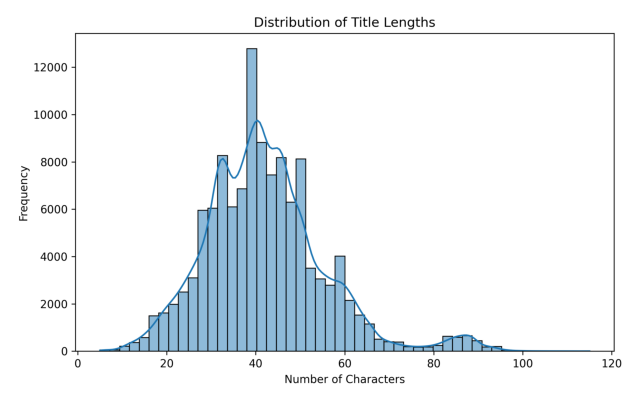

In [12]:
# Plot title length
title_length_distribution_path = PLOTS_DIR / "title_length_distribution.png"

def plot_title_length_distribution(train_df, title_length_distribution_path="title_length_distribution.png"):
    if os.path.exists(title_length_distribution_path):
        print(f"Plot already exists at {title_length_distribution_path}. Loading it...")
        img = mpimg.imread(title_length_distribution_path)
        plt.figure(figsize=(8, 5))
        plt.imshow(img)
        plt.axis("off")
        #plt.title("Title Length Distribution Plot")
        plt.show()
    else:
        plt.figure(figsize=(8, 5))
        sns.histplot(train_df["title_length"], bins=50, kde=True)
        plt.title("Title Length Distribution Plot")
        plt.xlabel("Number of Characters")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.savefig(title_length_distribution_path, dpi=300, bbox_inches="tight")
        plt.show()

plot_title_length_distribution(train_df, title_length_distribution_path)

The distribution of title lengths shows that most news titles are relatively short, with the highest concentration around 35 to 50 characters. This indicates that article titles in the AG News dataset are generally concise and follow a fairly consistent length. There are also fewer very short and very long titles, with a slight right skew showing that some titles extend beyond the average range

Plot already exists at /content/drive/MyDrive/tafe/src/news/plots/description_length_distribution.png. Loading it...


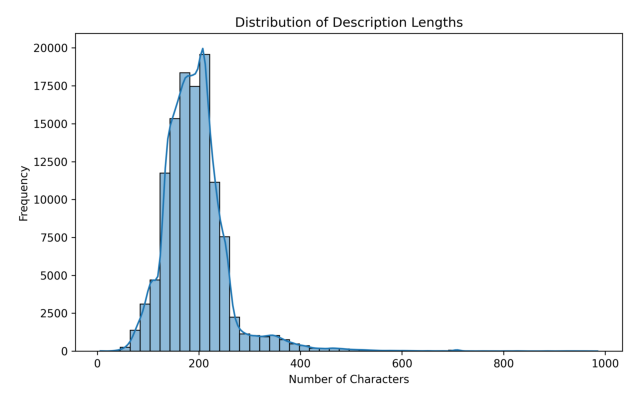

In [13]:
# Plot description length
description_length_distribution_path = PLOTS_DIR / "description_length_distribution.png"

def plot_description_length_distribution(train_df, description_length_distribution_path="description_length_distribution.png"):
    if os.path.exists(description_length_distribution_path):
        print(f"Plot already exists at {description_length_distribution_path}. Loading it...")
        img = mpimg.imread(description_length_distribution_path)
        plt.figure(figsize=(8, 5))
        plt.imshow(img)
        plt.axis("off")
        #plt.title("Description Length Distribution Plot")
        plt.show()
    else:
        plt.figure(figsize=(8, 5))
        sns.histplot(train_df["description_length"], bins=50, kde=True)
        plt.title("Description Length Distribution Plot")
        plt.xlabel("Number of Characters")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.savefig(description_length_distribution_path, dpi=300, bbox_inches="tight")
        plt.show()

plot_description_length_distribution(train_df, description_length_distribution_path)

Likewise, the distribution of description lengths shows that most news descriptions are much longer than titles, with the highest concentration around 150 to 250 characters. This suggests that the description field provides more detailed information about each article, which can be useful for classification. The graph is also right-skewed, meaning that while most descriptions fall within a moderate range, a smaller number are much longer.

**Word Count Analysis.** The distribution of word counts was visualized to examine the frequency of different article lengths and to identify potential outliers. Understanding the distribution of word counts assists in selecting appropriate sequence lengths and optimizing model input configurations.

In [14]:
# Word count analysis
train_df["title_word_count"] = train_df["title"].astype(str).apply(lambda x: len(x.split()))
train_df["description_word_count"] = train_df["description"].astype(str).apply(lambda x: len(x.split()))

print(train_df[["title_word_count", "description_word_count"]].describe())

       title_word_count  description_word_count
count     120000.000000           120000.000000
mean           6.784108               31.060508
std            2.088201                9.760460
min            1.000000                1.000000
25%            5.000000               25.000000
50%            7.000000               30.000000
75%            8.000000               36.000000
max           19.000000              173.000000


Plot already exists at /content/drive/MyDrive/tafe/src/news/plots/description_word_count_distribution.png. Loading it...


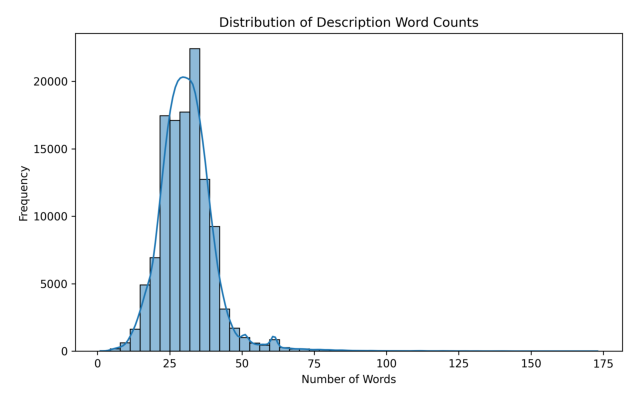

In [15]:
# Plot description word count
description_word_count_distribution_path = PLOTS_DIR / "description_word_count_distribution.png"

def plot_description_word_count_distribution(
    train_df,
    description_word_count_distribution_path="description_word_count_distribution.png"
):
    if os.path.exists(description_word_count_distribution_path):
        print(f"Plot already exists at {description_word_count_distribution_path}. Loading it...")
        img = mpimg.imread(description_word_count_distribution_path)
        plt.figure(figsize=(8, 5))
        plt.imshow(img)
        plt.axis("off")
        #plt.title("Word Count Distribution Plot")
        plt.show()
    else:
        print(f"Plot not found. Creating and saving to {description_word_count_distribution_path}...")
        plt.figure(figsize=(8, 5))
        sns.histplot(train_df["description_word_count"], bins=50, kde=True)
        plt.title("Word Count Distribution Plot")
        plt.xlabel("Number of Words")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.savefig(description_word_count_distribution_path, dpi=300, bbox_inches="tight")
        plt.show()

plot_description_word_count_distribution(train_df, description_word_count_distribution_path)

The distribution of description word counts shows that most news descriptions contain around 20 to 40 words, with the peak appearing near 30 words. This indicates that the descriptions are generally short but still contain enough information to provide context about the article. The distribution is slightly right-skewed, meaning that while most descriptions fall within a common range, some articles have much longer descriptions.

Since the AG News dataset contains text rather than numeric image data, standard PCA is not the most suitable dimensionality reduction method. After converting the text into TF-IDF vectors, TruncatedSVD is recommended instead of PCA because it works efficiently with sparse text representations. This allows the dataset to be reduced into fewer dimensions while preserving important information from the original text features.

In [16]:
# Combine title + description into one text column
train_df["text"] = train_df["title"].fillna("") + " " + train_df["description"].fillna("")
y_train = train_df["class_index"]

# Convert text to TF-IDF features
vectorizer = TfidfVectorizer(stop_words="english", max_features=20000)
X_tfidf = vectorizer.fit_transform(train_df["text"])

# TruncatedSVD
svd = TruncatedSVD(n_components=100, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

print("Original TF-IDF shape (training data):", X_tfidf.shape)
print("Reduced TF-IDF shape (training data):", X_svd.shape)
print("Total explained variance:", svd.explained_variance_ratio_.sum())

Original TF-IDF shape (training data): (120000, 20000)
Reduced TF-IDF shape (training data): (120000, 100)
Total explained variance: 0.1153196586966685


The original TF-IDF representation of the AG News training set had 120,000 documents and 20,000 features. After applying TruncatedSVD with 100 components, the dimensionality was reduced to 100 latent features per document. These 100 components explained approximately 11.54% of the total variance, which is reasonable for sparse high-dimensional text data where variance is typically distributed across many dimensions.

The cumulative explained variance curve below was examined to determine the minimum number of SVD components required to retain a substantial proportion of the original information. This analysis helped guide the selection of the optimal dimensionality for subsequent model training while minimizing computational complexity.

Plot already exists at /content/drive/MyDrive/tafe/src/news/plots/cumulative_explained_variance.png. Loading it...


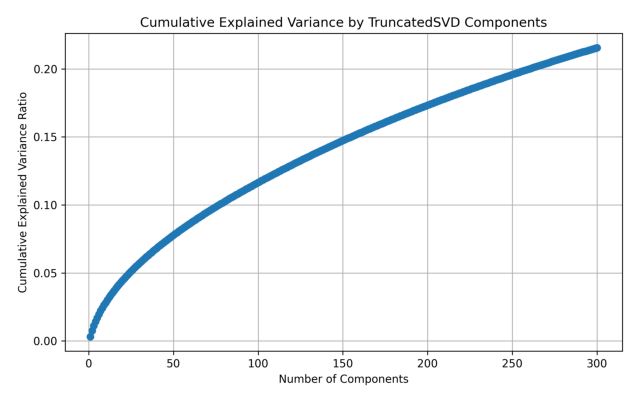

In [17]:
# Fit SVD with more components to inspect variance
cumulative_explained_variance_path = PLOTS_DIR / "cumulative_explained_variance.png"

def plot_cumulative_explained_variance(
    X_tfidf,
    cumulative_explained_variance_path="cumulative_explained_variance.png",
    n_components=300
):
    svd_variance = TruncatedSVD(n_components=n_components, random_state=42)
    svd_variance.fit(X_tfidf)

    cumulative_variance = np.cumsum(svd_variance.explained_variance_ratio_)

    if os.path.exists(cumulative_explained_variance_path):
        print(f"Plot already exists at {cumulative_explained_variance_path}. Loading it...")
        img = mpimg.imread(cumulative_explained_variance_path)
        plt.figure(figsize=(8, 5))
        plt.imshow(img)
        plt.axis("off")
        #plt.title("Cumulative Explained Variance by TruncatedSVD Components")
        plt.show()
    else:
        print(f"Plot not found. Creating and saving to {cumulative_explained_variance_path}...")

        plt.figure(figsize=(8, 5))
        plt.plot(
            range(1, len(cumulative_variance) + 1),
            cumulative_variance,
            marker="o"
        )
        plt.title("Cumulative Explained Variance by TruncatedSVD Components")
        plt.xlabel("Number of Components")
        plt.ylabel("Cumulative Explained Variance Ratio")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(cumulative_explained_variance_path, dpi=300, bbox_inches="tight")
        plt.show()

    return cumulative_variance

cumulative_variance = plot_cumulative_explained_variance(
    X_tfidf,
    cumulative_explained_variance_path,
    n_components=300
)

The graph shows that increasing the number of TruncatedSVD components keeps preserving more information, but the improvement becomes smaller over time. This means the first few components are the most useful, and later components add less and less new information.

We can choose the smallest number of components that reaches a target explained variance threshold then later refit it to find a good balance between keeping useful information and reducing the number of features

The original TF-IDF matrix has shape:
- 120,001 documents
- 20,000 features

That is very large. TruncatedSVD reduces those 20,000 features to something much smaller, like 50, 100, 200, 300 components, etc. But there is no automatic perfect choice so this can help us decide how many latent features to keep so that the data is compressed enough, but still retains useful information.

In [18]:
def choose_best_n_components(cumulative_variance, threshold=0.20):
    if threshold <= 0 or threshold > 1:
        raise ValueError("threshold must be between 0 and 1.")

    if cumulative_variance[-1] < threshold:
        print(f"Threshold of {threshold:.0%} is not reached.")
        print(f"Maximum cumulative explained variance available: {cumulative_variance[-1]:.4f}")
        return None

    best_n = np.argmax(cumulative_variance >= threshold) + 1

    print(f"Chosen number of components for {threshold:.0%} explained variance: {best_n}")
    print(f"Cumulative explained variance at {best_n} components: {cumulative_variance[best_n - 1]:.4f}")

    return best_n

best_n = choose_best_n_components(cumulative_variance, threshold=0.20)

Chosen number of components for 20% explained variance: 260
Cumulative explained variance at 260 components: 0.2001


The following 2D visualization with TruncatedSVD reduces X_tfidf to 2 components and creates a scatter plot colored by class.

Unique raw labels: ['1', '2', '3', '4']
Plot already exists at /content/drive/MyDrive/tafe/src/news/plots/truncated_svd_2d.png. Loading it...


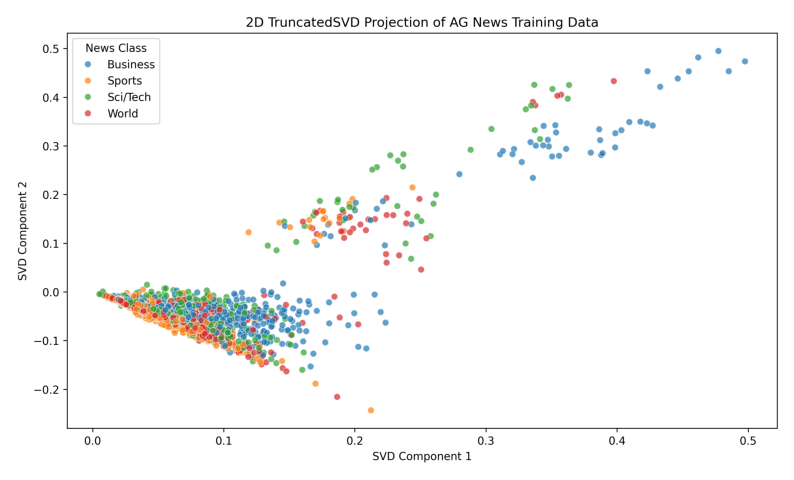

In [19]:
truncated_svd_2d_path = PLOTS_DIR / "truncated_svd_2d.png"

def plot_2d_truncated_svd(
        X_tfidf,
        y_train,
        truncated_svd_2d_path="truncated_svd_2d.png",
        sample_size=3000
    ):
        class_mapping = {
            1: "World",
            2: "Sports",
            3: "Business",
            4: "Sci/Tech"
        }

        # Debug: inspect labels
        y_series = pd.Series(y_train).reset_index(drop=True)
        print("Unique raw labels:", sorted(y_series.dropna().astype(str).unique().tolist())[:20])

        # Coerce to numeric for robust mapping
        y_num = pd.to_numeric(y_series, errors="coerce")
        y_mapped = y_num.map(class_mapping)

        # Fallback to original labels where mapping failed
        y_plot = y_mapped.fillna(y_series.astype(str))

        if os.path.exists(truncated_svd_2d_path):
            print(f"Plot already exists at {truncated_svd_2d_path}. Loading it...")
            img = mpimg.imread(truncated_svd_2d_path)
            plt.figure(figsize=(10, 6))
            plt.imshow(img)
            plt.axis("off")
            #plt.title("2D TruncatedSVD Projection of AG News Training Data")
            plt.show()
            return

        print(f"Plot not found. Creating and saving to {truncated_svd_2d_path}...")

        svd_2d = TruncatedSVD(n_components=2, random_state=42)
        X_2d = svd_2d.fit_transform(X_tfidf)

        plot_df = pd.DataFrame({
            "svd_1": X_2d[:, 0],
            "svd_2": X_2d[:, 1],
            "Class": y_plot
        })

        if sample_size is not None and len(plot_df) > sample_size:
            plot_df = plot_df.sample(sample_size, random_state=42)

        plt.figure(figsize=(10, 6))
        sns.scatterplot(
            data=plot_df,
            x="svd_1",
            y="svd_2",
            hue="Class",
            alpha=0.7
        )
        plt.title("2D TruncatedSVD Projection of AG News Training Data")
        plt.xlabel("SVD Component 1")
        plt.ylabel("SVD Component 2")
        plt.legend(title="News Class")
        plt.tight_layout()
        plt.savefig(truncated_svd_2d_path, dpi=300, bbox_inches="tight")
        plt.show()

plot_2d_truncated_svd(
    X_tfidf,
    y_train,
    truncated_svd_2d_path,
    sample_size=3000
)

The 2D TruncatedSVD projection shows that the AG News articles form visible structure in the reduced feature space, with some partial grouping by class. However, there is also substantial overlap among classes, indicating that two dimensions are insufficient to fully separate the categories. This is expected for high-dimensional sparse text data, where much of the discriminative information remains in higher dimensions.

The AG News dataset was preprocessed by combining the title and description fields into a single text feature and converting the class labels into zero-based numeric targets suitable for multi-class classification. For the RNN and BiLSTM-Attention models, the text was tokenized into integer sequences using a vocabulary constructed from the training data and padded to a fixed sequence length to ensure consistent input dimensions. For the transformer-based models, including RoBERTa, DeBERTa, and ELECTRA, the original text was tokenized using the respective pretrained tokenizers, with truncation and padding applied to produce fixed-length input representations compatible with each model architecture.

#### 4.2.1 Common Data Pre-Processing
- Combine title and description.
- Keep only needed columns.
- Make labels integers.
- Label preprocessing.
  AG News labels are usually:
  - 1 = World
  - 2 = Sports
  - 3 = Business
  - 4 = Sci/Tech  

  For deep learning, it is often easier to make them zero-based.

In [20]:
# Combine title and description
train_df["text"] = train_df["title"].fillna("") + " " + train_df["description"].fillna("")
test_df["text"] = test_df["title"].fillna("") + " " + test_df["description"].fillna("")

In [21]:
# Keep only needed columns
train_df = train_df[["class_index", "text"]].copy()
test_df = test_df[["class_index", "text"]].copy()

In [22]:
# Make labels integers
train_df["class_index"] = train_df["class_index"].astype(int)
test_df["class_index"] = test_df["class_index"].astype(int)

print(train_df.head())
print(train_df["class_index"].value_counts())

   class_index                                               text
0            3  Wall St. Bears Claw Back Into the Black (Reute...
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...
2            3  Oil and Economy Cloud Stocks' Outlook (Reuters...
3            3  Iraq Halts Oil Exports from Main Southern Pipe...
4            3  Oil prices soar to all-time record, posing new...
class_index
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64


In [23]:
# Label preprocessing
train_df["label"] = train_df["class_index"] - 1
test_df["label"] = test_df["class_index"] - 1

print(f"Label preprocessing: {train_df["label"].unique()}")  # should be [0,1,2,3]

Label preprocessing: [2 3 1 0]


#### 4.2.2 RNN Data Pre-Processing
The following preprocessing steps transformed the raw text data into a numerical format suitable for the RNN and BiLSTM-Attention architectures while preserving the sequential structure of the news articles:
- Text Consolidation
- Label Encoding
- Text Tokenization
- Sequence Conversion
- Sequence Padding and Truncation
- Dataset Preparation
  - Converted the processed sequences and labels into tensors and organized them into training, validation, and test datasets for model training and evaluation.


In [24]:
# -------------------------------------
# Preprocessing for RNN.
# -------------------------------------
# Parameters
max_vocab_size = 20000
rnn_max_sequence_length = 100

# Tokenizer
rnn_tokenizer = Tokenizer(num_words=max_vocab_size, oov_token="<OOV>")
rnn_tokenizer.fit_on_texts(train_df["text"])

# Convert text to sequences
X_train_seq = rnn_tokenizer.texts_to_sequences(train_df["text"])
X_test_seq = rnn_tokenizer.texts_to_sequences(test_df["text"])

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=rnn_max_sequence_length, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=rnn_max_sequence_length, padding="post", truncating="post")

# Labels
y_train = train_df["label"].values
y_test = test_df["label"].values

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train_pad shape: (120000, 100)
X_test_pad shape: (7600, 100)
y_train shape: (120000,)
y_test shape: (7600,)


In [25]:
# Example preprocessing output for RNN/LSTM
print(train_df["text"].iloc[0])
print(X_train_seq[0][:20])
print(X_train_pad[0][:20])

Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
[442, 444, 1682, 14527, 109, 65, 2, 851, 22, 22, 753, 8197, 442, 6641, 10232, 2928, 5, 5811, 1, 41]
[  442   444  1682 14527   109    65     2   851    22    22   753  8197
   442  6641 10232  2928     5  5811     1    41]


In [26]:
# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_pad, y_train, test_size=0.2, stratify=y_train, random_state=random_state
)

In [27]:
# ----------------------------
# Convert numpy arrays to PyTorch tensors
# ----------------------------
X_train_tensor = torch.tensor(X_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_pad, dtype=torch.long)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


In [28]:
# ----------------------------
# Create TensorDatasets
# ----------------------------
rnn_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
rnn_val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
rnn_test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

print("RNN train dataset size:", len(rnn_train_dataset))
print("RNN val dataset size:", len(rnn_val_dataset))
print("RNN test dataset size:", len(rnn_test_dataset))


RNN train dataset size: 96000
RNN val dataset size: 24000
RNN test dataset size: 7600


#### 4.2.3 Transformers Data Pre-Processing
The following preprocessing steps transformed the raw news articles into the structured input format required by transformer-based architectures while preserving contextual and semantic information within the text:
- Text Consolidation
- Label Encoding
- Transformer Tokenization
  - Tokenized the text using the corresponding pretrained tokenizer for each transformer model (RoBERTa, DeBERTa, and ELECTRA), converting text into subword token representations.
- Input Encoding
  - Generated model-specific input IDs and attention masks required by the transformer architectures.
- Sequence Padding and Truncation
- Dataset Preparation
  - Organized the encoded inputs, attention masks, and labels into training, validation, and test datasets for model training and evaluation.

In [29]:
# -------------------------------------
# Preprocessing for Transformers.
# -------------------------------------
# Load tokenizer for DeBERTa
deberta_tokenizer = AutoTokenizer.from_pretrained(deberta_save_path)

# Load tokenizer for RoBERTa
roberta_tokenizer = RobertaTokenizer.from_pretrained(roberta_save_path)

# Load tokenizer for Electra
electra_tokenizer = AutoTokenizer.from_pretrained(electra_save_path)

In [30]:
# Tokenise text for DeBERTa
deberta_max_sequence_length = 256  # standard for transformers

deberta_X_train_enc = deberta_tokenizer(
    train_df["text"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=deberta_max_sequence_length,
    return_tensors="pt"
)

deberta_X_test_enc = deberta_tokenizer(
    test_df["text"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=deberta_max_sequence_length,
    return_tensors="pt"
)

In [31]:
# Tokenise text for RoBERTa
roberta_max_sequence_length = 256  # standard for transformers

roberta_X_train_enc = roberta_tokenizer(
    train_df["text"].tolist(),
    padding=True,
    truncation=True,
    max_length=roberta_max_sequence_length,
    return_tensors="pt"
)

roberta_X_test_enc = roberta_tokenizer(
    test_df["text"].tolist(),
    padding=True,
    truncation=True,
    max_length=roberta_max_sequence_length,
    return_tensors="pt"
)

In [32]:
# Tokenise text for Electra
electra_max_sequence_length = 256  # standard for transformers

electra_X_train_enc = electra_tokenizer(
    train_df["text"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=electra_max_sequence_length,
    return_tensors="pt"
)

electra_X_test_enc = electra_tokenizer(
    test_df["text"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=electra_max_sequence_length,
    return_tensors="pt"
)

In [33]:
# Labeling
y_train = torch.tensor(train_df["label"].values, dtype=torch.long)
y_test = torch.tensor(test_df["label"].values, dtype=torch.long)

In [34]:
# Example output - we should get "subword tokens → IDs"
print(f"Example output for DeBERTa after it was tokenised:")
print(train_df["text"].iloc[0])
print(deberta_X_train_enc["input_ids"][0][:20])
print(deberta_X_train_enc["attention_mask"][0][:20])
print(deberta_tokenizer.convert_ids_to_tokens(deberta_X_train_enc["input_ids"][0][:20]))

print(f"\nExample output for RoBERTa after it was tokenised:")
print(train_df["text"].iloc[0])
print(roberta_X_train_enc["input_ids"][0][:20])
print(roberta_X_train_enc["attention_mask"][0][:20])
print(roberta_tokenizer.convert_ids_to_tokens(roberta_X_train_enc["input_ids"][0][:20]))

print(f"\nExample output for ELECTRA after it was tokenised:")
print(train_df["text"].iloc[0])
print(electra_X_train_enc["input_ids"][0][:20])
print(electra_X_train_enc["attention_mask"][0][:20])
print(electra_tokenizer.convert_ids_to_tokens(electra_X_train_enc["input_ids"][0][:20]))

Example output for DeBERTa after it was tokenised:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
tensor([ 3285,   987,   260, 11915, 41818,  3023, 13676,   262,  1552,   287,
        10870,   285,  8439,   341,  5993,   271, 55022,   261,  3285,  1556])
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
['▁Wall', '▁St', '.', '▁Bears', '▁Claw', '▁Back', '▁Into', '▁the', '▁Black', '▁(', 'Reuters', ')', '▁Reuters', '▁-', '▁Short', '-', 'sellers', ',', '▁Wall', '▁Street']

Example output for RoBERTa after it was tokenised:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
tensor([    0, 28216,   312,     4,  6033, 44121,  3727, 20693,     5,  1378,
           36,  1251,    43,  1201,   111,  7787,    12,  5727,   268,     6])
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [35]:
# Train-validation split
train_idx, val_idx = train_test_split(
    range(len(y_train)),
    test_size=0.2,
    stratify=y_train.numpy(), #since y_train is a tensor
    random_state=random_state
)

In [36]:
# Create datasets
class TransformerDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels, indices):
        self.encodings = encodings
        self.labels = labels
        self.indices = indices

    def __getitem__(self, idx):
        i = self.indices[idx]
        return {
            "input_ids": self.encodings["input_ids"][i],
            "attention_mask": self.encodings["attention_mask"][i],
            "labels": self.labels[i]
        }

    def __len__(self):
        return len(self.indices)

# For DeBERTa
deberta_train_dataset = TransformerDataset(deberta_X_train_enc, y_train, train_idx)
deberta_val_dataset = TransformerDataset(deberta_X_train_enc, y_train, val_idx)
deberta_test_dataset = TransformerDataset(deberta_X_test_enc, y_test, list(range(len(y_test))))

# For RoBERTa
roberta_train_dataset = TransformerDataset(roberta_X_train_enc, y_train, train_idx)
roberta_val_dataset = TransformerDataset(roberta_X_train_enc, y_train, val_idx)
roberta_test_dataset = TransformerDataset(roberta_X_test_enc, y_test, list(range(len(y_test))))

# For Electra
electra_train_dataset = TransformerDataset(electra_X_train_enc, y_train, train_idx)
electra_val_dataset = TransformerDataset(electra_X_train_enc, y_train, val_idx)
electra_test_dataset = TransformerDataset(electra_X_test_enc, y_test, list(range(len(y_test))))

#### 4.2.4 Device Setup
**Hardware Configuration.** Model training and evaluation were performed using PyTorch with automatic device selection. GPU acceleration was utilized when available to improve computational efficiency; otherwise, computations were executed on the CPU.

In [37]:
%%capture
# ------------------------------------------------------------
# DEVICE SELECTION
# ------------------------------------------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA:", device)
else:
    device = torch.device("cpu")
    print("Using CPU:", device)

# 5. Methodology Used for Training, Testing, and Evaluation
---
To evaluate the effectiveness of different deep learning approaches for AG News classification, two categories of models were investigated: a BiLSTM-Attention model representing recurrent neural network architectures, and transformer-based models including RoBERTa, DeBERTa, and ELECTRA. The BiLSTM-Attention model was selected for its ability to capture sequential contextual information, while the transformer models were chosen for their advanced self-attention mechanisms and strong performance in natural language processing tasks.  

To identify the most effective model configurations, a systematic hyperparameter search and training procedure was performed for each architecture. The process involved evaluating multiple hyperparameter combinations, monitoring validation performance, and selecting the best-performing model based on validation accuracy.

### 5.1 Model 1: RNN
**RNN** is a neural network architecture that processes sequential data by retaining information from previous inputs, allowing it to learn contextual relationships within text. It is commonly used for natural language processing and sequence modelling tasks.  

However, traditional RNNs often struggle with long-term dependencies, motivating the use of more advanced architectures such as BiLSTM with Attention.


#### 5.1.1 BiLSTM-Attention Architecture
**Bidirectional Long Short-Term Memory with Attention (BiLSTM-Attention)** network was used for the news classification task to better capture contextual information within textual data.  
Unlike standard RNN or unidirectional LSTM models, which process text in a single direction (from past to future), a BiLSTM processes the sequence in both forward and backward directions, allowing the model to learn relationships between words based on both preceding and succeeding context. The attention mechanism is then applied to identify and emphasize the most informative parts of the text. This enables the model to generate more meaningful text representations for classification tasks.


The GloVe.6B.300d embedding set, trained on a corpus of approximately 6 billion tokens, was selected to provide 300-dimensional semantic word representations for the RNN-based models. The higher-dimensional embeddings were chosen to capture richer linguistic information and contextual relationships between words compared to lower-dimensional alternatives.

In [38]:
# Load GloVe embeddings
def load_glove(file_path):
    embedding_index = {}

    with open(file_path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embedding_index[word] = vector

    print("Loaded GloVe words:", len(embedding_index))
    return embedding_index

In [39]:
# Define freeze_embeddings (used in BiLSTMClassifier)
freeze_embeddings = True # Set to True to keep embeddings static, False to fine-tune

# Load GloVe embeddings (replicated logic from load_glove function due to cell execution constraints)
glove_file_path = DATA_DIR / "glove.6B.300d.txt"
embedding_index = {}
try:
    with open(glove_file_path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embedding_index[word] = vector
    print("Loaded GloVe words:", len(embedding_index))
except FileNotFoundError:
    print(f"Error: GloVe file not found at {glove_file_path}. Please download it and place it in the {DATA_DIR} directory.")
    # Initialize embedding_index to an empty dict to prevent further errors if file is missing
    embedding_index = {}


# Build embedding matrix - This creates: (vocab_size, embedding_dim)
embedding_dim = 300   # or 100 if using 100d file
embedding_matrix = np.zeros((max_vocab_size, embedding_dim))

word_index = rnn_tokenizer.word_index

for word, i in word_index.items():
    if i >= max_vocab_size:
        continue

    vector = embedding_index.get(word)
    if vector is not None:
        embedding_matrix[i] = vector

Loaded GloVe words: 400000


In [40]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_output, mask=None):
        """
        lstm_output: (B, seq_len, hidden_dim * 2)
        mask: (B, seq_len) with 1 for valid tokens and 0 for padding
        """
        scores = self.attn(lstm_output).squeeze(-1)  # (B, seq_len)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        weights = F.softmax(scores, dim=1)  # (B, seq_len)
        context = torch.bmm(weights.unsqueeze(1), lstm_output).squeeze(1)  # (B, hidden_dim * 2)

        return context, weights


class BiLSTMClassifier_Attention_GELU(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        num_classes,
        hidden_dim=128,
        num_layers=2,
        dropout_rate=0.3,
        freeze_embeddings=True
    ):
        super().__init__()

        embed_dim = embedding_matrix.shape[1]

        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=freeze_embeddings
        )

        self.bilstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout_rate if num_layers > 1 else 0.0
        )

        self.attention = Attention(hidden_dim)
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout_rate)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, attention_mask=None):
        """
        x: (B, seq_len)
        attention_mask: (B, seq_len), optional
        """
        x = self.embedding(x)  # (B, seq_len, embed_dim)

        lstm_output, (hidden, cell) = self.bilstm(x)  # (B, seq_len, hidden_dim * 2)

        context, attn_weights = self.attention(lstm_output, attention_mask)

        x = self.layer_norm(context)
        x = self.dropout(x)

        logits = self.classifier(x)
        return logits

#### 5.1.2 BiLSTM-Attention Hyperparameters Tuning
Hyperparameter tuning was performed by testing several combinations of learning rate, batch size, dropout rate, number of epochs and hidden units. For each configuration, the model was trained and the best checkpoint based on validation accuracy was saved. The saved models were then compared, and the one with the highest validation accuracy was selected for final testing. **For full details on the hyperparameter search and model training, refer to Appendix A.**

In [41]:
rnn_param_grid = [
    {"learning_rate": 0.00005, "batch_size": 64,  "dropout_rate": 0.6, "num_epochs": 15, "hidden_units": 256},
    {"learning_rate": 0.0001,  "batch_size": 64,  "dropout_rate": 0.5, "num_epochs": 15, "hidden_units": 256},
    {"learning_rate": 0.0005,  "batch_size": 64,  "dropout_rate": 0.5, "num_epochs": 12, "hidden_units": 128},
    {"learning_rate": 0.00005, "batch_size": 128, "dropout_rate": 0.6, "num_epochs": 12, "hidden_units": 128},
]

rnn_experiment_results = []
rnn_all_histories = {}

#### 5.1.3 BiLSTM-Attention Training


In [42]:
# ----------------------------
# Global resume tracking for RNN
# ----------------------------
rnn_total_experiments = len(rnn_param_grid)
rnn_resume_experiment = 1
rnn_global_checkpoint = SAVED_MODELS_DIR / "rnn_hparam_search_state.pth"

rnn_all_done = False

if rnn_global_checkpoint.exists():
    print("Global RNN experiment checkpoint found...")
    rnn_global_state = torch.load(rnn_global_checkpoint, map_location=device)

    saved_idx = rnn_global_state.get("experiment_idx", 1)
    rnn_experiment_results = rnn_global_state.get("experiment_results", [])
    rnn_all_histories = rnn_global_state.get("all_histories", {})

    if saved_idx > rnn_total_experiments:
        rnn_all_done = True
        rnn_resume_experiment = rnn_total_experiments + 1
        print(f"All {rnn_total_experiments} RNN experiments are already completed.")
    else:
        rnn_resume_experiment = max(1, saved_idx)
        print(f"Resuming from RNN experiment {rnn_resume_experiment} of {rnn_total_experiments}")
else:
    print("No global RNN experiment checkpoint found.")

Global RNN experiment checkpoint found...
All 4 RNN experiments are already completed.


In [43]:
# =====================================================================================
# RNN HYPERPARAMETER SEARCH
# =====================================================================================
if rnn_all_done:
    print("All experiments were previously completed. Skipping RNN hyperparameter search and loading saved *.pth files...")
else:
    for exp_idx, params in enumerate(rnn_param_grid, start=1):

        # ----------------------------
        # Skip already-finished experiments
        # ----------------------------
        if exp_idx < rnn_resume_experiment:
            print(f"Skipping completed RNN experiment {exp_idx}")
            continue

        print("=" * 100)
        print(f"RNN Experiment {exp_idx}/{len(rnn_param_grid)}")
        print("Parameters:", params)
        print("=" * 100)

        # ----------------------------
        # DataLoaders
        # ----------------------------
        rnn_train_loader = DataLoader(
            rnn_train_dataset,
            batch_size=params["batch_size"],
            shuffle=True,
            num_workers=0,
            drop_last=False
        )

        rnn_val_loader = DataLoader(
            rnn_val_dataset,
            batch_size=params["batch_size"],
            shuffle=False,
            num_workers=0,
            drop_last=False
        )

        # ----------------------------
        # Model / Optimizer / Loss / Scheduler
        # ----------------------------
        rnn_model = BiLSTMClassifier_Attention_GELU(
            embedding_matrix=embedding_matrix,
            num_classes=4,
            hidden_dim=params["hidden_units"],
            num_layers=2,
            dropout_rate=params["dropout_rate"],
            freeze_embeddings=freeze_embeddings
        ).to(device)

        rnn_criterion = nn.CrossEntropyLoss()
        rnn_optimizer = torch.optim.AdamW(
            rnn_model.parameters(),
            lr=params["learning_rate"],
            weight_decay=1e-4
        )

        rnn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            rnn_optimizer,
            mode="max",
            factor=0.5,
            patience=2
        )

        # ----------------------------
        # Experiment tracking
        # ----------------------------
        best_val_acc = 0.0
        best_val_loss = float("inf")
        best_epoch = 0
        best_model_state_dict = None

        patience = 7
        epochs_without_improvement = 0

        train_losses, val_losses = [], []
        train_accuracies, val_accuracies = [], []

        # ----------------------------
        # Checkpoint name
        # ----------------------------
        lr_str = f"{params['learning_rate']:.5f}".replace(".", "_")
        drop_str = str(params["dropout_rate"]).replace(".", "_")

        checkpoint_name = (
            SAVED_MODELS_DIR / f"rnn_exp{exp_idx}_"
            f"lr{lr_str}_bs{params['batch_size']}_drop{drop_str}_"
            f"hd{params['hidden_units']}.pth"
        )

        start_epoch = 0

        if os.path.exists(checkpoint_name):
            print("RNN checkpoint found. Resuming training...")
            checkpoint = torch.load(checkpoint_name, map_location=device)

            rnn_model.load_state_dict(checkpoint["latest_model_state_dict"])
            rnn_optimizer.load_state_dict(checkpoint["latest_optimizer_state_dict"])

            start_epoch = checkpoint.get("epoch", 0)
            best_val_acc = checkpoint.get("best_val_acc", 0.0)
            best_val_loss = checkpoint.get("best_val_loss", float("inf"))
            best_epoch = checkpoint.get("best_epoch", 0)
            best_model_state_dict = checkpoint.get("best_model_state_dict", None)
            epochs_without_improvement = checkpoint.get("epochs_without_improvement", 0)

            train_losses = checkpoint.get("train_losses", [])
            val_losses = checkpoint.get("val_losses", [])
            train_accuracies = checkpoint.get("train_accuracies", [])
            val_accuracies = checkpoint.get("val_accuracies", [])

            print(f"Resuming RNN from epoch {start_epoch}")
        else:
            print("No RNN experiment checkpoint found. Starting fresh.")

        start_time = time.time()

        for epoch in range(start_epoch, params["num_epochs"]):
            rnn_model.train()
            running_loss, correct, total = 0.0, 0, 0
            epoch_start = time.time()

            for inputs, labels in rnn_train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                rnn_optimizer.zero_grad()
                outputs = rnn_model(inputs)
                loss = rnn_criterion(outputs, labels)
                loss.backward()
                rnn_optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            epoch_train_loss = running_loss / total
            epoch_train_acc = correct / total
            train_losses.append(epoch_train_loss)
            train_accuracies.append(epoch_train_acc)

            # Validation
            rnn_model.eval()
            val_running_loss, val_correct, val_total = 0.0, 0, 0
            with torch.no_grad():
                for inputs, labels in rnn_val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = rnn_model(inputs)
                    loss = rnn_criterion(outputs, labels)
                    val_running_loss += loss.item() * inputs.size(0)
                    _, predicted = torch.max(outputs, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()

            epoch_val_loss = val_running_loss / val_total
            epoch_val_acc = val_correct / val_total
            val_losses.append(epoch_val_loss)
            val_accuracies.append(epoch_val_acc)

            rnn_scheduler.step(epoch_val_acc)
            epoch_duration = time.time() - epoch_start

            print(
                f"Epoch [{epoch+1}/{params['num_epochs']}] "
                f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, "
                f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}, "
                f"LR: {rnn_optimizer.param_groups[0]['lr']:.6f}, Time: {epoch_duration:.2f}s"
            )

            if epoch_val_acc > best_val_acc:
                best_val_acc, best_val_loss, best_epoch = epoch_val_acc, epoch_val_loss, epoch + 1
                epochs_without_improvement = 0
                best_model_state_dict = {k: v.detach().cpu().clone() for k, v in rnn_model.state_dict().items()}
                print("Best RNN model improved.")
            else:
                epochs_without_improvement += 1

            total_elapsed = time.time() - start_time

            safe_torch_save({
                "epoch": epoch + 1,
                "experiment_idx": exp_idx,
                "latest_model_state_dict": rnn_model.state_dict(),
                "latest_optimizer_state_dict": rnn_optimizer.state_dict(),
                "best_model_state_dict": best_model_state_dict,
                "best_val_acc": best_val_acc, "best_val_loss": best_val_loss, "best_epoch": best_epoch,
                "val_acc": epoch_val_acc, "val_loss": epoch_val_loss, "epochs_without_improvement": epochs_without_improvement,
                "params": params, "total_training_time_sec": total_elapsed,
                "train_losses": train_losses, "val_losses": val_losses,
                "train_accuracies": train_accuracies, "val_accuracies": val_accuracies
            }, str(checkpoint_name))

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        rnn_experiment_results = [r for r in rnn_experiment_results if r.get("experiment") != exp_idx]
        rnn_experiment_results.append({
            "experiment": exp_idx,
            "learning_rate": params["learning_rate"], "batch_size": params["batch_size"],
            "dropout_rate": params["dropout_rate"], "num_epochs": params["num_epochs"],
            "hidden_units": params["hidden_units"], "best_val_acc": best_val_acc,
            "best_val_loss": best_val_loss, "best_epoch": best_epoch, "checkpoint": checkpoint_name.name
        })

        rnn_all_histories[str(checkpoint_name)] = {
            "train_losses": train_losses, "val_losses": val_losses,
            "train_accuracies": train_accuracies, "val_accuracies": val_accuracies
        }

        safe_torch_save({
            "experiment_idx": exp_idx + 1,
            "experiment_results": rnn_experiment_results,
            "all_histories": rnn_all_histories
        }, str(rnn_global_checkpoint))

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

All experiments were previously completed. Skipping RNN hyperparameter search and loading saved *.pth files...


#### 5.1.4 BiLSTM-Attention Evaluation

In [44]:
rnn_results_csv_path = (SAVED_MODELS_DIR / "rnn_hyperparameter_results.csv")

if rnn_results_csv_path.exists():
    print("Loading existing hyperparameter results...")
    rnn_results_df = pd.read_csv(rnn_results_csv_path)
else:
    print("Creating hyperparameter results...")
    rnn_results_df = pd.DataFrame(rnn_experiment_results)

    if not rnn_results_df.empty:
        rnn_results_df = rnn_results_df.sort_values(by="best_val_acc", ascending=False).reset_index(drop=True)
        rnn_results_df.to_csv(rnn_results_csv_path, index=False)
        print(f"Saved tuning results to {rnn_results_csv_path}")
    else:
        print("No RNN experiment results found. Please ensure the hyperparameter search completed successfully.")

    rnn_results_df = rnn_results_df.sort_values(by="best_val_acc", ascending=False).reset_index(drop=True)
    rnn_results_df.to_csv(rnn_results_csv_path, index=False)
    print(f"Saved tuning results to {rnn_results_csv_path}")

print("\nRNN Tuning Results:")
print(rnn_results_df)

Loading existing hyperparameter results...

RNN Tuning Results:
   experiment  learning_rate  batch_size  dropout_rate  num_epochs  \
0           3        0.00050          64           0.5          12   
1           2        0.00010          64           0.5          15   
2           1        0.00005          64           0.6          15   
3           4        0.00005         128           0.6          12   

   hidden_units  best_val_acc  best_val_loss  best_epoch  \
0           128      0.930417       0.270980          11   
1           256      0.929500       0.214288          12   
2           256      0.926667       0.221011          15   
3           128      0.917042       0.246689          12   

                                   checkpoint  
0   rnn_exp3_lr0_00050_bs64_drop0_5_hd128.pth  
1   rnn_exp2_lr0_00010_bs64_drop0_5_hd256.pth  
2   rnn_exp1_lr0_00005_bs64_drop0_6_hd256.pth  
3  rnn_exp4_lr0_00005_bs128_drop0_6_hd128.pth  


In [45]:
# =====================================
# CREATE STANDALONE BEST RNN MODEL
# =====================================
if not rnn_results_df.empty:
    rnn_best_checkpoint_path = (SAVED_MODELS_DIR / rnn_results_df.iloc[0]["checkpoint"])

    print("\nBest RNN checkpoint found:")
    print(rnn_best_checkpoint_path)

    rnn_best_checkpoint = torch.load(rnn_best_checkpoint_path, map_location=device)
    rnn_best_model_path = (SAVED_MODELS_DIR / "rnn_best_model.pth")
    safe_torch_save(rnn_best_checkpoint, str(rnn_best_model_path))
    print(f"\nSaved standalone best model:\n" f"{rnn_best_model_path}")

else:
    print("Cannot create standalone best model because rnn_results_df is empty.")


Best RNN checkpoint found:
/content/drive/MyDrive/tafe/src/news/saved_models/rnn_exp3_lr0_00050_bs64_drop0_5_hd128.pth

Saved standalone best model:
/content/drive/MyDrive/tafe/src/news/saved_models/rnn_best_model.pth


##### 5.1.4.1 Load Best BiLSTM-Attention Model for Evaluation
Load the saved .pth checkpoint and set model to evaluation mode.

In [46]:
# ==================================================
# OPTION 1: Load standalone best model
# ==================================================
rnn_checkpoint = torch.load(
    SAVED_MODELS_DIR / "rnn_best_model.pth",
    map_location=device
)

print("Loaded standalone best model:", SAVED_MODELS_DIR / "rnn_best_model.pth")

# ==================================================
# OPTION 2: Load from hyperparameter search
# Requires all experiment checkpoints
# ==================================================
# best_rnn_checkpoint_path = (SAVED_MODELS_DIR / rnn_results_df.iloc[0]["checkpoint"])
# print("Best RNN checkpoint selected:", best_rnn_checkpoint_path)

# rnn_checkpoint = torch.load(
#     best_rnn_checkpoint_path,
#     map_location=device
# )

best_rnn_params = rnn_checkpoint["params"]

# Rebuild RNN (BiLSTM) model with best params
# Note: embedding_dim is 300 to match the GloVe vectors used during training
best_model_rnn = BiLSTMClassifier_Attention_GELU(
    embedding_matrix=embedding_matrix,
    num_classes=4,
    hidden_dim=best_rnn_params["hidden_units"],
    num_layers=2,
    dropout_rate=best_rnn_params["dropout_rate"],
    freeze_embeddings=freeze_embeddings
).to(device)

# Safety check
if rnn_checkpoint.get("best_model_state_dict") is None:
    raise ValueError("Best RNN model state dict is None. Training may not have completed properly.")

# Load best weights
best_model_rnn.load_state_dict(rnn_checkpoint["best_model_state_dict"])
best_model_rnn.eval()

Loaded standalone best model: /content/drive/MyDrive/tafe/src/news/saved_models/rnn_best_model.pth


BiLSTMClassifier_Attention_GELU(
  (embedding): Embedding(20000, 300)
  (bilstm): LSTM(300, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): Attention(
    (attn): Linear(in_features=256, out_features=1, bias=True)
  )
  (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)

##### 5.1.4.2 Training History Analysis of Best BiLSTM-Attention Model
These plots show the best model’s training/validation loss accuracy curves.

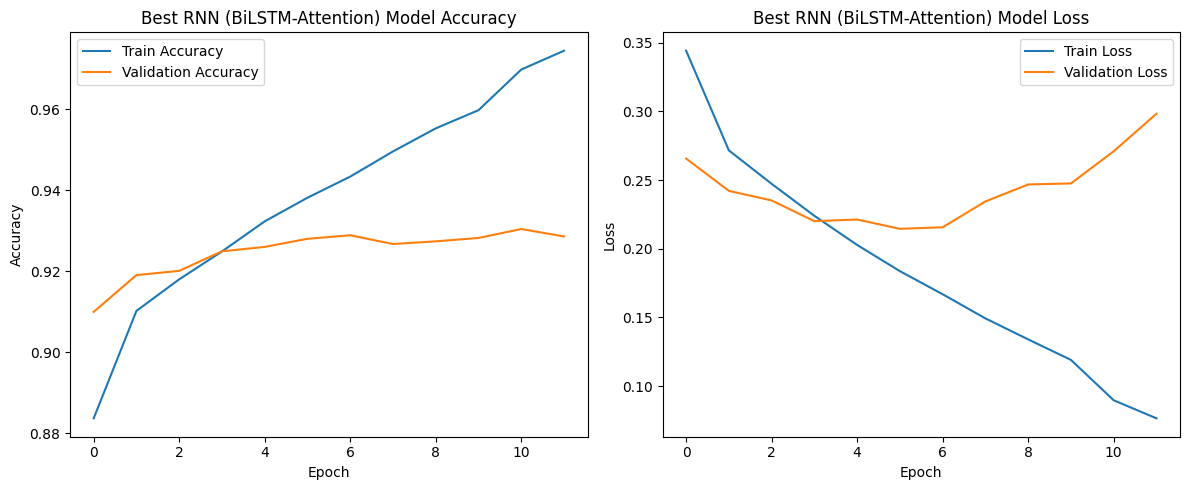

In [47]:
best_rnn_history = rnn_all_histories[str(SAVED_MODELS_DIR / rnn_results_df.iloc[0]["checkpoint"])]

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(best_rnn_history["train_accuracies"], label="Train Accuracy")
plt.plot(best_rnn_history["val_accuracies"], label="Validation Accuracy")
plt.title("Best RNN (BiLSTM-Attention) Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(best_rnn_history["train_losses"], label="Train Loss")
plt.plot(best_rnn_history["val_losses"], label="Validation Loss")
plt.title("Best RNN (BiLSTM-Attention) Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

The figure above illustrates the training and validation accuracy and loss curves of the best-performing BiLSTM-Attention model across training epochs. The training accuracy steadily increased from approximately 88.4% to 97.4%, indicating that the model continued to learn patterns from the training data throughout the training process. Validation accuracy improved rapidly during the initial epochs before stabilizing at approximately 92.5-93.0%, suggesting that the model achieved strong generalization performance on unseen data.

The loss curves further support this observation. Training loss consistently decreased from approximately 0.34 to 0.08, demonstrating successful optimization of the model parameters. In contrast, validation loss decreased during the early epochs before gradually increasing after approximately the fifth epoch. This divergence between training and validation loss, combined with the widening gap between training and validation accuracy, indicates the onset of overfitting. While the model continued to improve on the training data, these improvements did not translate to corresponding gains on the validation set.

##### 5.1.4.3 BiLSTM-Attention Model Evaluation on Validation Dataset

In [48]:
best_batch_size_rnn = best_rnn_params["batch_size"]

rnn_val_loader = DataLoader(
    rnn_val_dataset,
    batch_size=best_batch_size_rnn,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_preds_rnn = []
val_labels_rnn = []

with torch.no_grad():
    for inputs, labels in rnn_val_loader:
        inputs = inputs.to(device)   # changed from images
        labels = labels.to(device)

        outputs = best_model_rnn(inputs)
        _, predicted = torch.max(outputs, 1)

        val_preds_rnn.extend(predicted.cpu().numpy())
        val_labels_rnn.extend(labels.cpu().numpy())

val_preds_rnn = np.array(val_preds_rnn)
val_labels_rnn = np.array(val_labels_rnn)

val_accuracy_rnn = (val_preds_rnn == val_labels_rnn).mean()
print(f"RNN (BiLSTM-Attention) Validation Accuracy: {val_accuracy_rnn:.4f}")

RNN (BiLSTM-Attention) Validation Accuracy: 0.9304


In [49]:
# ----------------------------
# Classification Report
# ----------------------------
class_names = ["World", "Sports", "Business", "Sci/Tech"]

print("\nRNN (BiLSTM-Attention) Classification Report on Validation Set:")
print(classification_report(val_labels_rnn, val_preds_rnn, target_names=class_names))



RNN (BiLSTM-Attention) Classification Report on Validation Set:
              precision    recall  f1-score   support

       World       0.93      0.93      0.93      6000
      Sports       0.98      0.98      0.98      6000
    Business       0.91      0.89      0.90      6000
    Sci/Tech       0.90      0.92      0.91      6000

    accuracy                           0.93     24000
   macro avg       0.93      0.93      0.93     24000
weighted avg       0.93      0.93      0.93     24000



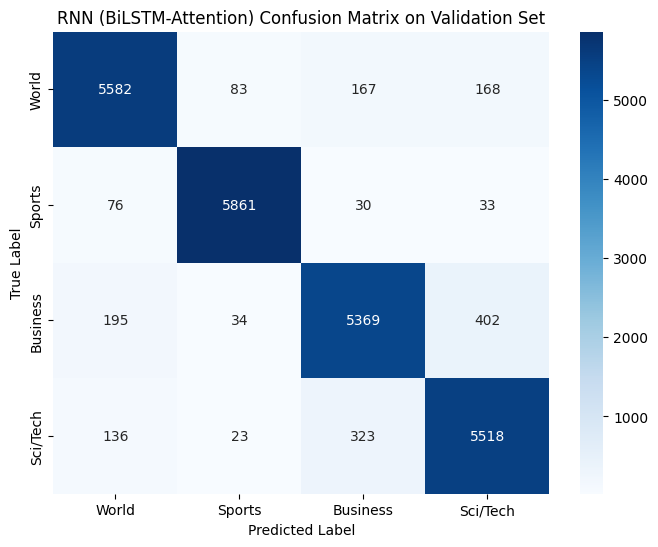

In [50]:
# ----------------------------
# Confusion Matrix
# ----------------------------
cm_rnn_val = confusion_matrix(val_labels_rnn, val_preds_rnn)

class_names = ["World", "Sports", "Business", "Sci/Tech"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_rnn_val,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("RNN (BiLSTM-Attention) Confusion Matrix on Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [51]:
# ----------------------------
# Per-Class Accuracy
# ----------------------------
class_names = ["World", "Sports", "Business", "Sci/Tech"]

print("Each Class Accuracy of RNN (BiLSTM-Attention) Model on Validation Set:")
print("-" * 50)

for i, class_name in enumerate(class_names):
    correct = cm_rnn_val[i, i]
    total = cm_rnn_val[i].sum()
    accuracy = (correct / total) * 100
    print(
        f"{class_name}: Accuracy = "
        f"{accuracy:.2f}% "
        f"({correct}/{total})"
    )

Each Class Accuracy of RNN (BiLSTM-Attention) Model on Validation Set:
--------------------------------------------------
World: Accuracy = 93.03% (5582/6000)
Sports: Accuracy = 97.68% (5861/6000)
Business: Accuracy = 89.48% (5369/6000)
Sci/Tech: Accuracy = 91.97% (5518/6000)


##### 5.1.4.4 BiLSTM-Attention Model Evaluation on Test Dataset
After selecting the best-performing model based on validation performance, inference was performed on the unseen test dataset to assess the model's generalization capability. Final classification metrics, including accuracy, precision, recall, and F1-score, were computed to provide a comprehensive assessment of the model's effectiveness on previously unseen news articles.

In [52]:
rnn_test_loader = DataLoader(
    rnn_test_dataset,
    batch_size=best_batch_size_rnn,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

best_model_rnn.eval()

test_preds_rnn = []
test_labels_rnn = []

with torch.no_grad():
    for images, labels in rnn_test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model_rnn(images)
        _, predicted = torch.max(outputs, 1)

        test_preds_rnn.extend(predicted.cpu().numpy())
        test_labels_rnn.extend(labels.cpu().numpy())

test_preds_rnn = np.array(test_preds_rnn)
test_labels_rnn = np.array(test_labels_rnn)

test_accuracy_rnn = (test_preds_rnn == test_labels_rnn).mean()
print(f"RNN (BiLSTM-Attention) Test Accuracy: {test_accuracy_rnn:.4f}")

RNN (BiLSTM-Attention) Test Accuracy: 0.9307


In [53]:
# ----------------------------
# Classification Report
# ----------------------------
print("\nRNN (BiLSTM-Attention) Classification Report on Test Set:")
print(classification_report(test_labels_rnn, test_preds_rnn, target_names=class_names))


RNN (BiLSTM-Attention) Classification Report on Test Set:
              precision    recall  f1-score   support

       World       0.94      0.93      0.94      1900
      Sports       0.98      0.98      0.98      1900
    Business       0.90      0.90      0.90      1900
    Sci/Tech       0.90      0.91      0.91      1900

    accuracy                           0.93      7600
   macro avg       0.93      0.93      0.93      7600
weighted avg       0.93      0.93      0.93      7600



The model achieved an overall accuracy of 93.07%, indicating strong generalization performance on unseen news articles. Among the four categories, Sports achieved the highest performance, with precision, recall, and F1-score of approximately 98%, demonstrating the model's ability to distinguish sports-related content with high reliability.  

The World category also achieved strong results, with an F1-score of 94%. In comparison, the Business and Sci/Tech categories obtained slightly lower F1-scores of 90% and 91%, respectively. This aligns with the confusion matrix analysis, which showed that these two categories were the most frequently confused due to similarities in subject matter and vocabulary.  

The macro-average and weighted-average scores were both 93%, indicating balanced performance across all classes. Since each category contains an equal number of samples (1,900 articles), the similarity between the macro and weighted averages suggests that the model performs consistently across the dataset without significant bias toward any particular class.  

Overall, the results demonstrate that the BiLSTM-Attention model is highly effective for AG News classification, achieving strong precision, recall, and F1-scores across all categories while maintaining balanced performance on the test set.  



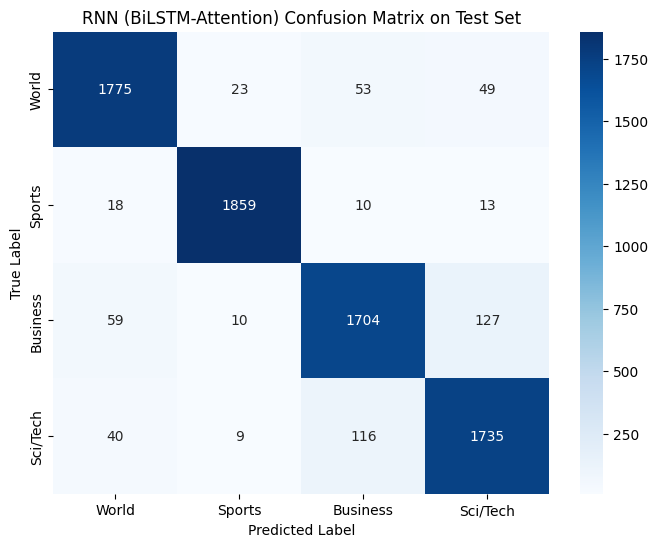

In [54]:
# ----------------------------
# Confusion Matrix
# ----------------------------
cm_rnn_test = confusion_matrix(test_labels_rnn, test_preds_rnn)

class_names = ["World", "Sports", "Business", "Sci/Tech"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_rnn_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("RNN (BiLSTM-Attention) Confusion Matrix on Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The figure above presents the confusion matrix for the BiLSTM-Attention model on the test dataset. The strong concentration of values along the diagonal indicates that the model correctly classified the majority of news articles across all four categories. The Sports class achieved the highest classification performance, with 1859 out of 1900 samples correctly identified and very few misclassifications. Similarly, the World category demonstrated strong performance, with 1775 correctly classified samples.

The largest sources of confusion occurred between the Business and Sci/Tech categories. Specifically, 127 Business articles were misclassified as Sci/Tech, while 116 Sci/Tech articles were misclassified as Business. This suggests that these two categories share overlapping terminology and contextual themes, making them more challenging to distinguish. Smaller levels of confusion were also observed between the World and Business/Sci-Tech categories.



**Each class accuracy on test dataset are also outlined below:**

In [55]:
# ----------------------------
# Per-Class Accuracy
# ----------------------------
class_names = ["World", "Sports", "Business", "Sci/Tech"]

print("Each Class Accuracy of RNN (BiLSTM-Attention) Model on Test Set:")
print("-" * 50)

for i, class_name in enumerate(class_names):
    correct = cm_rnn_test[i, i]
    total = cm_rnn_test[i].sum()
    accuracy = (correct / total) * 100
    print(
        f"{class_name}: Accuracy = "
        f"{accuracy:.2f}% "
        f"({correct}/{total})"
    )

Each Class Accuracy of RNN (BiLSTM-Attention) Model on Test Set:
--------------------------------------------------
World: Accuracy = 93.42% (1775/1900)
Sports: Accuracy = 97.84% (1859/1900)
Business: Accuracy = 89.68% (1704/1900)
Sci/Tech: Accuracy = 91.32% (1735/1900)


## 5.2 Model 2: Transformers
Transformers are neural network architectures that use self-attention mechanisms to learn contextual relationships between words in a text sequence. Compared to traditional recurrent neural networks, transformers are more effective at capturing long-range dependencies and can be trained more efficiently through parallel processing. This study utilizes RoBERTa, DeBERTa, and ELECTRA to perform multi-class news article classification on the AG News dataset.

#### 5.2.1 DeBERTa-v3
DeBERTa-v3 is an advanced transformer-based language model that extends the BERT architecture through disentangled attention and improved positional encoding mechanisms. These enhancements enable the model to learn richer contextual representations and capture relationships between words more effectively. Due to its strong performance in natural language processing tasks, DeBERTa-v3 was selected as one of the transformer models evaluated for AG News classification.


##### 5.2.1.1 DeBERTa-v3 Architecture
Pretrained DeBERTa encoder extracts contextual `CLS` token embedding, which is passed through dropout and a feed-forward classifier to predict class labels.


In [56]:
class DebertaV3Classifier(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.1, model_path=deberta_save_path):
        super().__init__()

        self.deberta = AutoModel.from_pretrained(model_path)
        hidden_size = self.deberta.config.hidden_size

        self.dropout = nn.Dropout(dropout_rate)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.LayerNorm(256),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.deberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        x = outputs.last_hidden_state[:, 0, :]
        x = self.dropout(x)

        return self.classifier(x)

##### 5.2.1.2 DeBERTa-v3 Hyperparameters Tuning
Hyperparameter tuning was performed by testing several combinations of learning rate, batch size, dropout rate, and number of epochs. For each configuration, the model was trained and the best checkpoint based on validation accuracy was saved. The saved models were then compared, and the one with the highest validation accuracy was selected for final testing. **For full details on the
hyperparameter search and model training, refer to Appendix A.**

In [57]:
deberta_param_grid = [
    {"learning_rate": 2e-5, "batch_size": 16, "dropout_rate": 0.1,  "num_epochs": 5},
    {"learning_rate": 3e-5, "batch_size": 16, "dropout_rate": 0.1,  "num_epochs": 5},
    {"learning_rate": 3e-5, "batch_size": 32, "dropout_rate": 0.1,  "num_epochs": 4},
    {"learning_rate": 2e-5, "batch_size": 32, "dropout_rate": 0.15, "num_epochs": 5},
]

deberta_experiment_results = []
deberta_all_histories = {}

##### 5.2.1.3 DeBERTa-v3 Training

In [58]:
# ----------------------------
# Global resume tracking for BERT
# ----------------------------
deberta_total_experiments = len(deberta_param_grid)
deberta_resume_experiment = 1
deberta_global_checkpoint = SAVED_MODELS_DIR / "deberta_hparam_search_state.pth"

deberta_all_done = False

if deberta_global_checkpoint.exists():
    print("Global DeBERTa experiment checkpoint found...")
    deberta_global_state = torch.load(deberta_global_checkpoint, map_location=device)

    saved_idx = deberta_global_state.get("experiment_idx", 1)
    deberta_experiment_results = deberta_global_state.get("experiment_results", [])
    deberta_all_histories = deberta_global_state.get("all_histories", {})

    if saved_idx > deberta_total_experiments:
        deberta_all_done = True
        deberta_resume_experiment = deberta_total_experiments + 1
        print(f"All {deberta_total_experiments} DeBERTa experiments are already completed.")
    else:
        deberta_resume_experiment = max(1, saved_idx)
        print(f"Resuming from DeBERTa experiment {deberta_resume_experiment} of {deberta_total_experiments}")
else:
    print("No global DeBERTa experiment checkpoint found.")

Global DeBERTa experiment checkpoint found...
All 4 DeBERTa experiments are already completed.


In [59]:
# =====================================================================================
# DEBERTA HYPERPARAMETER SEARCH
# =====================================================================================
if deberta_all_done:
    print("All experiments were previously completed. Skipping hyperparameter search and loading saved *.pth files...")
else:
    for exp_idx, params in enumerate(deberta_param_grid, start=1):

        # ----------------------------
        # Skip already-finished experiments
        # ----------------------------
        if exp_idx < deberta_resume_experiment:
            print(f"Skipping completed experiment {exp_idx}")
            continue

        print("=" * 100)
        print(f"Experiment {exp_idx}/{len(deberta_param_grid)}")
        print("Parameters:", params)
        print("=" * 100)

        # ----------------------------
        # DataLoaders
        # ----------------------------
        deberta_train_loader = DataLoader(
            deberta_train_dataset,
            batch_size=params["batch_size"],
            shuffle=True,
            num_workers=0,
            drop_last=False
        )

        deberta_val_loader = DataLoader(
            deberta_val_dataset,
            batch_size=params["batch_size"],
            shuffle=False,
            num_workers=0,
            drop_last=False
        )

        # ----------------------------
        # Model / Optimizer / Loss / Scheduler
        # ----------------------------
        deberta_model = DebertaV3Classifier(
            num_classes=4,
            dropout_rate=params["dropout_rate"],
            model_path=deberta_save_path
        ).to(device).float()

        deberta_criterion = nn.CrossEntropyLoss()

        deberta_optimizer = torch.optim.AdamW(
            deberta_model.parameters(),
            lr=params["learning_rate"],
            weight_decay=0.01
        )

        # ----------------------------
        # Warmup + Linear Decay Scheduler
        # ----------------------------
        total_training_steps = len(deberta_train_loader) * params["num_epochs"]
        warmup_steps = int(0.1 * total_training_steps)

        deberta_scheduler = get_linear_schedule_with_warmup(
            deberta_optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_training_steps
        )

        # ----------------------------
        # Experiment tracking
        # ----------------------------
        best_val_acc = 0.0
        best_val_loss = float("inf")
        best_epoch = 0
        best_model_state_dict = None

        patience = 3
        epochs_without_improvement = 0

        train_losses, val_losses = [], []
        train_accuracies, val_accuracies = [], []

        # ----------------------------
        # Checkpoint name
        # ----------------------------
        lr_str = f"{params['learning_rate']:.5f}".replace(".", "_")
        drop_str = str(params["dropout_rate"]).replace(".", "_")

        checkpoint_name = (
            SAVED_MODELS_DIR / f"deberta_exp{exp_idx}_"
            f"lr{lr_str}_bs{params['batch_size']}_drop{drop_str}.pth"
        )

        start_epoch = 0

        # ----------------------------
        # Resume experiment if checkpoint exists
        # ----------------------------
        if os.path.exists(checkpoint_name):
            print("Checkpoint found. Resuming training...")
            checkpoint = torch.load(checkpoint_name, map_location=device)

            deberta_model.load_state_dict(checkpoint["latest_model_state_dict"])
            deberta_optimizer.load_state_dict(checkpoint["latest_optimizer_state_dict"])

            if "latest_scheduler_state_dict" in checkpoint:
                deberta_scheduler.load_state_dict(checkpoint["latest_scheduler_state_dict"])

            start_epoch = checkpoint.get("epoch", 0)
            best_val_acc = checkpoint.get("best_val_acc", 0.0)
            best_val_loss = checkpoint.get("best_val_loss", float("inf"))
            best_epoch = checkpoint.get("best_epoch", 0)
            best_model_state_dict = checkpoint.get("best_model_state_dict", None)
            epochs_without_improvement = checkpoint.get("epochs_without_improvement", 0)

            train_losses = checkpoint.get("train_losses", [])
            val_losses = checkpoint.get("val_losses", [])
            train_accuracies = checkpoint.get("train_accuracies", [])
            val_accuracies = checkpoint.get("val_accuracies", [])

            print(f"Resuming from epoch {start_epoch}")
        else:
            print("No experiment checkpoint found. Starting fresh.")

        start_time = time.time()

        # ----------------------------
        # Training loop
        # ----------------------------
        for epoch in range(start_epoch, params["num_epochs"]):
            deberta_model.train()
            running_loss, correct, total = 0.0, 0, 0
            epoch_start = time.time()

            for batch in deberta_train_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                deberta_optimizer.zero_grad()

                outputs = deberta_model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                loss = deberta_criterion(outputs, labels)
                loss.backward()

                torch.nn.utils.clip_grad_norm_(deberta_model.parameters(), max_norm=1.0)

                deberta_optimizer.step()
                deberta_scheduler.step()

                running_loss += loss.item() * input_ids.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            epoch_train_loss = running_loss / total
            epoch_train_acc = correct / total
            train_losses.append(epoch_train_loss)
            train_accuracies.append(epoch_train_acc)

            # ----------------------------
            # Validation
            # ----------------------------
            deberta_model.eval()
            val_running_loss, val_correct, val_total = 0.0, 0, 0

            with torch.no_grad():
                for batch in deberta_val_loader:
                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels = batch["labels"].to(device)

                    outputs = deberta_model(
                        input_ids=input_ids,
                        attention_mask=attention_mask
                    )

                    loss = deberta_criterion(outputs, labels)

                    val_running_loss += loss.item() * input_ids.size(0)
                    _, predicted = torch.max(outputs, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()

            epoch_val_loss = val_running_loss / val_total
            epoch_val_acc = val_correct / val_total
            val_losses.append(epoch_val_loss)
            val_accuracies.append(epoch_val_acc)

            epoch_duration = time.time() - epoch_start

            print(
                f"Epoch [{epoch+1}/{params['num_epochs']}] "
                f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, "
                f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}, "
                f"LR: {deberta_optimizer.param_groups[0]['lr']:.6f}, Time: {epoch_duration:.2f}s"
            )

            # ----------------------------
            # Best model tracking
            # ----------------------------
            if epoch_val_acc > best_val_acc:
                best_val_acc = epoch_val_acc
                best_val_loss = epoch_val_loss
                best_epoch = epoch + 1
                epochs_without_improvement = 0

                best_model_state_dict = {
                    k: v.detach().cpu().clone()
                    for k, v in deberta_model.state_dict().items()
                }

                print("Best model improved.")
            else:
                epochs_without_improvement += 1

            total_elapsed = time.time() - start_time

            # ----------------------------
            # Save checkpoint
            # ----------------------------
            safe_torch_save({
                "epoch": epoch + 1,
                "experiment_idx": exp_idx,
                "latest_model_state_dict": deberta_model.state_dict(),
                "latest_optimizer_state_dict": deberta_optimizer.state_dict(),
                "latest_scheduler_state_dict": deberta_scheduler.state_dict(),
                "best_model_state_dict": best_model_state_dict,
                "best_val_acc": best_val_acc,
                "best_val_loss": best_val_loss,
                "best_epoch": best_epoch,
                "val_acc": epoch_val_acc,
                "val_loss": epoch_val_loss,
                "epochs_without_improvement": epochs_without_improvement,
                "params": params,
                "total_training_time_sec": total_elapsed,
                "train_losses": train_losses,
                "val_losses": val_losses,
                "train_accuracies": train_accuracies,
                "val_accuracies": val_accuracies
            }, str(checkpoint_name))

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        # ----------------------------
        # Update experiment results
        # ----------------------------
        deberta_experiment_results = [
            r for r in deberta_experiment_results
            if r.get("experiment") != exp_idx
        ]

        deberta_experiment_results.append({
            "experiment": exp_idx,
            "learning_rate": params["learning_rate"],
            "batch_size": params["batch_size"],
            "dropout_rate": params["dropout_rate"],
            "num_epochs": params["num_epochs"],
            "best_val_acc": best_val_acc,
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
            "checkpoint": checkpoint_name.name
        })

        deberta_all_histories[str(checkpoint_name)] = {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accuracies": train_accuracies,
            "val_accuracies": val_accuracies
        }

        safe_torch_save({
            "experiment_idx": exp_idx + 1,
            "experiment_results": deberta_experiment_results,
            "all_histories": deberta_all_histories
        }, str(deberta_global_checkpoint))

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

All experiments were previously completed. Skipping hyperparameter search and loading saved *.pth files...


##### 5.2.1.4 DeBERTa-v3 Evaluation

In [60]:
# =====================================
# SAVE THE HYPERPARAMETER TUNING RESULTS
# =====================================
deberta_results_csv_path = (SAVED_MODELS_DIR / "deberta_hyperparameter_results.csv")

if deberta_results_csv_path.exists():
    print("Loading existing hyperparameter results...")
    deberta_results_df = pd.read_csv(deberta_results_csv_path)
else:
    print("Creating hyperparameter results...")
    deberta_results_df = pd.DataFrame(deberta_experiment_results)

    if not deberta_results_df.empty:
        deberta_results_df = deberta_results_df.sort_values(by="best_val_acc", ascending=False).reset_index(drop=True)
        deberta_results_df.to_csv(deberta_results_csv_path, index=False)
        print(f"Saved tuning results to {deberta_results_csv_path}")
    else:
        print("No DeBERTa experiment results found. Please ensure the hyperparameter search completed successfully.")

print("\nDeBERTa Tuning Results:")
print(deberta_results_df)

Loading existing hyperparameter results...

DeBERTa Tuning Results:
   experiment  learning_rate  batch_size  dropout_rate  num_epochs  \
0           3        0.00003          32          0.10           4   
1           4        0.00002          32          0.15           5   
2           1        0.00002          16          0.10           5   
3           2        0.00003          16          0.10           5   

   best_val_acc  best_val_loss  best_epoch  \
0      0.947667       0.193203           4   
1      0.947583       0.212390           5   
2      0.947208       0.247073           3   
3      0.946625       0.234266           5   

                                 checkpoint  
0   deberta_exp3_lr0_00003_bs32_drop0_1.pth  
1  deberta_exp4_lr0_00002_bs32_drop0_15.pth  
2   deberta_exp1_lr0_00002_bs16_drop0_1.pth  
3   deberta_exp2_lr0_00003_bs16_drop0_1.pth  


In [61]:
# =====================================
# CREATE STANDALONE BEST DEBERTA MODEL
# =====================================
if not deberta_results_df.empty:
    deberta_best_checkpoint_path = (SAVED_MODELS_DIR / deberta_results_df.iloc[0]["checkpoint"])

    print("\nBest DeBERTa checkpoint found:")
    print(deberta_best_checkpoint_path)

    deberta_best_checkpoint = torch.load(deberta_best_checkpoint_path, map_location=device)
    # deberta_best_model_path = (SAVED_MODELS_DIR / "deberta_best_model.pth")
    # safe_torch_save(deberta_best_checkpoint, str(deberta_best_model_path))
    # print(f"\nSaved standalone best model:\n"f"{deberta_best_model_path}")

else:
    print("Cannot create standalone best model because deberta_results_df is empty.")


Best DeBERTa checkpoint found:
/content/drive/MyDrive/tafe/src/news/saved_models/deberta_exp3_lr0_00003_bs32_drop0_1.pth


After determining the best hyperparameter configuration for the DeBERTa-v3 model, the same configuration was used to train multiple models with different random seeds. Multi-seed training was employed to reduce the impact of random initialization and training variability, improve model robustness, and generate diverse models for subsequent ensemble learning.

In [62]:
# =====================================
# DEBERTA MULTI-SEED TRAINING
# =====================================
RUN_MULTI_SEED_TRAINING = True

if RUN_MULTI_SEED_TRAINING:

    seeds = [42, 123, 999, 2025, 777]

    deberta_best_checkpoint = torch.load(
        SAVED_MODELS_DIR / "deberta_best_model.pth",
        map_location=device
    )

    best_deberta_params = deberta_best_checkpoint["params"]

    print("\nBest Parameters:")
    print(best_deberta_params)

    completed_seeds = []

    for seed in seeds:

        save_path = (
            SAVED_MODELS_DIR /
            f"deberta_seed{seed}_best.pth"
        )

        if save_path.exists():
            completed_seeds.append(seed)

    print(f"Completed seeds: {completed_seeds}")

    for seed in seeds:
        save_path = (
            SAVED_MODELS_DIR /
            f"deberta_seed{seed}_best.pth"
        )

        if save_path.exists():
            print(
                f"Seed {seed} already completed. "
                f"Skipping {save_path.name}"
            )

            continue

        print(f"Training DeBERTa with Seed {seed}")

        set_seed(seed)

        params = best_deberta_params

        deberta_train_loader = DataLoader(
            deberta_train_dataset,
            batch_size=params["batch_size"],
            shuffle=True,
            num_workers=0,
            drop_last=False
        )

        deberta_val_loader = DataLoader(
            deberta_val_dataset,
            batch_size=params["batch_size"],
            shuffle=False,
            num_workers=0,
            drop_last=False
        )

        deberta_model = DebertaV3Classifier(
            num_classes=4,
            dropout_rate=params["dropout_rate"],
            model_path=deberta_save_path
        ).to(device).float()

        deberta_criterion = nn.CrossEntropyLoss()

        deberta_optimizer = torch.optim.AdamW(
            deberta_model.parameters(),
            lr=params["learning_rate"],
            weight_decay=0.01
        )

        total_training_steps = (
            len(deberta_train_loader)
            * params["num_epochs"]
        )

        warmup_steps = int(
            0.1 * total_training_steps
        )

        deberta_scheduler = (
            get_linear_schedule_with_warmup(
                deberta_optimizer,
                num_warmup_steps=warmup_steps,
                num_training_steps=total_training_steps
            )
        )

        best_val_acc = 0.0
        best_model_state_dict = None

        patience = 3
        epochs_without_improvement = 0

        for epoch in range(params["num_epochs"]):

            deberta_model.train()

            running_loss = 0.0
            correct = 0
            total = 0

            for batch in deberta_train_loader:

                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                deberta_optimizer.zero_grad()

                outputs = deberta_model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                loss = deberta_criterion(
                    outputs,
                    labels
                )

                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    deberta_model.parameters(),
                    max_norm=1.0
                )

                deberta_optimizer.step()
                deberta_scheduler.step()

                running_loss += (
                    loss.item() *
                    input_ids.size(0)
                )

                _, predicted = torch.max(
                    outputs,
                    1
                )

                total += labels.size(0)

                correct += (
                    predicted == labels
                ).sum().item()

            deberta_model.eval()

            val_correct = 0
            val_total = 0

            with torch.no_grad():

                for batch in deberta_val_loader:

                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels = batch["labels"].to(device)

                    outputs = deberta_model(
                        input_ids=input_ids,
                        attention_mask=attention_mask
                    )

                    _, predicted = torch.max(
                        outputs,
                        1
                    )

                    val_total += labels.size(0)

                    val_correct += (
                        predicted == labels
                    ).sum().item()

            val_acc = val_correct / val_total

            print(
                f"Seed {seed} | "
                f"Epoch {epoch+1}/{params['num_epochs']} | "
                f"Val Acc: {val_acc:.4f}"
            )

            if val_acc > best_val_acc:

                best_val_acc = val_acc

                epochs_without_improvement = 0

                best_model_state_dict = {
                    k: v.detach().cpu().clone()
                    for k, v in deberta_model.state_dict().items()
                }

            else:

                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:

                print(
                    f"Early stopping at epoch {epoch+1}"
                )

                break

        checkpoint = {
            "seed": seed,
            "params": params,
            "best_val_acc": best_val_acc,
            "best_model_state_dict": best_model_state_dict
        }

        safe_torch_save(
            checkpoint,
            str(save_path)
        )

        print(
            f"Saved: {save_path}"
        )


Best Parameters:
{'learning_rate': 3e-05, 'batch_size': 32, 'dropout_rate': 0.1, 'num_epochs': 4}
Completed seeds: [42, 123, 999, 2025, 777]
Seed 42 already completed. Skipping deberta_seed42_best.pth
Seed 123 already completed. Skipping deberta_seed123_best.pth
Seed 999 already completed. Skipping deberta_seed999_best.pth
Seed 2025 already completed. Skipping deberta_seed2025_best.pth
Seed 777 already completed. Skipping deberta_seed777_best.pth


###### 5.2.1.4.1 Load Best DeBERTa-v3 Model for Evaluation
Load the saved `.pth` checkpoint and set model to evaluation mode.

In [63]:
# ==================================================
# OPTION 1: Load standalone best model
# ==================================================
deberta_checkpoint = torch.load(
    SAVED_MODELS_DIR / "deberta_best_model.pth",
    map_location=device
)

print("Loaded standalone best model:", SAVED_MODELS_DIR / "deberta_best_model.pth")

# ==================================================
# OPTION 2: Load from hyperparameter search
# Requires all experiment checkpoints
# ==================================================
# best_deberta_checkpoint_path = (SAVED_MODELS_DIR / deberta_results_df.iloc[0]["checkpoint"])
# print("Best DeBERTa checkpoint selected:", best_deberta_checkpoint_path)

# deberta_checkpoint = torch.load(
#     best_deberta_checkpoint_path,
#     map_location=device
# )

best_deberta_params = deberta_checkpoint["params"]

# Load best checkpoint path from results
best_deberta_checkpoint_path = deberta_results_df.iloc[0]["checkpoint"]
print("Best DeBERTa checkpoint selected:", best_deberta_checkpoint_path)

# Load checkpoint
deberta_checkpoint = torch.load(SAVED_MODELS_DIR / best_deberta_checkpoint_path, map_location=device)
best_deberta_params = deberta_checkpoint["params"]

# Rebuild DeBERTa model with best params
best_model_deberta = DebertaV3Classifier(
    num_classes=4,
    dropout_rate=best_deberta_params["dropout_rate"]
).to(device)

# Safety check
if deberta_checkpoint.get("best_model_state_dict") is None:
    raise ValueError("Best DeBERTa model state dict is None. Training may not have completed properly.")

# Load best weights
best_model_deberta.load_state_dict(deberta_checkpoint["best_model_state_dict"])
best_model_deberta.float() # Ensure all model parameters are float32
best_model_deberta.eval()

Loaded standalone best model: /content/drive/MyDrive/tafe/src/news/saved_models/deberta_best_model.pth
Best DeBERTa checkpoint selected: deberta_exp3_lr0_00003_bs32_drop0_1.pth


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV3Classifier(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), ep

###### 5.2.1.4.2 Training History Analysis of Best DeBERTa-v3 Model
These plots show the best model's training/validation loss accuracy curves.

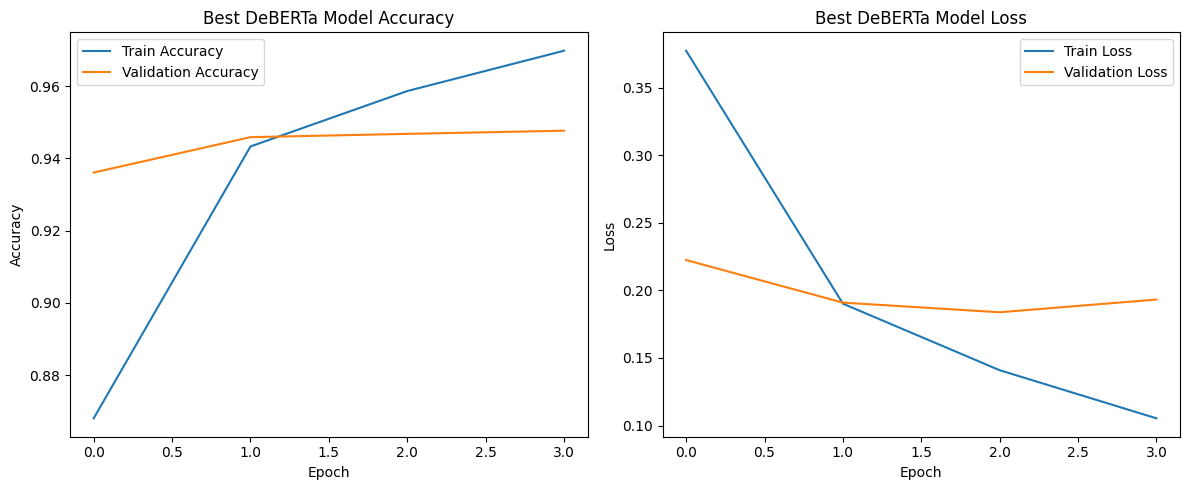

In [64]:
best_deberta_history = deberta_all_histories[str(SAVED_MODELS_DIR / deberta_results_df.iloc[0]["checkpoint"])]

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(best_deberta_history["train_accuracies"], label="Train Accuracy")
plt.plot(best_deberta_history["val_accuracies"], label="Validation Accuracy")
plt.title("Best DeBERTa Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(best_deberta_history["train_losses"], label="Train Loss")
plt.plot(best_deberta_history["val_losses"], label="Validation Loss")
plt.title("Best DeBERTa Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

The above figure illustrates the training and validation accuracy and loss curves of the best-performing DeBERTa-v3 model. The training accuracy increased steadily from approximately 86.9% to 97.0%, while the validation accuracy improved from 93.6% to approximately 94.8% over the training period. The rapid increase in validation accuracy during the early epochs indicates that the model was able to learn meaningful contextual representations quickly, while the subsequent plateau suggests that performance gains became marginal after the initial learning phase.  

The loss curves provide further insight into the model's learning behaviour. Training loss decreased consistently from approximately 0.38 to 0.11, demonstrating successful optimization of the model parameters. Validation loss also decreased during the first few epochs before stabilizing and exhibiting a slight increase toward the final epoch. This pattern suggests the onset of mild overfitting, where the model continued to improve on the training data but achieved limited additional gains on unseen validation samples.  

Despite the small gap between training and validation performance, the validation accuracy remained stable throughout training, indicating strong generalization capability. Overall, the DeBERTa-v3 model achieved high classification performance while maintaining a good balance between learning effectiveness and generalization on the AG News dataset.

###### 5.2.1.4.3 DeBERTa-v3 Model Evaluation on Validation Dataset

In [65]:
# Validation evaluation for best BERT model
val_preds_deberta = []
val_labels_deberta = []

# Define bert_val_loader, as it might have been skipped during hyperparameter search resume
deberta_val_loader = DataLoader(
    deberta_val_dataset,
    batch_size=best_deberta_params["batch_size"],
    shuffle=False,
    num_workers=0,
    drop_last=False
)

best_model_deberta.eval()

# Explicitly ensure the model and its submodules are in float32 just before inference
best_model_deberta.float() # Ensure top-level model parameters are float32

# Also explicitly ensure the internal deberta model operates in float32
# This targets the potential source of float16 outputs from the pre-trained model
if hasattr(best_model_deberta, 'deberta'):
    best_model_deberta.deberta.float()

with torch.no_grad():
    for batch in deberta_val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = best_model_deberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        _, predicted = torch.max(outputs, 1)

        val_preds_deberta.extend(predicted.cpu().numpy())
        val_labels_deberta.extend(labels.cpu().numpy())

val_preds_deberta = np.array(val_preds_deberta)
val_labels_deberta = np.array(val_labels_deberta)

val_accuracy_deberta = (val_preds_deberta == val_labels_deberta).mean()
print(f"DeBERTa-v3 Validation Accuracy: {val_accuracy_deberta:.4f}")

DeBERTa-v3 Validation Accuracy: 0.9477


In [66]:
# ----------------------------
# Classification Report
# ----------------------------
print("\nDeBERTa-v3 Classification Report on Validation Set:")
print(classification_report(val_labels_deberta, val_preds_deberta, target_names=class_names))


DeBERTa-v3 Classification Report on Validation Set:
              precision    recall  f1-score   support

       World       0.96      0.95      0.96      6000
      Sports       0.99      0.99      0.99      6000
    Business       0.93      0.91      0.92      6000
    Sci/Tech       0.91      0.94      0.93      6000

    accuracy                           0.95     24000
   macro avg       0.95      0.95      0.95     24000
weighted avg       0.95      0.95      0.95     24000



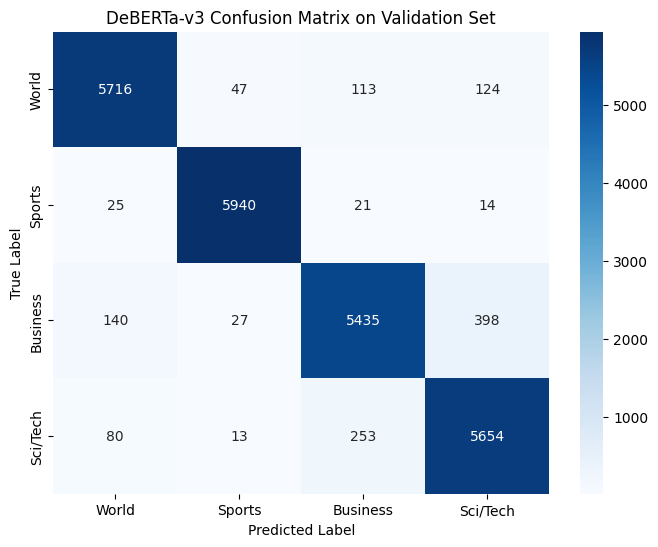

In [67]:
# ----------------------------
# Confusion Matrix
# ----------------------------
cm_deberta_val = confusion_matrix(val_labels_deberta, val_preds_deberta)

class_names = ["World", "Sports", "Business", "Sci/Tech"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_deberta_val,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("DeBERTa-v3 Confusion Matrix on Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [68]:
# ----------------------------
# Per-Class Accuracy
# ----------------------------
class_names = ["World", "Sports", "Business", "Sci/Tech"]

print("Each Class Accuracy of DeBERTa-v3 Model on Validation Set:")
print("-" * 50)

for i, class_name in enumerate(class_names):
    correct = cm_deberta_val[i, i]
    total = cm_deberta_val[i].sum()
    accuracy = (correct / total) * 100
    print(
        f"{class_name}: Accuracy = "
        f"{accuracy:.2f}% "
        f"({correct}/{total})"
    )

Each Class Accuracy of DeBERTa-v3 Model on Validation Set:
--------------------------------------------------
World: Accuracy = 95.27% (5716/6000)
Sports: Accuracy = 99.00% (5940/6000)
Business: Accuracy = 90.58% (5435/6000)
Sci/Tech: Accuracy = 94.23% (5654/6000)


###### 5.2.1.4.4 DeBERTa-v3 Model Evaluation on Test Dataset
After selecting the best-performing model based on validation performance, inference was performed on the unseen test dataset to assess the model's generalization capability. Final classification metrics, including accuracy, precision, recall, and F1-score, were computed to provide a comprehensive assessment of the model's effectiveness on previously unseen news articles.

In [69]:
# Test evaluation for best BERT model
test_preds_deberta = []
test_labels_deberta = []

# Define deberta_test_loader
best_batch_size_deberta = best_deberta_params["batch_size"]
deberta_test_loader = DataLoader(
    deberta_test_dataset,
    batch_size=best_batch_size_deberta,
    shuffle=False,
    num_workers=0,
    drop_last=False
)

best_model_deberta.eval()

with torch.no_grad():
    for batch in deberta_test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = best_model_deberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        _, predicted = torch.max(outputs, 1)

        test_preds_deberta.extend(predicted.cpu().numpy())
        test_labels_deberta.extend(labels.cpu().numpy())

test_preds_deberta = np.array(test_preds_deberta)
test_labels_deberta = np.array(test_labels_deberta)

test_accuracy_deberta = (test_preds_deberta == test_labels_deberta).mean()
print(f"DeBERTa Test Accuracy: {test_accuracy_deberta:.4f}")

DeBERTa Test Accuracy: 0.9463


In [70]:
# ----------------------------
# Classification Report
# ----------------------------
print("\nDeBERTa-v3 Classification Report on Test Set:")
print(classification_report(test_labels_deberta, test_preds_deberta, target_names=class_names))


DeBERTa-v3 Classification Report on Test Set:
              precision    recall  f1-score   support

       World       0.95      0.95      0.95      1900
      Sports       0.99      0.99      0.99      1900
    Business       0.93      0.90      0.92      1900
    Sci/Tech       0.91      0.94      0.93      1900

    accuracy                           0.95      7600
   macro avg       0.95      0.95      0.95      7600
weighted avg       0.95      0.95      0.95      7600



The classification report for the DeBERTa-v3 model on the test set demonstrates strong and consistent performance, achieving an overall accuracy of 0.95. The macro and weighted averages for precision, recall, and F1-score are all 0.95, indicating that the model performs reliably and maintains balanced effectiveness across all classes.  

Class-wise results show that the model performs exceptionally well on the Sports category, with precision, recall, and F1-score all reaching 0.99, reflecting near-perfect classification. The World category also exhibits strong performance, with stable precision and recall of 0.95, indicating consistent and accurate classification of global news articles.  

Performance is slightly lower for the Business category, particularly in recall (0.90), suggesting that some instances are misclassified into other categories. Similarly, the Sci/Tech category shows a minor imbalance, with higher recall (0.94) than precision (0.91), indicating the model captures most relevant instances but introduces some false positives.  


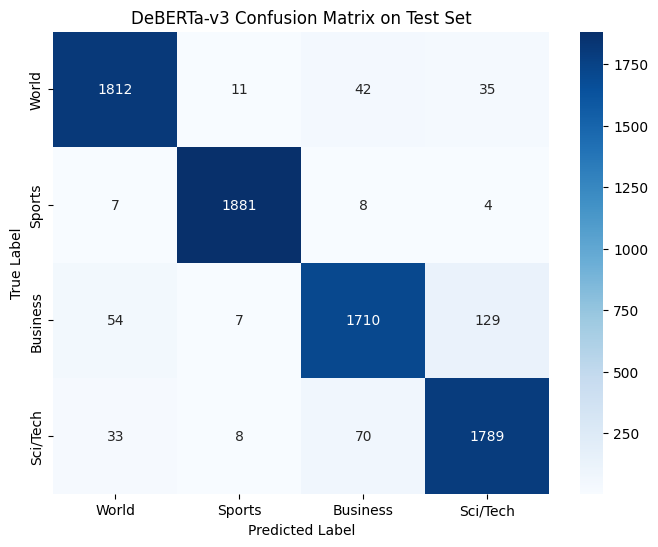

In [71]:
# ----------------------------
# Confusion Matrix
# ----------------------------
cm_deberta_test = confusion_matrix(test_labels_deberta, test_preds_deberta)

class_names = ["World", "Sports", "Business", "Sci/Tech"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_deberta_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("DeBERTa-v3 Confusion Matrix on Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The figure above presents the confusion matrix for the DeBERTa-v3 model on the test dataset.

The Sports class achieved the highest classification performance, with 1881 out of 1900 samples correctly identified and very few misclassifications. Similarly, the World category demonstrated strong performance, with 1812 correctly classified samples.

Some confusion occurred between the Business and Sci/Tech categories. Specifically, 129 Business articles were misclassified as Sci/Tech, while 70 Sci/Tech articles were misclassified as Business.


**Each class accuracy on test dataset are also outlined below:**

In [72]:
# ----------------------------
# Per-Class Accuracy
# ----------------------------
class_names = ["World", "Sports", "Business", "Sci/Tech"]

print("Each Class Accuracy of DeBERTa Model on Test Set:")
print("-" * 50)

for i, class_name in enumerate(class_names):
    correct = cm_deberta_test[i, i]
    total = cm_deberta_test[i].sum()
    accuracy = (correct / total) * 100
    print(
        f"{class_name}: Accuracy = "
        f"{accuracy:.2f}% "
        f"({correct}/{total})"
    )

Each Class Accuracy of DeBERTa Model on Test Set:
--------------------------------------------------
World: Accuracy = 95.37% (1812/1900)
Sports: Accuracy = 99.00% (1881/1900)
Business: Accuracy = 90.00% (1710/1900)
Sci/Tech: Accuracy = 94.16% (1789/1900)


#### 5.2.2 RoBERTa
RoBERTa (Robustly Optimized BERT Pretraining Approach) is an improved version of BERT, designed for natural language understanding tasks such as text classification. It uses a transformer encoder architecture to learn deep contextual relationships between words and is trained on larger datasets with optimized training strategies, resulting in stronger performance compared to the original BERT model.

In [73]:
# Define the RoBERTa Model
class RobertaClassifier(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.1, model_path=roberta_save_path):
        super().__init__()

        self.roberta = RobertaModel.from_pretrained(model_path)
        hidden_size = self.roberta.config.hidden_size

        self.dropout = nn.Dropout(dropout_rate)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.LayerNorm(256),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        x = outputs.last_hidden_state[:, 0, :]
        x = self.dropout(x)
        return self.classifier(x)

##### 5.2.2.1 RoBERTa Architecture
A pretrained RoBERTa encoder extracts the `CLS` token embedding, which is passed through dropout and a classifier to predict class labels.

##### 5.2.2.2 RoBERTa Hyperparameters Tuning
Hyperparameter tuning was performed by testing several combinations of learning rate, batch size, dropout rate, and number of epochs. For each configuration, the model was trained and the best checkpoint based on validation accuracy was saved. The saved models were then compared, and the one with the highest validation accuracy was selected for final testing. **For full details on the
hyperparameter search and model training, refer to Appendix A.**

In [74]:
roberta_param_grid = [
    {"learning_rate": 3e-5, "batch_size": 16, "dropout_rate": 0.1,  "num_epochs": 5},
    {"learning_rate": 2e-5, "batch_size": 16, "dropout_rate": 0.1,  "num_epochs": 5},
    {"learning_rate": 3e-5, "batch_size": 32, "dropout_rate": 0.1,  "num_epochs": 4},
    {"learning_rate": 2e-5, "batch_size": 32, "dropout_rate": 0.15, "num_epochs": 5},
    {"learning_rate": 5e-5, "batch_size": 16, "dropout_rate": 0.1,  "num_epochs": 4},
]

roberta_experiment_results = []
roberta_all_histories = {}

##### 5.2.2.3 RoBERTa Training

In [75]:
# ----------------------------
# Global resume tracking for RoBERTa
# ----------------------------
roberta_total_experiments = len(roberta_param_grid)
roberta_resume_experiment = 1
roberta_global_checkpoint = SAVED_MODELS_DIR / "roberta_hparam_search_state.pth"

roberta_all_done = False

if roberta_global_checkpoint.exists():
    print("Global RoBERTa experiment checkpoint found...")
    roberta_global_state = torch.load(roberta_global_checkpoint, map_location=device)

    saved_idx = roberta_global_state.get("experiment_idx", 1)
    roberta_experiment_results = roberta_global_state.get("experiment_results", [])
    roberta_all_histories = roberta_global_state.get("all_histories", {})

    if saved_idx > roberta_total_experiments:
        roberta_all_done = True
        roberta_resume_experiment = roberta_total_experiments + 1
        print(f"All {roberta_total_experiments} RoBERTa experiments are already completed.")
    else:
        roberta_resume_experiment = max(1, saved_idx)
        print(f"Resuming from RoBERTa experiment {roberta_resume_experiment} of {roberta_total_experiments}")
else:
    print("No global RoBERTa experiment checkpoint found.")

Global RoBERTa experiment checkpoint found...
All 5 RoBERTa experiments are already completed.


In [76]:
# =====================================================================================
# BERT HYPERPARAMETER SEARCH
# =====================================================================================
if roberta_all_done:
    print("All experiments were previously completed. Skipping hyperparameter search and loading saved *.pth files...")
else:
    for exp_idx, params in enumerate(roberta_param_grid, start=1):

        # ----------------------------
        # Skip already-finished experiments
        # ----------------------------
        if exp_idx < roberta_resume_experiment:
            print(f"Skipping completed experiment {exp_idx}")
            continue

        print("=" * 100)
        print(f"Experiment {exp_idx}/{len(roberta_param_grid)}")
        print("Parameters:", params)
        print("=" * 100)

        # ----------------------------
        # DataLoaders
        # ----------------------------
        roberta_train_loader = DataLoader(
            roberta_train_dataset,
            batch_size=params["batch_size"],
            shuffle=True,
            num_workers=0,
            drop_last=False
        )

        roberta_val_loader = DataLoader(
            roberta_val_dataset,
            batch_size=params["batch_size"],
            shuffle=False,
            num_workers=0,
            drop_last=False
        )

        # ----------------------------
        # Model / Optimizer / Loss / Scheduler
        # ----------------------------
        roberta_model = RobertaClassifier(
            num_classes=4,
            dropout_rate=params["dropout_rate"],
            model_path=roberta_save_path
        ).to(device)


        roberta_criterion = nn.CrossEntropyLoss()

        roberta_optimizer = torch.optim.AdamW(
            roberta_model.parameters(),
            lr=params["learning_rate"],
            weight_decay=0.01
        )

        # ----------------------------
        # Warmup + Linear Decay Scheduler
        # ----------------------------
        total_training_steps = len(roberta_train_loader) * params["num_epochs"]
        warmup_steps = int(0.1 * total_training_steps)   # 10% warmup

        roberta_scheduler = get_linear_schedule_with_warmup(
            roberta_optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_training_steps
        )

        # ----------------------------
        # Experiment tracking
        # ----------------------------
        best_val_acc = 0.0
        best_val_loss = float("inf")
        best_epoch = 0
        best_model_state_dict = None

        patience = 3
        epochs_without_improvement = 0

        train_losses, val_losses = [], []
        train_accuracies, val_accuracies = [], []

        # ----------------------------
        # Checkpoint name
        # ----------------------------
        lr_str = f"{params['learning_rate']:.5f}".replace(".", "_")
        drop_str = str(params["dropout_rate"]).replace(".", "_")

        checkpoint_name = (
            SAVED_MODELS_DIR / f"roberta_exp{exp_idx}_"
            f"lr{lr_str}_bs{params['batch_size']}_drop{drop_str}.pth"
        )

        start_epoch = 0

        # ----------------------------
        # Resume experiment if checkpoint exists
        # ----------------------------
        if os.path.exists(checkpoint_name):
            print("Checkpoint found. Resuming training...")
            checkpoint = torch.load(checkpoint_name, map_location=device)

            roberta_model.load_state_dict(checkpoint["latest_model_state_dict"])
            roberta_optimizer.load_state_dict(checkpoint["latest_optimizer_state_dict"])

            if "latest_scheduler_state_dict" in checkpoint:
                roberta_scheduler.load_state_dict(checkpoint["latest_scheduler_state_dict"])

            start_epoch = checkpoint.get("epoch", 0)
            best_val_acc = checkpoint.get("best_val_acc", 0.0)
            best_val_loss = checkpoint.get("best_val_loss", float("inf"))
            best_epoch = checkpoint.get("best_epoch", 0)
            best_model_state_dict = checkpoint.get("best_model_state_dict", None)
            epochs_without_improvement = checkpoint.get("epochs_without_improvement", 0)

            train_losses = checkpoint.get("train_losses", [])
            val_losses = checkpoint.get("val_losses", [])
            train_accuracies = checkpoint.get("train_accuracies", [])
            val_accuracies = checkpoint.get("val_accuracies", [])

            print(f"Resuming from epoch {start_epoch}")
        else:
            print("No experiment checkpoint found. Starting fresh.")

        start_time = time.time()

        # ----------------------------
        # Training loop
        # ----------------------------
        for epoch in range(start_epoch, params["num_epochs"]):
            roberta_model.train()
            running_loss, correct, total = 0.0, 0, 0
            epoch_start = time.time()

            for batch in roberta_train_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                roberta_optimizer.zero_grad()

                outputs = roberta_model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                loss = roberta_criterion(outputs, labels)
                loss.backward()

                torch.nn.utils.clip_grad_norm_(roberta_model.parameters(), max_norm=1.0)

                roberta_optimizer.step()
                roberta_scheduler.step()

                running_loss += loss.item() * input_ids.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            epoch_train_loss = running_loss / total
            epoch_train_acc = correct / total
            train_losses.append(epoch_train_loss)
            train_accuracies.append(epoch_train_acc)

            # ----------------------------
            # Validation
            # ----------------------------
            roberta_model.eval()
            val_running_loss, val_correct, val_total = 0.0, 0, 0

            with torch.no_grad():
                for batch in roberta_val_loader:
                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels = batch["labels"].to(device)

                    outputs = roberta_model(
                        input_ids=input_ids,
                        attention_mask=attention_mask
                    )

                    loss = roberta_criterion(outputs, labels)

                    val_running_loss += loss.item() * input_ids.size(0)
                    _, predicted = torch.max(outputs, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()

            epoch_val_loss = val_running_loss / val_total
            epoch_val_acc = val_correct / val_total
            val_losses.append(epoch_val_loss)
            val_accuracies.append(epoch_val_acc)

            epoch_duration = time.time() - epoch_start

            print(
                f"Epoch [{epoch+1}/{params['num_epochs']}] "
                f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, "
                f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}, "
                f"LR: {roberta_optimizer.param_groups[0]['lr']:.6f}, Time: {epoch_duration:.2f}s"
            )

            # ----------------------------
            # Best model tracking
            # ----------------------------
            if epoch_val_acc > best_val_acc:
                best_val_acc = epoch_val_acc
                best_val_loss = epoch_val_loss
                best_epoch = epoch + 1
                epochs_without_improvement = 0

                best_model_state_dict = {
                    k: v.detach().cpu().clone()
                    for k, v in roberta_model.state_dict().items()
                }

                print("Best model improved.")
            else:
                epochs_without_improvement += 1

            total_elapsed = time.time() - start_time

            # ----------------------------
            # Save checkpoint
            # ----------------------------
            safe_torch_save({
                "epoch": epoch + 1,
                "experiment_idx": exp_idx,
                "latest_model_state_dict": roberta_model.state_dict(),
                "latest_optimizer_state_dict": roberta_optimizer.state_dict(),
                "latest_scheduler_state_dict": roberta_scheduler.state_dict(),
                "best_model_state_dict": best_model_state_dict,
                "best_val_acc": best_val_acc,
                "best_val_loss": best_val_loss,
                "best_epoch": best_epoch,
                "val_acc": epoch_val_acc,
                "val_loss": epoch_val_loss,
                "epochs_without_improvement": epochs_without_improvement,
                "params": params,
                "total_training_time_sec": total_elapsed,
                "train_losses": train_losses,
                "val_losses": val_losses,
                "train_accuracies": train_accuracies,
                "val_accuracies": val_accuracies
            }, str(checkpoint_name))


            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        # ----------------------------
        # Update experiment results
        # ----------------------------
        roberta_experiment_results = [
            r for r in roberta_experiment_results
            if r.get("experiment") != exp_idx
        ]

        roberta_experiment_results.append({
            "experiment": exp_idx,
            "learning_rate": params["learning_rate"],
            "batch_size": params["batch_size"],
            "dropout_rate": params["dropout_rate"],
            "num_epochs": params["num_epochs"],
            "best_val_acc": best_val_acc,
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
            "checkpoint": checkpoint_name.name
        })

        roberta_all_histories[str(checkpoint_name)] = {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accuracies": train_accuracies,
            "val_accuracies": val_accuracies
        }

        safe_torch_save({
            "experiment_idx": exp_idx + 1,
            "experiment_results": roberta_experiment_results,
            "all_histories": roberta_all_histories
        }, str(roberta_global_checkpoint))

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

All experiments were previously completed. Skipping hyperparameter search and loading saved *.pth files...


##### 5.2.2.4 RoBERTa Evaluation

In [77]:
roberta_results_csv_path = (SAVED_MODELS_DIR / "roberta_hyperparameter_results.csv")

if roberta_results_csv_path.exists():
    print("Loading existing hyperparameter results...")
    roberta_results_df = pd.read_csv(roberta_results_csv_path)
else:
    print("Creating hyperparameter results...")
    roberta_results_df = pd.DataFrame(roberta_experiment_results)

    if not roberta_results_df.empty:
        roberta_results_df = roberta_results_df.sort_values(by="best_val_acc", ascending=False).reset_index(drop=True)
        roberta_results_df.to_csv(roberta_results_csv_path, index=False)
        print(f"Saved tuning results to {roberta_results_csv_path}")
    else:
        print("No RoBERTa experiment results found. Please ensure the hyperparameter search completed successfully.")

print("\nRoBERTa Tuning Results:")
print(roberta_results_df)

Loading existing hyperparameter results...

RoBERTa Tuning Results:
   experiment  learning_rate  batch_size  dropout_rate  num_epochs  \
0           3        0.00003          32          0.10           4   
1           2        0.00002          16          0.10           5   
2           4        0.00002          32          0.15           5   
3           1        0.00003          16          0.10           5   
4           5        0.00005          16          0.10           4   

   best_val_acc  best_val_loss  best_epoch  \
0      0.951625       0.180256           3   
1      0.950417       0.218626           4   
2      0.950250       0.194304           4   
3      0.949750       0.268209           5   
4      0.948417       0.210642           3   

                                 checkpoint  
0   roberta_exp3_lr0_00003_bs32_drop0_1.pth  
1   roberta_exp2_lr0_00002_bs16_drop0_1.pth  
2  roberta_exp4_lr0_00002_bs32_drop0_15.pth  
3   roberta_exp1_lr0_00003_bs16_drop0_1.pth  
4   

In [78]:
# =====================================
# CREATE STANDALONE BEST ROBERTA MODEL
# =====================================
if not roberta_results_df.empty:
    roberta_best_checkpoint_path = (SAVED_MODELS_DIR / roberta_results_df.iloc[0]["checkpoint"])

    print("\nBest RoBERTa checkpoint found:")
    print(roberta_best_checkpoint_path)

    roberta_best_checkpoint = torch.load(roberta_best_checkpoint_path, map_location=device)
    roberta_best_model_path = (SAVED_MODELS_DIR / "roberta_best_model.pth")
    safe_torch_save(roberta_best_checkpoint, str(roberta_best_model_path))
    print(f"\nSaved standalone best model:\n"f"{roberta_best_model_path}")

else:
    print("Cannot create standalone best model because roberta_results_df is empty.")


Best RoBERTa checkpoint found:
/content/drive/MyDrive/tafe/src/news/saved_models/roberta_exp3_lr0_00003_bs32_drop0_1.pth

Saved standalone best model:
/content/drive/MyDrive/tafe/src/news/saved_models/roberta_best_model.pth


After determining the best hyperparameter configuration for the RoBERTa model, the same configuration was used to train multiple models with different random seeds. Multi-seed training was employed to reduce the impact of random initialization and training variability, improve model robustness, and generate diverse models for subsequent ensemble learning.

In [79]:
# =====================================
# ROBERTA MULTI-SEED TRAINING
# =====================================
RUN_MULTI_SEED_TRAINING = True

if RUN_MULTI_SEED_TRAINING:

    seeds = [42, 123, 999, 2025, 777]

    roberta_best_checkpoint = torch.load(
        SAVED_MODELS_DIR / "roberta_best_model.pth",
        map_location=device
    )

    best_roberta_params = roberta_best_checkpoint["params"]

    print("\nBest Parameters:")
    print(best_roberta_params)

    completed_seeds = []

    for seed in seeds:

        save_path = (
            SAVED_MODELS_DIR /
            f"roberta_seed{seed}_best.pth"
        )

        if save_path.exists():
            completed_seeds.append(seed)

    print(f"Completed seeds: {completed_seeds}")

    for seed in seeds:
        save_path = (
            SAVED_MODELS_DIR /
            f"roberta_seed{seed}_best.pth"
        )

        if save_path.exists():
            print(
                f"Seed {seed} already completed. "
                f"Skipping {save_path.name}"
            )

            continue

        print("=" * 100)
        print(f"Training RoBERTa with Seed {seed}")
        print("=" * 100)

        set_seed(seed)

        params = best_roberta_params

        roberta_train_loader = DataLoader(
            roberta_train_dataset,
            batch_size=params["batch_size"],
            shuffle=True,
            num_workers=0,
            drop_last=False
        )

        roberta_val_loader = DataLoader(
            roberta_val_dataset,
            batch_size=params["batch_size"],
            shuffle=False,
            num_workers=0,
            drop_last=False
        )

        roberta_model = RobertaClassifier(
            num_classes=4,
            dropout_rate=params["dropout_rate"],
            model_path=roberta_save_path
        ).to(device).float()

        roberta_criterion = nn.CrossEntropyLoss()

        roberta_optimizer = torch.optim.AdamW(
            roberta_model.parameters(),
            lr=params["learning_rate"],
            weight_decay=0.01
        )

        total_training_steps = (
            len(roberta_train_loader)
            * params["num_epochs"]
        )

        warmup_steps = int(
            0.1 * total_training_steps
        )

        roberta_scheduler = (
            get_linear_schedule_with_warmup(
                roberta_optimizer,
                num_warmup_steps=warmup_steps,
                num_training_steps=total_training_steps
            )
        )

        best_val_acc = 0.0
        best_model_state_dict = None

        patience = 3
        epochs_without_improvement = 0

        for epoch in range(params["num_epochs"]):

            roberta_model.train()

            running_loss = 0.0
            correct = 0
            total = 0

            for batch in roberta_train_loader:

                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                roberta_optimizer.zero_grad()

                outputs = roberta_model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                loss = roberta_criterion(
                    outputs,
                    labels
                )

                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    roberta_model.parameters(),
                    max_norm=1.0
                )

                roberta_optimizer.step()
                roberta_scheduler.step()

                running_loss += (
                    loss.item() *
                    input_ids.size(0)
                )

                _, predicted = torch.max(
                    outputs,
                    1
                )

                total += labels.size(0)

                correct += (
                    predicted == labels
                ).sum().item()

            roberta_model.eval()

            val_correct = 0
            val_total = 0

            with torch.no_grad():

                for batch in roberta_val_loader:

                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels = batch["labels"].to(device)

                    outputs = roberta_model(
                        input_ids=input_ids,
                        attention_mask=attention_mask
                    )

                    _, predicted = torch.max(
                        outputs,
                        1
                    )

                    val_total += labels.size(0)

                    val_correct += (
                        predicted == labels
                    ).sum().item()

            val_acc = val_correct / val_total

            print(
                f"Seed {seed} | "
                f"Epoch {epoch+1}/{params['num_epochs']} | "
                f"Val Acc: {val_acc:.4f}"
            )

            if val_acc > best_val_acc:

                best_val_acc = val_acc

                epochs_without_improvement = 0

                best_model_state_dict = {
                    k: v.detach().cpu().clone()
                    for k, v in roberta_model.state_dict().items()
                }

            else:

                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:

                print(
                    f"Early stopping at epoch {epoch+1}"
                )

                break

        checkpoint = {
            "seed": seed,
            "params": params,
            "best_val_acc": best_val_acc,
            "best_model_state_dict": best_model_state_dict
        }

        safe_torch_save(
            checkpoint,
            str(save_path)
        )

        print(
            f"Saved: {save_path}"
        )


Best Parameters:
{'learning_rate': 3e-05, 'batch_size': 32, 'dropout_rate': 0.1, 'num_epochs': 4}
Completed seeds: [42, 123, 999, 2025, 777]
Seed 42 already completed. Skipping roberta_seed42_best.pth
Seed 123 already completed. Skipping roberta_seed123_best.pth
Seed 999 already completed. Skipping roberta_seed999_best.pth
Seed 2025 already completed. Skipping roberta_seed2025_best.pth
Seed 777 already completed. Skipping roberta_seed777_best.pth


###### 5.2.2.4.1 Load Best RoBERTa Model for Evaluation
Load the saved `.pth` checkpoint and set model to evaluation mode.

In [80]:
# ==================================================
# OPTION 1: Load standalone best model
# ==================================================
roberta_checkpoint = torch.load(
    SAVED_MODELS_DIR / "roberta_best_model.pth",
    map_location=device
)

print("Loaded standalone best model:", SAVED_MODELS_DIR / "roberta_best_model.pth")

# ==================================================
# OPTION 2: Load from hyperparameter search
# Requires all experiment checkpoints
# ==================================================
# best_roberta_checkpoint_path = (SAVED_MODELS_DIR / roberta_results_df.iloc[0]["checkpoint"])
# print("Best RoBERTa checkpoint selected:", best_roberta_checkpoint_path)

# roberta_checkpoint = torch.load(
#     best_roberta_checkpoint_path,
#     map_location=device
# )

best_roberta_params = roberta_checkpoint["params"]

# Load best checkpoint path from results
best_roberta_checkpoint_path = roberta_results_df.iloc[0]["checkpoint"]
print("Best RoBERTa checkpoint selected:", best_roberta_checkpoint_path)

# Load checkpoint
roberta_checkpoint = torch.load(SAVED_MODELS_DIR / best_roberta_checkpoint_path, map_location=device)
best_roberta_params = roberta_checkpoint["params"]

# Rebuild RoBERTa model with best params
best_model_roberta = RobertaClassifier(
    num_classes=4,
    dropout_rate=best_roberta_params["dropout_rate"]
).to(device)

# Safety check
if roberta_checkpoint.get("best_model_state_dict") is None:
    raise ValueError("Best RoBERTa model state dict is None. Training may not have completed properly.")

# Load best weights
best_model_roberta.load_state_dict(roberta_checkpoint["best_model_state_dict"])
best_model_roberta.float() # Ensure all model parameters are float32
best_model_roberta.eval()

Loaded standalone best model: /content/drive/MyDrive/tafe/src/news/saved_models/roberta_best_model.pth
Best RoBERTa checkpoint selected: roberta_exp3_lr0_00003_bs32_drop0_1.pth


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaClassifier(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): L

###### 5.2.2.4.2 Training History Analysis of Best RoBERTa Model
These plots show the best model’s training/validation loss accuracy curves.

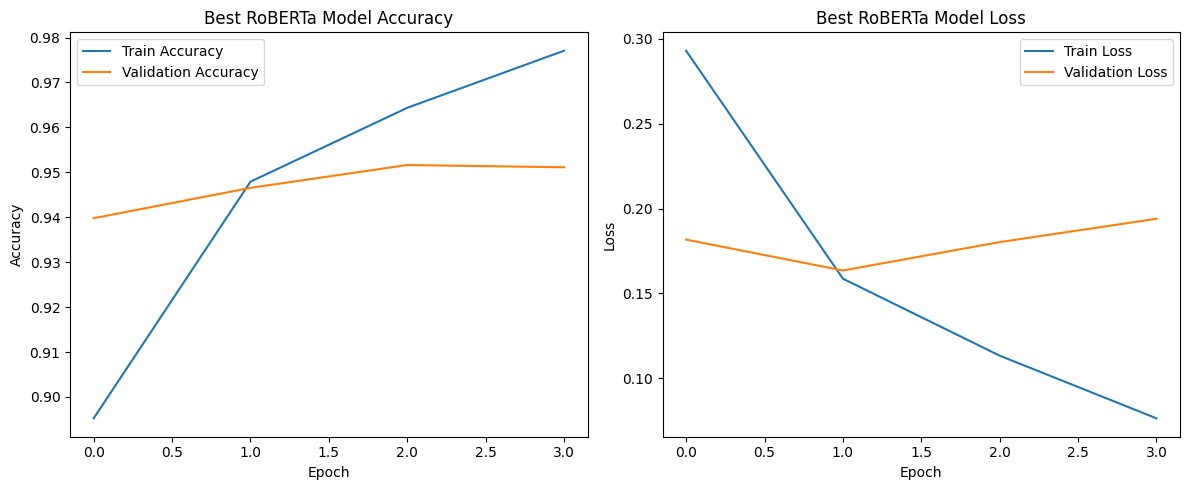

In [81]:
best_roberta_history = roberta_all_histories[str(SAVED_MODELS_DIR / roberta_results_df.iloc[0]["checkpoint"].replace("roberta", "bert"))]

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(best_roberta_history["train_accuracies"], label="Train Accuracy")
plt.plot(best_roberta_history["val_accuracies"], label="Validation Accuracy")
plt.title("Best RoBERTa Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(best_roberta_history["train_losses"], label="Train Loss")
plt.plot(best_roberta_history["val_losses"], label="Validation Loss")
plt.title("Best RoBERTa Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

The plots illustrate the training and validation accuracy and loss of the RoBERTa model across epochs. The accuracy curve shows that training accuracy increases steadily, rising from approximately 0.89 to 0.98, indicating that the model continues to learn and fit the training data effectively. In contrast, validation accuracy improves initially from around 0.94 to 0.95 but plateaus after epoch 2, with minimal improvement thereafter.  

The loss curves further highlight this behaviour. Training loss decreases consistently from approximately 0.29 to 0.08, reflecting improved model fit on the training data. However, validation loss initially decreases to around 0.16 at epoch 1, before gradually increasing to approximately 0.19, indicating a decline in generalisation performance.  

Together, these trends suggest that the model begins to overfit after the early epochs, particularly after epoch 1-2. While the model continues to improve on the training data, the increasing validation loss and stagnant validation accuracy indicate that it is no longer learning generalisable patterns.  

###### 5.2.2.4.3 RoBERTa Model Evaluation on Validation Dataset

In [82]:
# Validation evaluation for best RoBERTa model
val_preds_roberta = []
val_labels_roberta = []

# Define roberta_val_loader, as it might have been skipped during hyperparameter search resume
roberta_val_loader = DataLoader(
    roberta_val_dataset,
    batch_size=best_roberta_params["batch_size"],
    shuffle=False,
    num_workers=0,
    drop_last=False
)

best_model_roberta.eval()

with torch.no_grad():
    for batch in roberta_val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs =best_model_roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        _, predicted = torch.max(outputs, 1)

        val_preds_roberta.extend(predicted.cpu().numpy())
        val_labels_roberta.extend(labels.cpu().numpy())

val_preds_roberta = np.array(val_preds_roberta)
val_labels_roberta = np.array(val_labels_roberta)

val_accuracy_roberta = (val_preds_roberta == val_labels_roberta).mean()
print(f"RoBERTa Validation Accuracy: {val_accuracy_roberta:.4f}")

RoBERTa Validation Accuracy: 0.9516


In [83]:
# ----------------------------
# Classification Report
# ----------------------------
print("\nRoBERTa Classification Report on Validation Set:")
print(classification_report(val_labels_roberta, val_preds_roberta, target_names=class_names))


RoBERTa Classification Report on Validation Set:
              precision    recall  f1-score   support

       World       0.97      0.95      0.96      6000
      Sports       0.99      0.99      0.99      6000
    Business       0.93      0.92      0.92      6000
    Sci/Tech       0.92      0.94      0.93      6000

    accuracy                           0.95     24000
   macro avg       0.95      0.95      0.95     24000
weighted avg       0.95      0.95      0.95     24000



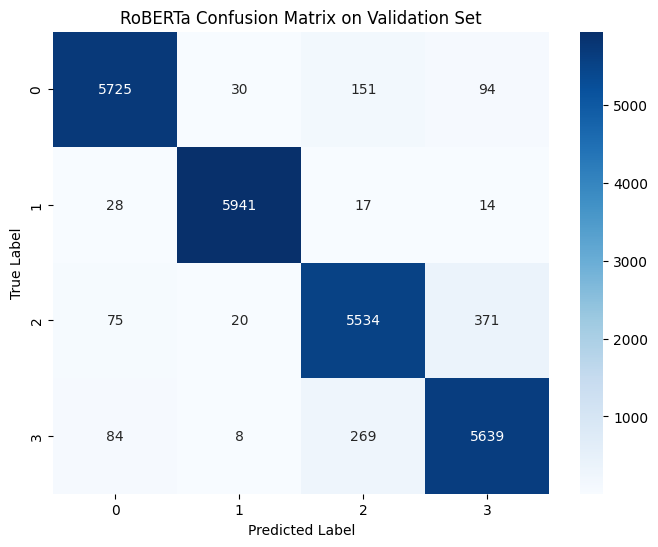

In [84]:
# ----------------------------
# Confusion Matrix
# ----------------------------
cm_roberta_val = confusion_matrix(val_labels_roberta, val_preds_roberta)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_roberta_val, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("RoBERTa Confusion Matrix on Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [85]:
# ----------------------------
# Per-Class Accuracy
# ----------------------------
class_names = ["World", "Sports", "Business", "Sci/Tech"]

print("Each Class Accuracy of RoBERTa Model on Validation Set:")
print("-" * 50)

for i, class_name in enumerate(class_names):
    correct = cm_roberta_val[i, i]
    total = cm_roberta_val[i].sum()
    accuracy = (correct / total) * 100
    print(
        f"{class_name}: Accuracy = "
        f"{accuracy:.2f}% "
        f"({correct}/{total})"
    )

Each Class Accuracy of RoBERTa Model on Validation Set:
--------------------------------------------------
World: Accuracy = 95.42% (5725/6000)
Sports: Accuracy = 99.02% (5941/6000)
Business: Accuracy = 92.23% (5534/6000)
Sci/Tech: Accuracy = 93.98% (5639/6000)


###### 5.2.2.4.4 RoBERTa Model Evaluation on Test Dataset
After selecting the best-performing model based on validation performance, inference was performed on the unseen test dataset to assess the model's generalization capability. Final classification metrics, including accuracy, precision, recall, and F1-score, were computed to provide a comprehensive assessment of the model's effectiveness on previously unseen news articles.

In [86]:
# Test evaluation for best RoBERTa model
test_preds_roberta = []
test_labels_roberta = []

# Define roberta_test_loader
best_batch_size_roberta = best_roberta_params["batch_size"]
roberta_test_loader = DataLoader(
    roberta_test_dataset,
    batch_size=best_batch_size_roberta,
    shuffle=False,
    num_workers=0,
    drop_last=False
)

best_model_roberta.eval()

with torch.no_grad():
    for batch in roberta_test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = best_model_roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        _, predicted = torch.max(outputs, 1)

        test_preds_roberta.extend(predicted.cpu().numpy())
        test_labels_roberta.extend(labels.cpu().numpy())

test_preds_roberta = np.array(test_preds_roberta)
test_labels_roberta = np.array(test_labels_roberta)

test_accuracy_roberta = (test_preds_roberta == test_labels_roberta).mean()
print(f"RoBERTa Test Accuracy: {test_accuracy_roberta:.4f}")

RoBERTa Test Accuracy: 0.9495


In [87]:
# ----------------------------
# Classification Report
# ----------------------------
print("\nRoBERTa Classification Report on Test Set:")
print(classification_report(test_labels_roberta, test_preds_roberta, target_names=class_names))


RoBERTa Classification Report on Test Set:
              precision    recall  f1-score   support

       World       0.97      0.96      0.96      1900
      Sports       0.99      0.99      0.99      1900
    Business       0.92      0.92      0.92      1900
    Sci/Tech       0.92      0.93      0.93      1900

    accuracy                           0.95      7600
   macro avg       0.95      0.95      0.95      7600
weighted avg       0.95      0.95      0.95      7600



The classification results for the RoBERTa model on the test set demonstrate strong and consistent performance, achieving an overall accuracy of 0.95. The macro and weighted averages for precision, recall, and F1-score are all 0.95, indicating balanced effectiveness across all classes and reliable generalisation to unseen data.  

At the class level, the model performs exceptionally well on the Sports category, with precision, recall, and F1-score all reaching 0.99, reflecting near-perfect classification capability. The World category also shows high performance, with an F1-score of 0.96, indicating consistent and accurate identification of global news content.  

Performance is slightly lower for the Business category, with both precision and recall at 0.92, suggesting some difficulty in distinguishing this class from others. Similarly, the Sci/Tech category achieves a balanced performance, with a slightly higher recall (0.93) than precision (0.92), indicating that the model effectively captures relevant instances but introduces a small number of false positives.


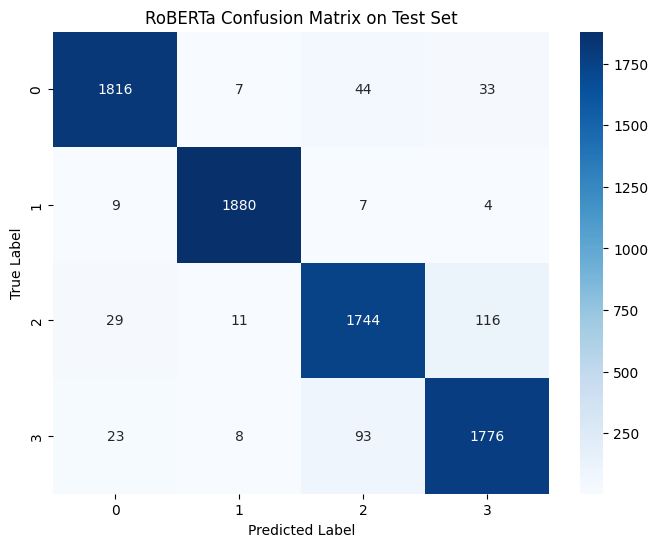

In [88]:
# ----------------------------
# Confusion Matrix
# ----------------------------
cm_roberta_test = confusion_matrix(test_labels_roberta, test_preds_roberta)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_roberta_test, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("RoBERTa Confusion Matrix on Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The figure above presents the confusion matrix for the RoBERTa model on the test dataset.

The Sports class achieved the highest classification performance, with 1880 out of 1900 samples correctly identified and very few misclassifications. Similarly, the World category demonstrated strong performance, with 1816 correctly classified samples.

Some confusion occurred between the Business and Sci/Tech categories. Specifically, 116 Business articles were misclassified as Sci/Tech, while 93 Sci/Tech articles were misclassified as Business.



**Each class accuracy on test dataset are also outlined below:**

In [89]:
# ----------------------------
# Per-Class Accuracy
# ----------------------------
class_names = ["World", "Sports", "Business", "Sci/Tech"]

print("Each Class Accuracy of RoBERTa Model on Test Set:")
print("-" * 50)

for i, class_name in enumerate(class_names):
    correct = cm_roberta_test[i, i]
    total = cm_roberta_test[i].sum()
    accuracy = (correct / total) * 100
    print(
        f"{class_name}: Accuracy = "
        f"{accuracy:.2f}% "
        f"({correct}/{total})"
    )

Each Class Accuracy of RoBERTa Model on Test Set:
--------------------------------------------------
World: Accuracy = 95.58% (1816/1900)
Sports: Accuracy = 98.95% (1880/1900)
Business: Accuracy = 91.79% (1744/1900)
Sci/Tech: Accuracy = 93.47% (1776/1900)


#### 5.2.3 ELECTRA
ELECTRA is a transformer model trained to distinguish real tokens from generator‑replaced tokens, using a discriminator instead of predicting masked words.

##### 5.2.3.1 ELECTRA Architecture
A pretrained ELECTRA discriminator encoder extracts contextual features, and the `CLS` representation is fed through a regularized feed-forward classifier to predict labels.

In [90]:
class ElectraClassifier(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.1, model_path=electra_save_path):
        super().__init__()

        self.electra = AutoModel.from_pretrained(model_path)
        hidden_size = self.electra.config.hidden_size

        self.dropout = nn.Dropout(dropout_rate)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.LayerNorm(256),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.electra(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        x = outputs.last_hidden_state[:, 0, :]
        x = self.dropout(x)

        return self.classifier(x)

##### 5.2.3.2 ELECTRA Hyperparameters Tuning
Hyperparameter tuning was performed by testing several combinations of learning rate, batch size, dropout rate, and number of epochs. For each configuration, the model was trained and the best checkpoint based on validation accuracy was saved. The saved models were then compared, and the one with the highest validation accuracy was selected for final testing. **For full details on the
hyperparameter search and model training, refer to Appendix A.**

In [91]:
electra_param_grid = [
    {"learning_rate": 2e-5, "batch_size": 16, "dropout_rate": 0.1,  "num_epochs": 5},
    {"learning_rate": 3e-5, "batch_size": 16, "dropout_rate": 0.1,  "num_epochs": 5},
    {"learning_rate": 3e-5, "batch_size": 32, "dropout_rate": 0.1,  "num_epochs": 4},
    {"learning_rate": 2e-5, "batch_size": 32, "dropout_rate": 0.15, "num_epochs": 5},
]

electra_experiment_results = []
electra_all_histories = {}

##### 5.2.3.3 ELECTRA Training

In [92]:
# ----------------------------
# Global resume tracking for BERT
# ----------------------------
electra_total_experiments = len(electra_param_grid)
electra_resume_experiment = 1
electra_global_checkpoint = SAVED_MODELS_DIR / "electra_hparam_search_state.pth"

electra_all_done = False

if electra_global_checkpoint.exists():
    print("Global Electra experiment checkpoint found...")
    electra_global_state = torch.load(electra_global_checkpoint, map_location=device)

    saved_idx = electra_global_state.get("experiment_idx", 1)
    electra_experiment_results = electra_global_state.get("experiment_results", [])
    electra_all_histories = electra_global_state.get("all_histories", {})

    if saved_idx > electra_total_experiments:
        electra_all_done = True
        electra_resume_experiment = electra_total_experiments + 1
        print(f"All {electra_total_experiments} Electra experiments are already completed.")
    else:
        electra_resume_experiment = max(1, saved_idx)
        print(f"Resuming from Electra experiment {electra_resume_experiment} of {electra_total_experiments}")
else:
    print("No global Electra experiment checkpoint found.")

Global Electra experiment checkpoint found...
All 4 Electra experiments are already completed.


In [93]:
# =====================================================================================
# ELECTRA HYPERPARAMETER SEARCH
# =====================================================================================
if electra_all_done:
    print("All experiments were previously completed. Skipping hyperparameter search and loading saved *.pth files...")
else:
    for exp_idx, params in enumerate(electra_param_grid, start=1):

        # ----------------------------
        # Skip already-finished experiments
        # ----------------------------
        if exp_idx < electra_resume_experiment:
            print(f"Skipping completed experiment {exp_idx}")
            continue

        print("=" * 100)
        print(f"Experiment {exp_idx}/{len(electra_param_grid)}")
        print("Parameters:", params)
        print("=" * 100)

        # ----------------------------
        # DataLoaders
        # ----------------------------
        electra_train_loader = DataLoader(
            electra_train_dataset,
            batch_size=params["batch_size"],
            shuffle=True,
            num_workers=0,
            drop_last=False
        )

        electra_val_loader = DataLoader(
            electra_val_dataset,
            batch_size=params["batch_size"],
            shuffle=False,
            num_workers=0,
            drop_last=False
        )

        # ----------------------------
        # Model / Optimizer / Loss / Scheduler
        # ----------------------------
        electra_model = ElectraClassifier(
            num_classes=4,
            dropout_rate=params["dropout_rate"],
            model_path=electra_save_path
        ).to(device).float()

        electra_criterion = nn.CrossEntropyLoss()

        electra_optimizer = torch.optim.AdamW(
            electra_model.parameters(),
            lr=params["learning_rate"],
            weight_decay=0.01
        )

        # ----------------------------
        # Warmup + Linear Decay Scheduler
        # ----------------------------
        total_training_steps = len(electra_train_loader) * params["num_epochs"]
        warmup_steps = int(0.1 * total_training_steps)

        electra_scheduler = get_linear_schedule_with_warmup(
            electra_optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_training_steps
        )

        # ----------------------------
        # Experiment tracking
        # ----------------------------
        best_val_acc = 0.0
        best_val_loss = float("inf")
        best_epoch = 0
        best_model_state_dict = None

        patience = 3
        epochs_without_improvement = 0

        train_losses, val_losses = [], []
        train_accuracies, val_accuracies = [], []

        # ----------------------------
        # Checkpoint name
        # ----------------------------
        lr_str = f"{params['learning_rate']:.5f}".replace(".", "_")
        drop_str = str(params["dropout_rate"]).replace(".", "_")

        checkpoint_name = (
            SAVED_MODELS_DIR / f"electra_exp{exp_idx}_"
            f"lr{lr_str}_bs{params['batch_size']}_drop{drop_str}.pth"
        )

        start_epoch = 0

        # ----------------------------
        # Resume experiment if checkpoint exists
        # ----------------------------
        if os.path.exists(checkpoint_name):
            print("Checkpoint found. Resuming training...")
            checkpoint = torch.load(checkpoint_name, map_location=device)

            electra_model.load_state_dict(checkpoint["latest_model_state_dict"])
            electra_optimizer.load_state_dict(checkpoint["latest_optimizer_state_dict"])

            if "latest_scheduler_state_dict" in checkpoint:
                electra_scheduler.load_state_dict(checkpoint["latest_scheduler_state_dict"])

            start_epoch = checkpoint.get("epoch", 0)
            best_val_acc = checkpoint.get("best_val_acc", 0.0)
            best_val_loss = checkpoint.get("best_val_loss", float("inf"))
            best_epoch = checkpoint.get("best_epoch", 0)
            best_model_state_dict = checkpoint.get("best_model_state_dict", None)
            epochs_without_improvement = checkpoint.get("epochs_without_improvement", 0)

            train_losses = checkpoint.get("train_losses", [])
            val_losses = checkpoint.get("val_losses", [])
            train_accuracies = checkpoint.get("train_accuracies", [])
            val_accuracies = checkpoint.get("val_accuracies", [])

            print(f"Resuming from epoch {start_epoch}")
        else:
            print("No experiment checkpoint found. Starting fresh.")

        start_time = time.time()

        # ----------------------------
        # Training loop
        # ----------------------------
        for epoch in range(start_epoch, params["num_epochs"]):
            electra_model.train()
            running_loss, correct, total = 0.0, 0, 0
            epoch_start = time.time()

            for batch in electra_train_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                electra_optimizer.zero_grad()

                outputs = electra_model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                loss = electra_criterion(outputs, labels)
                loss.backward()

                torch.nn.utils.clip_grad_norm_(electra_model.parameters(), max_norm=1.0)

                electra_optimizer.step()
                electra_scheduler.step()

                running_loss += loss.item() * input_ids.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            epoch_train_loss = running_loss / total
            epoch_train_acc = correct / total
            train_losses.append(epoch_train_loss)
            train_accuracies.append(epoch_train_acc)

            # ----------------------------
            # Validation
            # ----------------------------
            electra_model.eval()
            val_running_loss, val_correct, val_total = 0.0, 0, 0

            with torch.no_grad():
                for batch in electra_val_loader:
                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels = batch["labels"].to(device)

                    outputs = electra_model(
                        input_ids=input_ids,
                        attention_mask=attention_mask
                    )

                    loss = electra_criterion(outputs, labels)

                    val_running_loss += loss.item() * input_ids.size(0)
                    _, predicted = torch.max(outputs, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()

            epoch_val_loss = val_running_loss / val_total
            epoch_val_acc = val_correct / val_total
            val_losses.append(epoch_val_loss)
            val_accuracies.append(epoch_val_acc)

            epoch_duration = time.time() - epoch_start

            print(
                f"Epoch [{epoch+1}/{params['num_epochs']}] "
                f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, "
                f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}, "
                f"LR: {electra_optimizer.param_groups[0]['lr']:.6f}, Time: {epoch_duration:.2f}s"
            )

            # ----------------------------
            # Best model tracking
            # ----------------------------
            if epoch_val_acc > best_val_acc:
                best_val_acc = epoch_val_acc
                best_val_loss = epoch_val_loss
                best_epoch = epoch + 1
                epochs_without_improvement = 0

                best_model_state_dict = {
                    k: v.detach().cpu().clone()
                    for k, v in electra_model.state_dict().items()
                }

                print("Best model improved.")
            else:
                epochs_without_improvement += 1

            total_elapsed = time.time() - start_time

            # ----------------------------
            # Save checkpoint
            # ----------------------------
            safe_torch_save({
                "epoch": epoch + 1,
                "experiment_idx": exp_idx,
                "latest_model_state_dict": electra_model.state_dict(),
                "latest_optimizer_state_dict": electra_optimizer.state_dict(),
                "latest_scheduler_state_dict": electra_scheduler.state_dict(),
                "best_model_state_dict": best_model_state_dict,
                "best_val_acc": best_val_acc,
                "best_val_loss": best_val_loss,
                "best_epoch": best_epoch,
                "val_acc": epoch_val_acc,
                "val_loss": epoch_val_loss,
                "epochs_without_improvement": epochs_without_improvement,
                "params": params,
                "total_training_time_sec": total_elapsed,
                "train_losses": train_losses,
                "val_losses": val_losses,
                "train_accuracies": train_accuracies,
                "val_accuracies": val_accuracies
            }, str(checkpoint_name))

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        # ----------------------------
        # Update experiment results
        # ----------------------------
        electra_experiment_results = [
            r for r in electra_experiment_results
            if r.get("experiment") != exp_idx
        ]

        electra_experiment_results.append({
            "experiment": exp_idx,
            "learning_rate": params["learning_rate"],
            "batch_size": params["batch_size"],
            "dropout_rate": params["dropout_rate"],
            "num_epochs": params["num_epochs"],
            "best_val_acc": best_val_acc,
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
            "checkpoint": checkpoint_name.name
        })

        electra_all_histories[str(checkpoint_name)] = {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accuracies": train_accuracies,
            "val_accuracies": val_accuracies
        }

        safe_torch_save({
            "experiment_idx": exp_idx + 1,
            "experiment_results": electra_experiment_results,
            "all_histories": electra_all_histories
        }, str(electra_global_checkpoint))

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

All experiments were previously completed. Skipping hyperparameter search and loading saved *.pth files...


##### 5.2.3.4 ELECTRA Evaluation

In [94]:
electra_results_csv_path = (SAVED_MODELS_DIR / "electra_hyperparameter_results.csv")

if electra_results_csv_path.exists():
    print("Loading existing hyperparameter results...")
    electra_results_df = pd.read_csv(electra_results_csv_path)
else:
    print("Creating hyperparameter results...")
    electra_results_df = pd.DataFrame(electra_experiment_results)

    if not electra_results_df.empty:
        electra_results_df = electra_results_df.sort_values(by="best_val_acc", ascending=False).reset_index(drop=True)
        electra_results_df.to_csv(electra_results_csv_path, index=False)
        print(f"Saved tuning results to {electra_results_csv_path}")
    else:
        print("No Electra experiment results found. Please ensure the hyperparameter search completed successfully.")

print("\nElectra Tuning Results:")
print(electra_results_df)

Loading existing hyperparameter results...

Electra Tuning Results:
   experiment  learning_rate  batch_size  dropout_rate  num_epochs  \
0           4        0.00002          32          0.15           5   
1           3        0.00003          32          0.10           4   
2           2        0.00003          16          0.10           5   
3           1        0.00002          16          0.10           5   

   best_val_acc  best_val_loss  best_epoch  \
0      0.948625       0.177850           3   
1      0.948167       0.213062           4   
2      0.947583       0.243633           4   
3      0.947125       0.234434           4   

                                 checkpoint  
0  electra_exp4_lr0_00002_bs32_drop0_15.pth  
1   electra_exp3_lr0_00003_bs32_drop0_1.pth  
2   electra_exp2_lr0_00003_bs16_drop0_1.pth  
3   electra_exp1_lr0_00002_bs16_drop0_1.pth  


In [95]:
# =====================================
# CREATE STANDALONE BEST ELECTRA MODEL
# =====================================
if not electra_results_df.empty:
    electra_best_checkpoint_path = (SAVED_MODELS_DIR / electra_results_df.iloc[0]["checkpoint"])

    print("\nBest Electra checkpoint found:")
    print(electra_best_checkpoint_path)

    electra_best_checkpoint = torch.load(electra_best_checkpoint_path, map_location=device)
    electra_best_model_path = (SAVED_MODELS_DIR / "electra_best_model.pth")
    safe_torch_save(electra_best_checkpoint, str(electra_best_model_path))
    print(f"\nSaved standalone best model:\n"f"{electra_best_model_path}")

else:
    print("Cannot create standalone best model because electra_results_df is empty.")


Best Electra checkpoint found:
/content/drive/MyDrive/tafe/src/news/saved_models/electra_exp4_lr0_00002_bs32_drop0_15.pth

Saved standalone best model:
/content/drive/MyDrive/tafe/src/news/saved_models/electra_best_model.pth


After determining the best hyperparameter configuration for the RoBERTa model, the same configuration was used to train multiple models with different random seeds. Multi-seed training was employed to reduce the impact of random initialization and training variability, improve model robustness, and generate diverse models for subsequent ensemble learning.

In [96]:
# =====================================
# ELECTRA MULTI-SEED TRAINING
# =====================================
RUN_MULTI_SEED_TRAINING = True

if RUN_MULTI_SEED_TRAINING:

    seeds = [42, 123, 999, 2025, 777]

    electra_best_checkpoint = torch.load(
        SAVED_MODELS_DIR / "electra_best_model.pth",
        map_location=device
    )

    best_electra_params = electra_best_checkpoint["params"]

    print("\nBest Parameters:")
    print(best_electra_params)

    completed_seeds = []

    for seed in seeds:

        save_path = (
            SAVED_MODELS_DIR /
            f"electra_seed{seed}_best.pth"
        )

        if save_path.exists():
            completed_seeds.append(seed)

    print(f"Completed seeds: {completed_seeds}")

    for seed in seeds:
        save_path = (
            SAVED_MODELS_DIR /
            f"electra_seed{seed}_best.pth"
        )

        if save_path.exists():
            print(
                f"Seed {seed} already completed. "
                f"Skipping {save_path.name}"
            )

            continue

        print(f"Training electra with Seed {seed}")

        set_seed(seed)

        params = best_electra_params

        electra_train_loader = DataLoader(
            electra_train_dataset,
            batch_size=params["batch_size"],
            shuffle=True,
            num_workers=0,
            drop_last=False
        )

        electra_val_loader = DataLoader(
            electra_val_dataset,
            batch_size=params["batch_size"],
            shuffle=False,
            num_workers=0,
            drop_last=False
        )

        electra_model = ElectraClassifier(
            num_classes=4,
            dropout_rate=params["dropout_rate"],
            model_path=electra_save_path
        ).to(device).float()

        electra_criterion = nn.CrossEntropyLoss()

        electra_optimizer = torch.optim.AdamW(
            electra_model.parameters(),
            lr=params["learning_rate"],
            weight_decay=0.01
        )

        total_training_steps = (
            len(electra_train_loader)
            * params["num_epochs"]
        )

        warmup_steps = int(
            0.1 * total_training_steps
        )

        electra_scheduler = (
            get_linear_schedule_with_warmup(
                electra_optimizer,
                num_warmup_steps=warmup_steps,
                num_training_steps=total_training_steps
            )
        )

        best_val_acc = 0.0
        best_model_state_dict = None

        patience = 3
        epochs_without_improvement = 0

        for epoch in range(params["num_epochs"]):

            electra_model.train()

            running_loss = 0.0
            correct = 0
            total = 0

            for batch in electra_train_loader:

                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                electra_optimizer.zero_grad()

                outputs = electra_model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                loss = electra_criterion(
                    outputs,
                    labels
                )

                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    electra_model.parameters(),
                    max_norm=1.0
                )

                electra_optimizer.step()
                electra_scheduler.step()

                running_loss += (
                    loss.item() *
                    input_ids.size(0)
                )

                _, predicted = torch.max(
                    outputs,
                    1
                )

                total += labels.size(0)

                correct += (
                    predicted == labels
                ).sum().item()

            electra_model.eval()

            val_correct = 0
            val_total = 0

            with torch.no_grad():

                for batch in electra_val_loader:

                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels = batch["labels"].to(device)

                    outputs = electra_model(
                        input_ids=input_ids,
                        attention_mask=attention_mask
                    )

                    _, predicted = torch.max(
                        outputs,
                        1
                    )

                    val_total += labels.size(0)

                    val_correct += (
                        predicted == labels
                    ).sum().item()

            val_acc = val_correct / val_total

            print(
                f"Seed {seed} | "
                f"Epoch {epoch+1}/{params['num_epochs']} | "
                f"Val Acc: {val_acc:.4f}"
            )

            if val_acc > best_val_acc:

                best_val_acc = val_acc

                epochs_without_improvement = 0

                best_model_state_dict = {
                    k: v.detach().cpu().clone()
                    for k, v in electra_model.state_dict().items()
                }

            else:

                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:

                print(
                    f"Early stopping at epoch {epoch+1}"
                )

                break

        checkpoint = {
            "seed": seed,
            "params": params,
            "best_val_acc": best_val_acc,
            "best_model_state_dict": best_model_state_dict
        }

        safe_torch_save(
            checkpoint,
            str(save_path)
        )

        print(
            f"Saved: {save_path}"
        )


Best Parameters:
{'learning_rate': 2e-05, 'batch_size': 32, 'dropout_rate': 0.15, 'num_epochs': 5}
Completed seeds: [42, 123, 999, 2025, 777]
Seed 42 already completed. Skipping electra_seed42_best.pth
Seed 123 already completed. Skipping electra_seed123_best.pth
Seed 999 already completed. Skipping electra_seed999_best.pth
Seed 2025 already completed. Skipping electra_seed2025_best.pth
Seed 777 already completed. Skipping electra_seed777_best.pth


###### 5.2.3.4.1 Load Best ELECTRA Model for Evaluation
Load the saved `.pth` checkpoint and set model to evaluation mode.

In [97]:
# ==================================================
# OPTION 1: Load standalone best model
# ==================================================
electra_checkpoint = torch.load(
    SAVED_MODELS_DIR / "electra_best_model.pth",
    map_location=device
)

print("Loaded standalone best model:", SAVED_MODELS_DIR / "electra_best_model.pth")

# ==================================================
# OPTION 2: Load from hyperparameter search
# Requires all experiment checkpoints
# ==================================================
# best_electra_checkpoint_path = (SAVED_MODELS_DIR / electra_results_df.iloc[0]["checkpoint"])
# print("Best Electra checkpoint selected:", best_electra_checkpoint_path)

# electra_checkpoint = torch.load(
#     best_electra_checkpoint_path,
#     map_location=device
# )

best_electra_params = electra_checkpoint["params"]

# Load best checkpoint path from results
best_electra_checkpoint_path = electra_results_df.iloc[0]["checkpoint"]
print("Best Electra checkpoint selected:", best_electra_checkpoint_path)

# Load checkpoint
electra_checkpoint = torch.load(SAVED_MODELS_DIR / best_electra_checkpoint_path, map_location=device)
best_electra_params = electra_checkpoint["params"]

# Rebuild Electra model with best params
best_model_electra = ElectraClassifier(
    num_classes=4,
    dropout_rate=best_electra_params["dropout_rate"]
).to(device)

# Safety check
if electra_checkpoint.get("best_model_state_dict") is None:
    raise ValueError("Best Electra model state dict is None. Training may not have completed properly.")

# Load best weights
best_model_electra.load_state_dict(electra_checkpoint["best_model_state_dict"])
best_model_electra.float() # Ensure all model parameters are float32
best_model_electra.eval()

Loaded standalone best model: /content/drive/MyDrive/tafe/src/news/saved_models/electra_best_model.pth
Best Electra checkpoint selected: electra_exp4_lr0_00002_bs32_drop0_15.pth


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraClassifier(
  (electra): ElectraModel(
    (embeddings): ElectraEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): ElectraEncoder(
      (layer): ModuleList(
        (0-11): 12 x ElectraLayer(
          (attention): ElectraAttention(
            (self): ElectraSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ElectraSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,)

###### 5.2.3.4.2 Training History Analysis of Best ELECTRA Model
These plots show the best model’s training/validation loss accuracy curves.

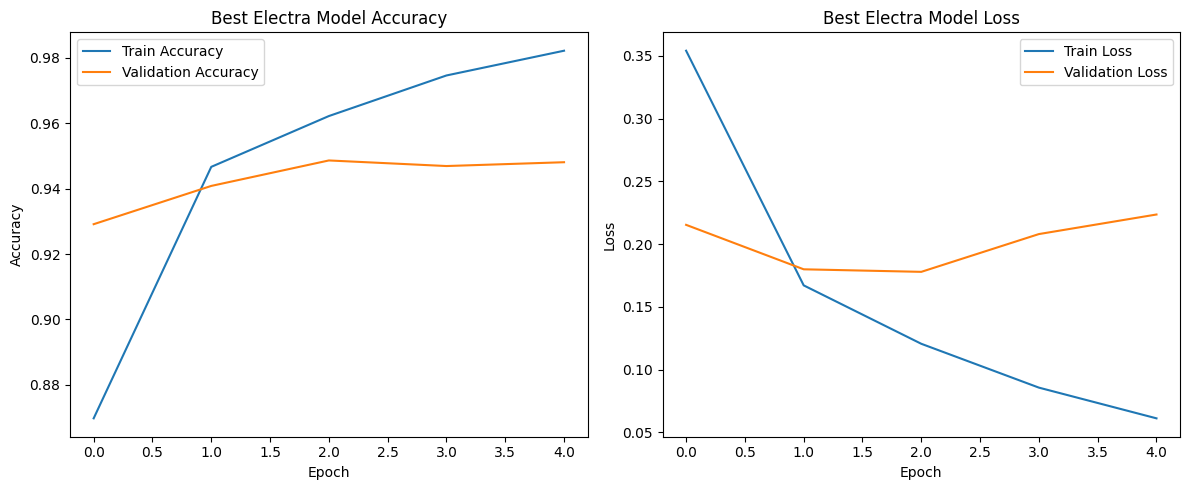

In [98]:
best_electra_checkpoint_filename = electra_results_df.iloc[0]["checkpoint"]
matched_key = None
for key in electra_all_histories.keys():
    if best_electra_checkpoint_filename in key:
        matched_key = key
        break

if matched_key is None:
    raise KeyError(f"Could not find history for {best_electra_checkpoint_filename} in electra_all_histories")

best_electra_history = electra_all_histories[matched_key]

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(best_electra_history["train_accuracies"], label="Train Accuracy")
plt.plot(best_electra_history["val_accuracies"], label="Validation Accuracy")
plt.title("Best Electra Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(best_electra_history["train_losses"], label="Train Loss")
plt.plot(best_electra_history["val_losses"], label="Validation Loss")
plt.title("Best Electra Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

The plots show the training and validation accuracy and loss of the ELECTRA model across five epochs. The training accuracy increases steadily from approximately 0.87 to 0.98, indicating that the model continues to learn the training data effectively throughout the training process. In comparison, validation accuracy improves initially from around 0.93 to 0.95 by epoch 2, but then remains relatively stable with only minor fluctuations in later epochs.  

The loss curves show a similar pattern. Training loss decreases consistently from about 0.35 to 0.06, demonstrating improved fit to the training data. However, validation loss decreases only during the early epochs, reaching its lowest point at around 0.18, before increasing again to approximately 0.22 by the final epoch. This divergence between training and validation loss indicates that the model begins to overfit after the early stages of training.  



###### 5.2.3.4.3 ELECTRA Model Evaluation on Validation Dataset

In [99]:
# Validation evaluation for best BERT model
val_preds_electra = []
val_labels_electra = []

# Define bert_val_loader, as it might have been skipped during hyperparameter search resume
electra_val_loader = DataLoader(
    electra_val_dataset,
    batch_size=best_electra_params["batch_size"],
    shuffle=False,
    num_workers=0,
    drop_last=False
)

best_model_electra.eval()

# Explicitly ensure the model and its submodules are in float32 just before inference
best_model_electra.float() # Ensure top-level model parameters are float32

# Also explicitly ensure the internal electra model operates in float32
# This targets the potential source of float16 outputs from the pre-trained model
if hasattr(best_model_electra, 'electra'):
    best_model_electra.electra.float()

with torch.no_grad():
    for batch in electra_val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = best_model_electra(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        _, predicted = torch.max(outputs, 1)

        val_preds_electra.extend(predicted.cpu().numpy())
        val_labels_electra.extend(labels.cpu().numpy())

val_preds_electra = np.array(val_preds_electra)
val_labels_electra = np.array(val_labels_electra)

val_accuracy_electra = (val_preds_electra == val_labels_electra).mean()
print(f"Electra Validation Accuracy: {val_accuracy_electra:.4f}")

Electra Validation Accuracy: 0.9486


In [100]:
# ----------------------------
# Classification Report
# ----------------------------
class_names = ["World", "Sports", "Business", "Sci/Tech"]

print("\nElectra Classification Report on Validation Set:")
print(classification_report(val_labels_electra, val_preds_electra, target_names=class_names))


Electra Classification Report on Validation Set:
              precision    recall  f1-score   support

       World       0.97      0.95      0.96      6000
      Sports       0.98      0.99      0.99      6000
    Business       0.95      0.90      0.92      6000
    Sci/Tech       0.90      0.96      0.93      6000

    accuracy                           0.95     24000
   macro avg       0.95      0.95      0.95     24000
weighted avg       0.95      0.95      0.95     24000



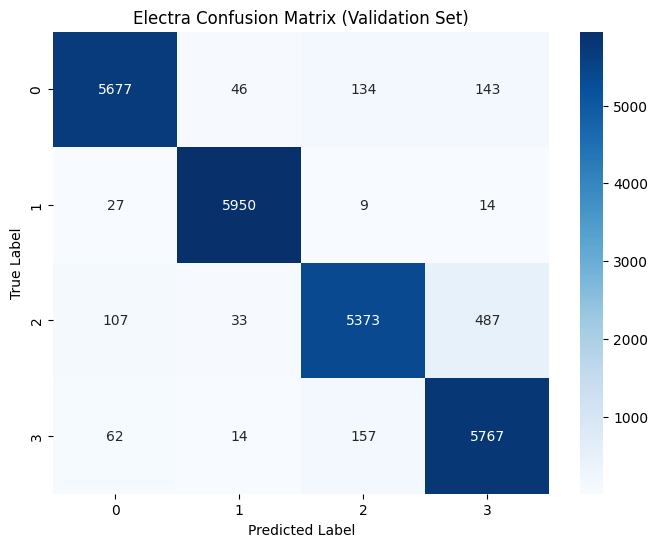

In [101]:
# ----------------------------
# Confusion Matrix
# ----------------------------
cm_electra_val = confusion_matrix(val_labels_electra, val_preds_electra)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_electra_val, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Electra Confusion Matrix (Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [102]:
# ----------------------------
# Per-Class Accuracy
# ----------------------------
class_names = ["World", "Sports", "Business", "Sci/Tech"]

print("Each Class Accuracy of Electra Model (Validation Set):")
print("-" * 50)

for i, class_name in enumerate(class_names):
    correct = cm_electra_val[i, i]
    total = cm_electra_val[i].sum()
    accuracy = (correct / total) * 100
    print(
        f"{class_name}: Accuracy = "
        f"{accuracy:.2f}% "
        f"({correct}/{total})"
    )

Each Class Accuracy of Electra Model (Validation Set):
--------------------------------------------------
World: Accuracy = 94.62% (5677/6000)
Sports: Accuracy = 99.17% (5950/6000)
Business: Accuracy = 89.55% (5373/6000)
Sci/Tech: Accuracy = 96.12% (5767/6000)


###### 5.2.3.4.4 ELECTRA Model Evaluation on Test Dataset
After selecting the best-performing model based on validation performance, inference was performed on the unseen test dataset to assess the model's generalization capability. Final classification metrics, including accuracy, precision, recall, and F1-score, were computed to provide a comprehensive assessment of the model's effectiveness on previously unseen news articles.

In [103]:
# Test evaluation for best ELECTRA model
test_preds_electra = []
test_labels_electra = []

# Define electra_test_loader
best_batch_size_electra = best_electra_params["batch_size"]
electra_test_loader = DataLoader(
    electra_test_dataset,
    batch_size=best_batch_size_electra,
    shuffle=False,
    num_workers=0,
    drop_last=False
)

best_model_electra.eval()

with torch.no_grad():
    for batch in electra_test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = best_model_electra(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        _, predicted = torch.max(outputs, 1)

        test_preds_electra.extend(predicted.cpu().numpy())
        test_labels_electra.extend(labels.cpu().numpy())

test_preds_electra = np.array(test_preds_electra)
test_labels_electra = np.array(test_labels_electra)

test_accuracy_electra = (test_preds_electra == test_labels_electra).mean()
print(f"Electra Test Accuracy: {test_accuracy_electra:.4f}")

Electra Test Accuracy: 0.9463


In [104]:
# ----------------------------
# Classification Report
# ----------------------------
print("\nElectra Classification Report on Test Set:")
print(classification_report(test_labels_electra, test_preds_electra, target_names=class_names))


Electra Classification Report on Test Set:
              precision    recall  f1-score   support

       World       0.97      0.95      0.96      1900
      Sports       0.98      0.99      0.99      1900
    Business       0.95      0.89      0.91      1900
    Sci/Tech       0.89      0.96      0.92      1900

    accuracy                           0.95      7600
   macro avg       0.95      0.95      0.95      7600
weighted avg       0.95      0.95      0.95      7600



The classification results for the ELECTRA model on the test set demonstrate strong overall performance, achieving an accuracy of 0.95. The macro and weighted averages for precision, recall, and F1-score are all 0.95, indicating consistent and balanced performance across all classes.  

At the class level, the model performs particularly well on the Sports category, with precision and recall reaching 0.98 and 0.99, respectively, resulting in an F1-score of 0.99. The World category also shows strong performance, with an F1-score of 0.96, reflecting reliable classification of global news content.  

Performance is slightly lower for the Business category, where recall (0.89) is noticeably reduced despite a relatively high precision (0.95), suggesting that some instances are misclassified into other categories. Conversely, the Sci/Tech category exhibits higher recall (0.96) than precision (0.89), indicating that the model effectively captures relevant samples but introduces more false positives.  


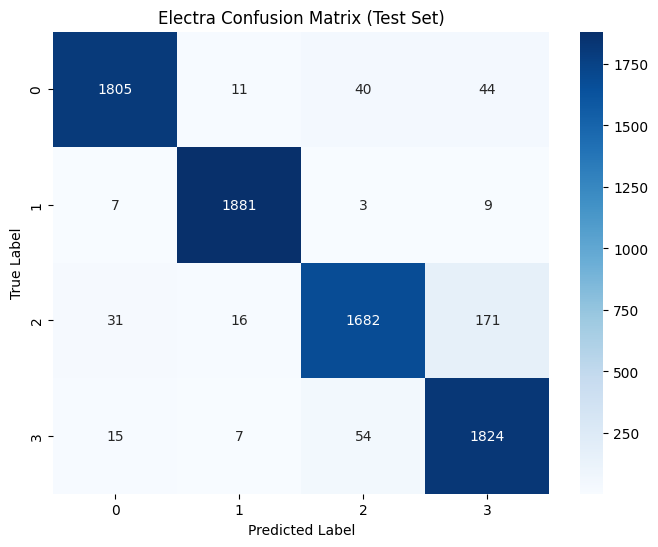

In [105]:
# ----------------------------
# Confusion Matrix
# ----------------------------
cm_electra_test = confusion_matrix(test_labels_electra, test_preds_electra)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_electra_test, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Electra Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The confusion matrix shows strong overall performance, with high correct classifications across all categories, particularly Sports (1881) and Sci/Tech (1824). Most errors occur between Business and Sci/Tech, where significant misclassification is observed, indicating difficulty distinguishing between these similar categories.

In [106]:
# ----------------------------
# Per-Class Accuracy
# ----------------------------
class_names = ["World", "Sports", "Business", "Sci/Tech"]

print("Each Class Accuracy of Electra Model (Test Set):")
print("-" * 50)

for i, class_name in enumerate(class_names):
    correct = cm_electra_test[i, i]
    total = cm_electra_test[i].sum()
    accuracy = (correct / total) * 100
    print(
        f"{class_name}: Accuracy = "
        f"{accuracy:.2f}% "
        f"({correct}/{total})"
    )

Each Class Accuracy of Electra Model (Test Set):
--------------------------------------------------
World: Accuracy = 95.00% (1805/1900)
Sports: Accuracy = 99.00% (1881/1900)
Business: Accuracy = 88.53% (1682/1900)
Sci/Tech: Accuracy = 96.00% (1824/1900)


#### 5.2.4 Ensemble: DeBERTa-RoBERTa-ELECTRA
Ensemble learning is a machine learning technique that combines the predictions of multiple models to improve overall classification performance and robustness. In this study, an ensemble consisting of RoBERTa, DeBERTa, and ELECTRA was developed for text classification.  

Although all three models are based on the transformer architecture, each employs different pretraining strategies and architectural enhancements.  

RoBERTa improves upon BERT through optimized pretraining procedures and larger training corpora, DeBERTa introduces disentangled attention mechanisms to better capture contextual relationships between words, and ELECTRA utilizes a Replaced Token Detection objective that enables more sample-efficient pretraining.  

By combining the predictions of these diverse transformer models through soft-voting, the ensemble leverages the complementary strengths of each architecture while reducing model-specific errors.  

This approach often results in improved generalization and higher classification accuracy compared to individual transformer models.

##### 5.2.4.1 Load Seed Emsemble
This section loads the saved checkpoints of transformer models trained with different random seeds. These models are subsequently used to perform ensemble inference through weighted soft voting.

In [107]:
%%capture
# ==================================================
# LOAD DEBERTA SEED ENSEMBLE
# ==================================================

deberta_seed_paths = [
    SAVED_MODELS_DIR / "deberta_seed42_best.pth",
    SAVED_MODELS_DIR / "deberta_seed123_best.pth",
    SAVED_MODELS_DIR / "deberta_seed999_best.pth",
    SAVED_MODELS_DIR / "deberta_seed2025_best.pth",
    SAVED_MODELS_DIR / "deberta_seed777_best.pth",
]

deberta_models = []

for checkpoint_path in deberta_seed_paths:

    print(f"Loading {checkpoint_path.name}")

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    params = checkpoint["params"]

    model = DebertaV3Classifier(
        num_classes=4,
        dropout_rate=params["dropout_rate"]
    ).to(device)

    if checkpoint.get("best_model_state_dict") is None:
        raise ValueError(
            f"best_model_state_dict missing in {checkpoint_path}"
        )

    model.load_state_dict(
        checkpoint["best_model_state_dict"]
    )

    model.float()
    model.eval()

    deberta_models.append(model)

print(
    f"\nLoaded {len(deberta_models)} DeBERTa seed models."
)

In [108]:
%%capture
# ==================================================
# LOAD ROBERTA SEED ENSEMBLE
# ==================================================

roberta_seed_paths = [
    SAVED_MODELS_DIR / "roberta_seed42_best.pth",
    SAVED_MODELS_DIR / "roberta_seed123_best.pth",
    SAVED_MODELS_DIR / "roberta_seed999_best.pth",
    SAVED_MODELS_DIR / "roberta_seed2025_best.pth",
    SAVED_MODELS_DIR / "roberta_seed777_best.pth"
]

roberta_models = []

for checkpoint_path in roberta_seed_paths:

    print(f"Loading {checkpoint_path.name}")

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    params = checkpoint["params"]

    model = RobertaClassifier(
        num_classes=4,
        dropout_rate=params["dropout_rate"]
    ).to(device)

    if checkpoint.get("best_model_state_dict") is None:
        raise ValueError(
            f"best_model_state_dict missing in {checkpoint_path}"
        )

    model.load_state_dict(
        checkpoint["best_model_state_dict"]
    )

    model.float()
    model.eval()

    roberta_models.append(model)

print(
    f"\nLoaded {len(roberta_models)} RoBERTa seed models."
)

In [109]:
%%capture
# ==================================================
# LOAD ELECTRA SEED ENSEMBLE
# ==================================================

electra_seed_paths = [
    SAVED_MODELS_DIR / "electra_seed42_best.pth",
    SAVED_MODELS_DIR / "electra_seed123_best.pth",
    SAVED_MODELS_DIR / "electra_seed999_best.pth",
    SAVED_MODELS_DIR / "electra_seed2025_best.pth",
    SAVED_MODELS_DIR / "electra_seed777_best.pth"
]

electra_models = []

for checkpoint_path in electra_seed_paths:

    print(f"Loading {checkpoint_path.name}")

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    params = checkpoint["params"]

    model = ElectraClassifier(
        num_classes=4,
        dropout_rate=params["dropout_rate"]
    ).to(device)

    if checkpoint.get("best_model_state_dict") is None:
        raise ValueError(
            f"best_model_state_dict missing in {checkpoint_path}"
        )

    model.load_state_dict(
        checkpoint["best_model_state_dict"]
    )

    model.float()
    model.eval()

    electra_models.append(model)

print(
    f"\nLoaded {len(electra_models)} ELECTRA seed models."
)

##### 5.2.4.2 Build Ensemble Loaders
The ensemble employed running across the three pre-trained Transformers models.   

Each model produces probabilities, which are averaged to get a single prediction per architecture (ensemble averaging).
These averaged predictions and true labels are then stored across all batches.
Finally, all batches are concatenated to create full dataset-level prediction tensors for evaluation or further ensembling.

In [110]:
# ------------------------------------
# COLLECT ARCHITECTURE PREDICTIONS
# ------------------------------------

all_roberta_avg = []
all_deberta_avg = []
all_electra_avg = []
all_labels = []

with torch.no_grad():

    for roberta_batch, deberta_batch, electra_batch in zip(
        roberta_test_loader,
        deberta_test_loader,
        electra_test_loader
    ):

        # RoBERTa
        roberta_input_ids = roberta_batch["input_ids"].to(device)
        roberta_attention_mask = roberta_batch["attention_mask"].to(device)

        # DeBERTa
        deberta_input_ids = deberta_batch["input_ids"].to(device)
        deberta_attention_mask = deberta_batch["attention_mask"].to(device)

        # ELECTRA
        electra_input_ids = electra_batch["input_ids"].to(device)
        electra_attention_mask = electra_batch["attention_mask"].to(device)

        labels = deberta_batch["labels"].to(device)

        # ----------------------------
        # RoBERTa ensemble
        # ----------------------------
        roberta_probs = []

        for model in roberta_models:

            logits = model(
                input_ids=roberta_input_ids,
                attention_mask=roberta_attention_mask
            )

            roberta_probs.append(
                torch.softmax(logits, dim=1)
            )

        roberta_avg = torch.stack(
            roberta_probs
        ).mean(dim=0)

        # ----------------------------
        # DeBERTa ensemble
        # ----------------------------
        deberta_probs = []

        for model in deberta_models:

            logits = model(
                input_ids=deberta_input_ids,
                attention_mask=deberta_attention_mask
            )

            deberta_probs.append(
                torch.softmax(logits, dim=1)
            )

        deberta_avg = torch.stack(
            deberta_probs
        ).mean(dim=0)

        # ----------------------------
        # ELECTRA ensemble
        # ----------------------------
        electra_probs = []

        for model in electra_models:

            logits = model(
                input_ids=electra_input_ids,
                attention_mask=electra_attention_mask
            )

            electra_probs.append(
                torch.softmax(logits, dim=1)
            )

        electra_avg = torch.stack(
            electra_probs
        ).mean(dim=0)

        # ----------------------------
        # Store batch results
        # ----------------------------
        all_roberta_avg.append(
            roberta_avg.cpu()
        )

        all_deberta_avg.append(
            deberta_avg.cpu()
        )

        all_electra_avg.append(
            electra_avg.cpu()
        )

        all_labels.append(
            labels.cpu()
        )

# ------------------------------------
# COMBINE ALL BATCHES
# ------------------------------------
all_roberta_avg = torch.cat(
    all_roberta_avg,
    dim=0
)

all_deberta_avg = torch.cat(
    all_deberta_avg,
    dim=0
)

all_electra_avg = torch.cat(
    all_electra_avg,
    dim=0
)

all_labels = torch.cat(
    all_labels,
    dim=0
)

print(all_roberta_avg.shape)
print(all_deberta_avg.shape)
print(all_electra_avg.shape)
print(all_labels.shape)

torch.Size([7600, 4])
torch.Size([7600, 4])
torch.Size([7600, 4])
torch.Size([7600])


Next, instead of using one global weight for all classes, we performed a grid search or class-wise weighting to find the best class-specific ensemble weights across RoBERTa, DeBERTa, and ELECTRA. This is because each class may be better predicted by different models (e.g., RoBERTa good for Business, DeBERTa better for SciTech).

World and Sports were fixed to reduce search complexity and because we already had strong, stable weights for those classes, while Business and SciTech weights are explored systematically (in 10% steps).
For each combination, it:
- Combines model predictions using weighted sums (per class).
- Picks predicted labels (argmax).
- Computes accuracy against true labels.

We find the 10 best weight combinations and whichever is the top will be used for the ensemble evaluation.

In [111]:
# ------------------------------------
# CLASS-SPECIFIC WEIGHT GRID SEARCH
# ------------------------------------
best_acc = 0
best_config = None

results = []

# Fixed weights based on your earlier results
WORLD_WEIGHTS  = [0.45, 0.45, 0.10]
SPORTS_WEIGHTS = [0.40, 0.40, 0.20]

# Search in 10% increments
for r_b in range(0, 101, 10):
    for d_b in range(0, 101 - r_b, 10):

        e_b = 100 - r_b - d_b

        for r_s in range(0, 101, 10):
            for d_s in range(0, 101 - r_s, 10):

                e_s = 100 - r_s - d_s

                class_weights = torch.tensor([
                    WORLD_WEIGHTS,                         # World
                    SPORTS_WEIGHTS,                        # Sports
                    [r_b/100, d_b/100, e_b/100],          # Business
                    [r_s/100, d_s/100, e_s/100],          # SciTech
                ])

                ensemble_probs = torch.zeros_like(
                    all_roberta_avg
                )

                # World
                ensemble_probs[:, 0] = (
                    class_weights[0, 0] * all_roberta_avg[:, 0]
                    + class_weights[0, 1] * all_deberta_avg[:, 0]
                    + class_weights[0, 2] * all_electra_avg[:, 0]
                )

                # Sports
                ensemble_probs[:, 1] = (
                    class_weights[1, 0] * all_roberta_avg[:, 1]
                    + class_weights[1, 1] * all_deberta_avg[:, 1]
                    + class_weights[1, 2] * all_electra_avg[:, 1]
                )

                # Business
                ensemble_probs[:, 2] = (
                    class_weights[2, 0] * all_roberta_avg[:, 2]
                    + class_weights[2, 1] * all_deberta_avg[:, 2]
                    + class_weights[2, 2] * all_electra_avg[:, 2]
                )

                # SciTech
                ensemble_probs[:, 3] = (
                    class_weights[3, 0] * all_roberta_avg[:, 3]
                    + class_weights[3, 1] * all_deberta_avg[:, 3]
                    + class_weights[3, 2] * all_electra_avg[:, 3]
                )

                preds = ensemble_probs.argmax(dim=1)

                acc = (
                    preds == all_labels
                ).float().mean().item()

                results.append(
                    (
                        acc,
                        [r_b/100, d_b/100, e_b/100],
                        [r_s/100, d_s/100, e_s/100]
                    )
                )

                if acc > best_acc:

                    best_acc = acc

                    best_config = {
                        "World": WORLD_WEIGHTS,
                        "Sports": SPORTS_WEIGHTS,
                        "Business": [
                            r_b/100,
                            d_b/100,
                            e_b/100
                        ],
                        "SciTech": [
                            r_s/100,
                            d_s/100,
                            e_s/100
                        ]
                    }

# ------------------------------------
# TOP RESULTS
# ------------------------------------

results.sort(
    key=lambda x: x[0],
    reverse=True
)

print("\nTOP 10 CONFIGURATIONS")
print("=" * 80)

for rank, (acc, business_w, scitech_w) in enumerate(results[:10], start=1):

    print(
        f"{rank:2d}. "
        f"Acc={acc:.4f} | "
        f"Business={business_w} | "
        f"SciTech={scitech_w}"
    )

print("\nBEST CONFIGURATION")
print("=" * 80)

print(f"Accuracy: {best_acc:.4f}")

for cls, weights in best_config.items():

    print(
        f"{cls:<10} "
        f"RoBERTa={weights[0]:.2f} "
        f"DeBERTa={weights[1]:.2f} "
        f"ELECTRA={weights[2]:.2f}"
    )


TOP 10 CONFIGURATIONS
 1. Acc=0.9572 | Business=[0.8, 0.1, 0.1] | SciTech=[1.0, 0.0, 0.0]
 2. Acc=0.9571 | Business=[0.8, 0.0, 0.2] | SciTech=[1.0, 0.0, 0.0]
 3. Acc=0.9571 | Business=[0.8, 0.2, 0.0] | SciTech=[1.0, 0.0, 0.0]
 4. Acc=0.9568 | Business=[0.7, 0.0, 0.3] | SciTech=[1.0, 0.0, 0.0]
 5. Acc=0.9568 | Business=[0.8, 0.0, 0.2] | SciTech=[0.4, 0.4, 0.2]
 6. Acc=0.9568 | Business=[0.8, 0.0, 0.2] | SciTech=[0.8, 0.2, 0.0]
 7. Acc=0.9568 | Business=[0.8, 0.0, 0.2] | SciTech=[0.9, 0.1, 0.0]
 8. Acc=0.9568 | Business=[0.8, 0.2, 0.0] | SciTech=[0.5, 0.1, 0.4]
 9. Acc=0.9568 | Business=[0.9, 0.0, 0.1] | SciTech=[1.0, 0.0, 0.0]
10. Acc=0.9567 | Business=[0.6, 0.0, 0.4] | SciTech=[1.0, 0.0, 0.0]

BEST CONFIGURATION
Accuracy: 0.9572
World      RoBERTa=0.45 DeBERTa=0.45 ELECTRA=0.10
Sports     RoBERTa=0.40 DeBERTa=0.40 ELECTRA=0.20
Business   RoBERTa=0.80 DeBERTa=0.10 ELECTRA=0.10
SciTech    RoBERTa=1.00 DeBERTa=0.00 ELECTRA=0.00


##### 5.3.4.3 Ensemble Evaluation
So applying the **best configuration** above would give us the following:

In [112]:
# ------------------------------------
# APPLY BEST CONFIGURATION
# ------------------------------------

class_weights = torch.tensor([
    best_config["World"],
    best_config["Sports"],
    best_config["Business"],
    best_config["SciTech"]
])

ensemble_probs = torch.zeros_like(all_roberta_avg)

for c in range(4):

    ensemble_probs[:, c] = (
        class_weights[c, 0] * all_roberta_avg[:, c]
        + class_weights[c, 1] * all_deberta_avg[:, c]
        + class_weights[c, 2] * all_electra_avg[:, c]
    )

ensemble_preds = (
    ensemble_probs.argmax(dim=1)
    .cpu()
    .numpy()
)

ensemble_labels = (
    all_labels.cpu()
    .numpy()
)

print(f"Final Ensemble Accuracy: {best_acc:.4f}")

Final Ensemble Accuracy: 0.9572


In [113]:
# ----------------------------
# Classification Report
# ----------------------------
class_names = [
    "World",
    "Sports",
    "Business",
    "Sci/Tech"
]

print(
    classification_report(
        ensemble_labels,
        ensemble_preds,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       World       0.97      0.96      0.97      1900
      Sports       0.99      0.99      0.99      1900
    Business       0.94      0.92      0.93      1900
    Sci/Tech       0.93      0.95      0.94      1900

    accuracy                           0.96      7600
   macro avg       0.96      0.96      0.96      7600
weighted avg       0.96      0.96      0.96      7600



The classification report shows strong overall performance, achieving an accuracy of 0.96, with balanced precision, recall, and F1-scores across all classes. The Sports category performs best, reaching near-perfect scores (0.99), while World also shows very high and consistent performance (0.97 F1-score).  

Slightly lower results are observed for Business (0.93 F1-score) and Sci/Tech (0.94 F1-score), indicating some remaining difficulty in distinguishing between these semantically similar categories.

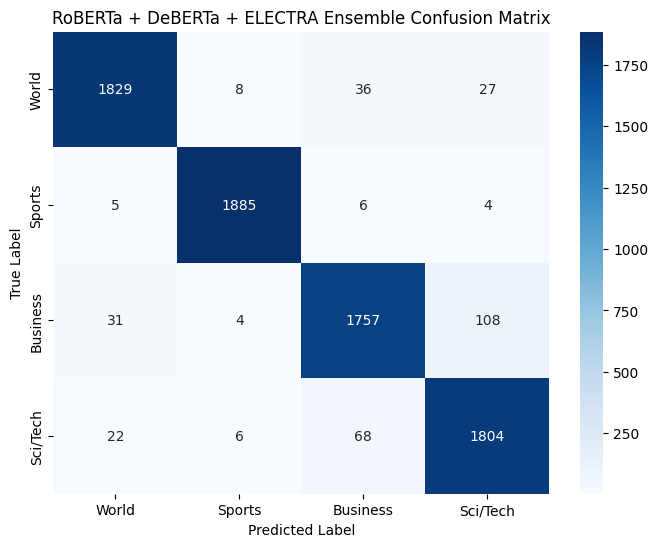

In [114]:
# ----------------------------
# Confusion Matrix
# ----------------------------
cm_ensemble = confusion_matrix(
    ensemble_labels,
    ensemble_preds
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_ensemble,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "RoBERTa + DeBERTa + ELECTRA Ensemble Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

The confusion matrix shows improved overall performance, with high correct classifications across all categories, particularly Sports (1885) and World (1829). Misclassifications are reduced compared to individual models, though some confusion still exists between Business and Sci/Tech (e.g., 108 and 68 instances).  

Overall, the ensemble model demonstrates stronger and more balanced classification, with fewer errors and better distinction across categories.

In [115]:
# ----------------------------
# Per-Class Accuracy
# ----------------------------
print(
    "Each Class Accuracy of the RoBERTa + DeBERTa + ELECTRA Ensemble Model"
)

print("-" * 50)

for i, class_name in enumerate(class_names):

    correct = cm_ensemble[i, i]
    total = cm_ensemble[i].sum()

    accuracy = (
        correct / total
    ) * 100

    print(
        f"{class_name}: Accuracy = "
        f"{accuracy:.2f}% "
        f"({correct}/{total})"
    )

Each Class Accuracy of the RoBERTa + DeBERTa + ELECTRA Ensemble Model
--------------------------------------------------
World: Accuracy = 96.26% (1829/1900)
Sports: Accuracy = 99.21% (1885/1900)
Business: Accuracy = 92.47% (1757/1900)
Sci/Tech: Accuracy = 94.95% (1804/1900)


The per-class accuracy results show strong and balanced performance across all categories, with Sports achieving the highest accuracy (99.21%), followed by World (96.26%) and Sci/Tech (94.95%). The Business category has the lowest accuracy (92.47%), indicating it remains the most challenging class to classify.  

Overall, the ensemble model demonstrates improved and consistent performance, with high accuracy across all classes and reduced classification errors compared to individual models.

# 6. Model Evaluation and Performance Results
---
**Comparison of BiLSTM-Attention vs DeBERTa-v3 vs RoBERTa vs ELECTRA Accuracy Plots.**

The plots below show the training and validation accuracy over epochs for the best-performing BiLSTM-Attention and the three different Transformers models on the AG News Classification dataset.

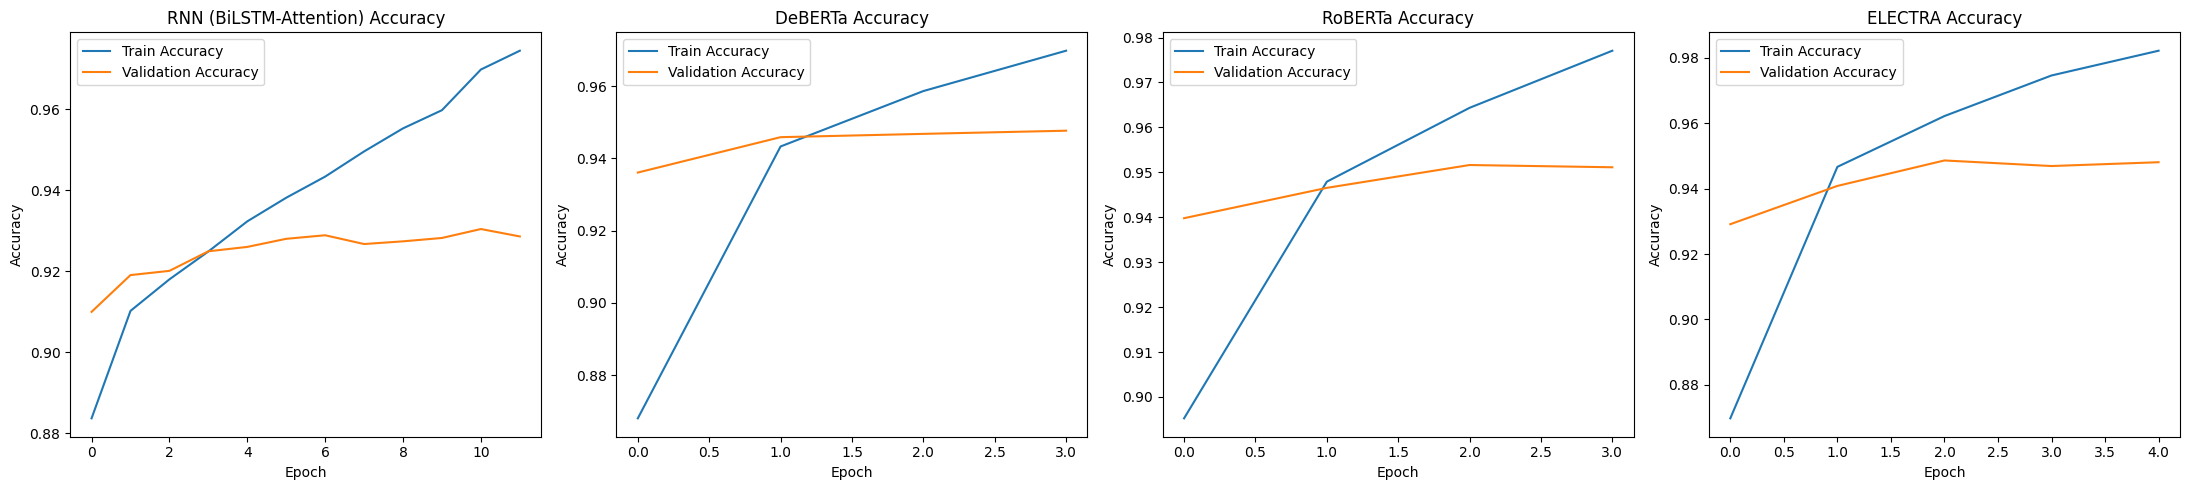

In [116]:
# ------------------------------------
# LOAD BEST HISTORIES
# ------------------------------------
best_rnn_history = rnn_all_histories[
    str(SAVED_MODELS_DIR / rnn_results_df.iloc[0]["checkpoint"])
]

best_deberta_history = deberta_all_histories[
    str(SAVED_MODELS_DIR / deberta_results_df.iloc[0]["checkpoint"])
]

best_roberta_history = roberta_all_histories[
    str(SAVED_MODELS_DIR / roberta_results_df.iloc[0]["checkpoint"].replace("roberta", "bert"))
]

best_electra_checkpoint_filename = electra_results_df.iloc[0]["checkpoint"]
matched_key = None
for key in electra_all_histories.keys():
    if best_electra_checkpoint_filename in key:
        matched_key = key
        break

if matched_key is None:
    raise KeyError(
        f"Could not find history for {best_electra_checkpoint_filename} in electra_all_histories"
    )

best_electra_history = electra_all_histories[matched_key]

# ------------------------------------
# ACCURACY PLOTS SIDE BY SIDE
# ------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# RNN
axes[0].plot(best_rnn_history["train_accuracies"], label="Train Accuracy")
axes[0].plot(best_rnn_history["val_accuracies"], label="Validation Accuracy")
axes[0].set_title("RNN (BiLSTM-Attention) Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# DeBERTa
axes[1].plot(best_deberta_history["train_accuracies"], label="Train Accuracy")
axes[1].plot(best_deberta_history["val_accuracies"], label="Validation Accuracy")
axes[1].set_title("DeBERTa Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

# RoBERTa
axes[2].plot(best_roberta_history["train_accuracies"], label="Train Accuracy")
axes[2].plot(best_roberta_history["val_accuracies"], label="Validation Accuracy")
axes[2].set_title("RoBERTa Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].legend()

# ELECTRA
axes[3].plot(best_electra_history["train_accuracies"], label="Train Accuracy")
axes[3].plot(best_electra_history["val_accuracies"], label="Validation Accuracy")
axes[3].set_title("ELECTRA Accuracy")
axes[3].set_xlabel("Epoch")
axes[3].set_ylabel("Accuracy")
axes[3].legend()

plt.tight_layout()
plt.show()


From the plots above, it can be seen that the training accuracy consistently increases in all models, while validation accuracy plateaus early (around epoch 2-3) and then remains mostly flat.

There is also a clear gap between training and validation accuracy in later epochs, which strongly suggests overfitting. So continuing training past the 2-3 epoch does not improve generalization.

Validation accuracy also stabilizes very early, which suggests that the dataset may be limited, or models quickly capture learnable patterns.

The BiLSTM + Attention model shows the train vs validation accuracy gap after epoch ~4. Validation slightly fluctuates but does not improve meaningfully after early epochs. This means that the model learns gradually but eventually overfits.

Looking at the DeBERTa-v3 model, rapid improvement can already be seen in the first epoch. Validation stabilizes early (around epoch 1-2). This means that there's a strong initial generalization but early overfitting also begins quickly. It also shows better validation performance than RNN.

The RoBERTa model, shows the best training curve growth among models.
Validation peaks around epoch 2-3 and then stagnates. This suggests that RoBERTa is a high capacity model that fits the training data extremely well.
But, overfitting is more pronounced, as training continues improving but validation does not.

Finally, ELECTRA shows as having the fastest and strongest training performance.
Validation slightly fluctuates but shows no sustained improvement after epoch 2.
It has the best training performance overall, but generalization does not scale with it. It shows similar overfitting trend as RoBERTa.

Overall, all transformer models significantly outperform RNN as they were able to learn richer contextual representations more efficiently, resulting in stronger classification performance on the AG News dataset.



**Comparison of BiLSTM-Attention vs DeBERTa-v3 vs RoBERTa vs ELECTRA Loss Plots.**  
The plots below show the training and validation loss over epochs for the best-performing BiLSTM-Attention and the three different Transformers models on the AG News Clkassification dataset.

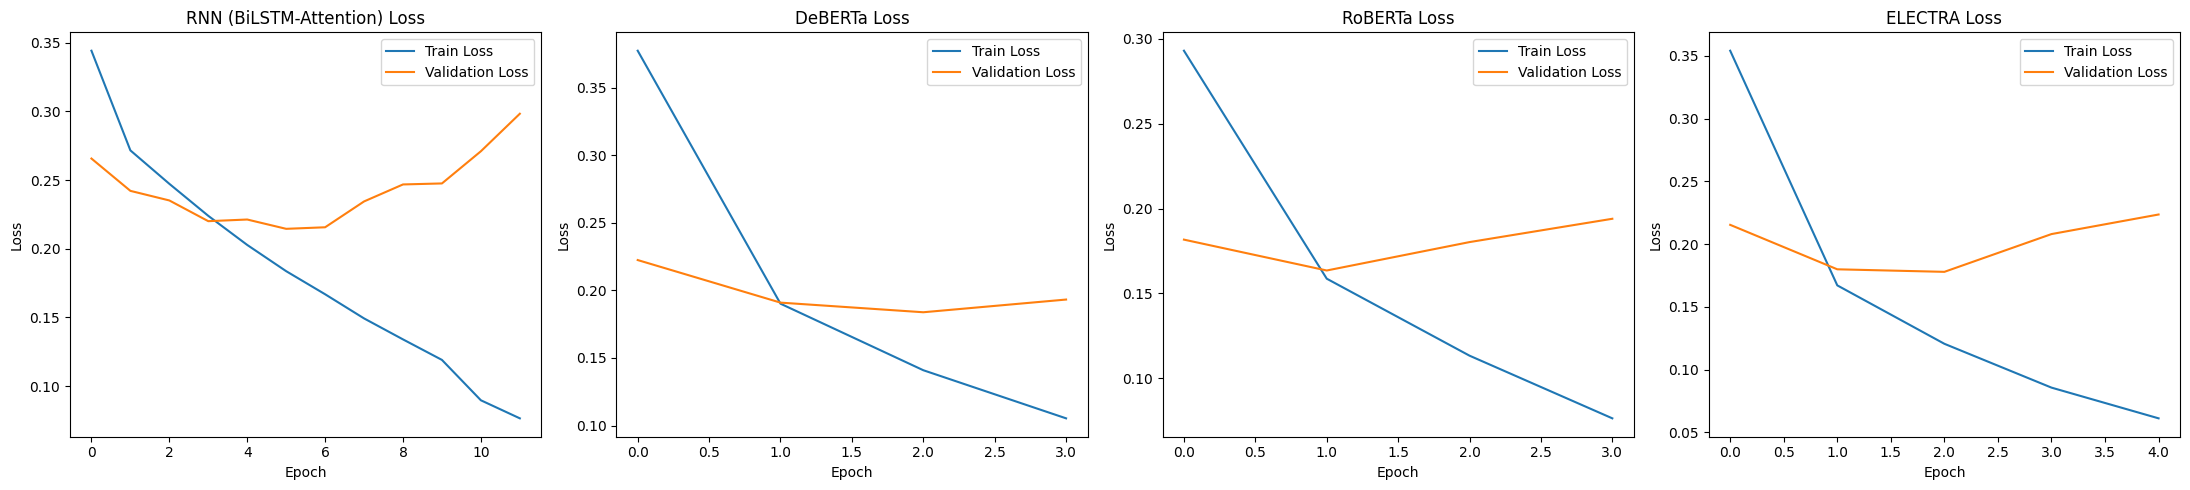

In [117]:
# ------------------------------------
# LOSS PLOTS SIDE BY SIDE
# ------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# RNN
axes[0].plot(best_rnn_history["train_losses"], label="Train Loss")
axes[0].plot(best_rnn_history["val_losses"], label="Validation Loss")
axes[0].set_title("RNN (BiLSTM-Attention) Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# DeBERTa
axes[1].plot(best_deberta_history["train_losses"], label="Train Loss")
axes[1].plot(best_deberta_history["val_losses"], label="Validation Loss")
axes[1].set_title("DeBERTa Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

# RoBERTa
axes[2].plot(best_roberta_history["train_losses"], label="Train Loss")
axes[2].plot(best_roberta_history["val_losses"], label="Validation Loss")
axes[2].set_title("RoBERTa Loss")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].legend()

# ELECTRA
axes[3].plot(best_electra_history["train_losses"], label="Train Loss")
axes[3].plot(best_electra_history["val_losses"], label="Validation Loss")
axes[3].set_title("ELECTRA Loss")
axes[3].set_xlabel("Epoch")
axes[3].set_ylabel("Loss")
axes[3].legend()

plt.tight_layout()
plt.show()

The plots above show the loss curves (training vs validation) for the same four models. Loss complements accuracy, so it helps confirm (or challenge) the earlier conclusions — and here it strongly confirms overfitting behavior across all models.

Training loss consistently decreases which means that all models are learning the training data very well. Validation loss decreases initially, then increases or plateaus, which is a classic sign of overfitting. The turning point (best generalization) happens very early (epoch 1-3). These things align perfectly with what we saw in the accuracy plots above.

For the BiLSTM + Attention model, increase in validation loss is quite severe, which suggests that the model memorizes training data. The validation degradation is stronger than in transformer models.

For DeBERTa model, overfitting begins early (after epoch 2). However, the increase is mild, which makes it more stable than RNN. There's a good balance between learning and generalization.

For RoBERTa model, best validation loss achieved very early (epoch 1).There is a continuous increase afterward, which is consistent to overfitting. It is a very powerful model, but overfits quickly, so it needs strict early stopping.

Finally for ELECTRA model, we see almost the same pattern as RoBERTa, i.e. early generalization then degradation. It has a strong learning capacity but generalization does not keep up. Overfitting is significant after epoch 2.

Overall, even if overfitting is consistent across all models, transformer models still outperform RNN due to them having lower validation loss and better stability, especially DeBERTa.

**Per-Class Accuracy Comparison on all Models.**  
This comparison shows how accurately each model classified each digit from 0 to 9 on the test set.
For each class, the table reports:

In [118]:
class_names = ["World", "Sports", "Business", "Sci/Tech"]

def get_per_class_accuracy_percent(cm):
    results = []
    for i in range(len(class_names)):
        correct = cm[i, i]
        total = cm[i].sum()
        accuracy = (correct / total) * 100 if total > 0 else 0
        results.append(round(accuracy, 2))
    return results

df = pd.DataFrame({
    "Class": class_names,
    "RNN (BiLSTM-Attention)": get_per_class_accuracy_percent(cm_rnn_test),
    "DeBERTa": get_per_class_accuracy_percent(cm_deberta_test),
    "RoBERTa": get_per_class_accuracy_percent(cm_roberta_test),
    "ELECTRA": get_per_class_accuracy_percent(cm_electra_test),
    "Ensemble": get_per_class_accuracy_percent(cm_ensemble)
})

print(df.to_string(index=False))

   Class  RNN (BiLSTM-Attention)  DeBERTa  RoBERTa  ELECTRA  Ensemble
   World                   93.42    95.37    95.58    95.00     96.26
  Sports                   97.84    99.00    98.95    99.00     99.21
Business                   89.68    90.00    91.79    88.53     92.47
Sci/Tech                   91.32    94.16    93.47    96.00     94.95


The side-by-side per-class accuracy comparison shows that transformer-based models outperform the RNN across all news categories. RoBERTa and ELECTRA generally achieve stronger class-level performance, while the ensemble model provides the most balanced and highest overall per-class accuracy. This indicates that combining multiple transformer models improves robustness and class discrimination, especially for more difficult categories such as Business and Sci/Tech.

# 7. Discussion of Model Limitations or Constraints
---

Despite the strong performance achieved by transformer-based models such as DeBERTa, RoBERTa, and ELECTRA, several limitations and constraints were identified during experimentation.

**1. Overfitting Across Models**  
A primary limitation observed in all models is the tendency to overfit the training data. This is evident from the divergence between training and validation performance, where training accuracy continues to improve while validation accuracy plateaus or slightly declines after early epochs. Similarly, validation loss decreases initially but begins to rise after a few epochs, indicating reduced generalization. This suggests that the models are learning dataset-specific patterns rather than capturing broader, transferable features.


**2. Early Performance Saturation**  
Another constraint is the rapid convergence of validation performance. Most models reach peak validation accuracy and minimum validation loss within the first few epochs (typically between epoch 1 and 3). Beyond this point, additional training does not yield improvements and instead contributes to overfitting. This limits the effectiveness of longer training schedules and indicates that the dataset may not provide sufficient complexity or variability for continued learning.


**3. Model Complexity vs. Generalization**  

Although transformer models demonstrate superior training performance compared to the RNN-based approach, this increased capacity comes with the drawback of reduced generalization stability. Models such as RoBERTa and ELECTRA achieve very high training accuracy but exhibit larger gaps between training and validation metrics. This highlights the challenge of balancing model complexity with generalization, particularly when working with limited or moderately sized datasets.


**4. Sensitivity to Hyperparameters**  
The models are sensitive to training configurations such as learning rate, number of epochs, and regularization settings. Small deviations in these parameters can significantly impact performance, especially in high-capacity models. The need for careful tuning increases computational cost and experimental complexity.


**5. Class-wise Performance Imbalance**  
Analysis of per-class accuracy indicates that not all categories are learned equally well. Certain classes, such as Business or Sci/Tech, tend to have lower accuracy compared to others like Sports or World. This disparity may be due to class imbalance, overlapping semantic features between categories, or differences in linguistic complexity. As a result, overall accuracy may mask weaknesses in specific classes.


**6. Computational Resource Requirements**  
Transformer-based models such as DeBERTa, RoBERTa, and ELECTRA require significantly higher computational resources compared to the RNN model, including greater memory usage and longer training times. This can limit their practicality in resource-constrained environments. Additionally, techniques such as model checkpointing, while improving training efficiency by allowing recovery and reuse of trained models, also introduce extra storage and management overhead. As a result, both training and model maintenance contribute to the overall computational cost.


**7. Limited Dataset Representativeness**  
The dataset used for training and evaluation may not fully represent the diversity of real-world data. This can lead to models that perform well on test data but struggle when deployed in more varied or dynamic environments. The early plateau in validation performance further suggests limited variability in the dataset.  


In summary, while transformer-based models achieve high accuracy, their performance is constrained by overfitting, early saturation, sensitivity to hyperparameters, and uneven class-level performance. Addressing these limitations would require improved regularization techniques, more diverse training data, and careful model tuning to enhance generalization and robustness.

# 8. Potential Business Impact and Real-World Applications
---

The developed text classification models have significant potential for real-world applications across industries that handle large volumes of textual data. In the news and media sector, these models can support automated categorisation of articles, enabling **faster content organisation, improved searchability, and personalised content recommendations for users**, leading to improved user experience and higher engagement. Additionally, accurate topic classification **supports targeted advertising**, allowing organisations to deliver more relevant ads based on article categories.

In business environments, such models can be applied to customer feedback analysis, email classification, and document management, helping organisations streamline workflows and reduce manual effort. For example, automatically categorising incoming messages or reports can improve operational efficiency and decision-making speed.  

Additionally, the ensemble approach demonstrates improved and more balanced performance across categories, making it suitable for applications that require higher accuracy and reliability, such as content moderation or information filtering systems.  

Overall, the use of advanced models such as DeBERTa, RoBERTa, and ELECTRA can lead to cost savings, increased productivity, and enhanced data-driven insights, although these benefits must be balanced against computational requirements in deployment.

# 9. Future Improvements / Future Work
---

Several opportunities exist to further improve model performance and robustness. Applying stronger **regularization techniques** and **more effective early stopping** can help reduce overfitting and improve generalization. Further **hyperparameter tuning**, including learning rate schedules and batch size optimisation, may also enhance model stability.  

In addition, **expanding the dataset or incorporating more diverse data** could improve performance, particularly for classes with lower accuracy. While this study leveraged pre-trained transformer models, future work could explore **training models from scratch** to better understand dataset-specific learning behaviour and reduce reliance on pre-trained knowledge.  

Finally, experimenting with **more advanced ensemble methods** and optimising models for efficient deployment (e.g., model compression or distillation) would improve both performance and practical applicability.

# 10. Conclusion
---

This study compared the performance of an RNN (BiLSTM with Attention) model and transformer-based models, including DeBERTa, RoBERTa, and ELECTRA, on the AG News text classification task. The results demonstrate that transformer models significantly outperform the RNN model in both accuracy and loss metrics, highlighting their stronger ability to capture contextual information in text data.  

However, all models exhibited signs of overfitting, with validation performance stabilising early despite continued improvement in training metrics. This highlights the importance of applying techniques such as early stopping and regularisation to improve generalisation. Among the evaluated models, the ensemble approach achieved the most balanced and consistent performance across all classes.  

Overall, the findings confirm that while transformer-based models provide superior performance for text classification tasks, careful training and optimisation are required to balance accuracy, generalisation, and computational cost.

# Appendix
---

### A. Hyperparameter Search and Model Training
The following procedure was used during hyperparameter optimization and training for all models used in this project:
1.  Global Progress Tracking
      *   Updated the global experiment state after each completed experiment, enabling interrupted hyperparameter searches to resume automatically from the last completed configuration.
2.  Checkpoint Saving and Recovery
      *   Saved the latest training state, best-performing model weights, hyperparameters, and training history to enable experiment recovery and reproducibility.
3.  Experiment Resume Check
      *   Checked for previously saved experiment checkpoints to determine whether training should resume from an earlier state or start from the beginning.
4.  Hyperparameter Configuration
      *   Iterated through each predefined hyperparameter combination specified in the search grid.
5.  Data Loader Construction
      *   Created training and validation data loaders using the selected batch size for the current experiment.      
6.  Model Initialization
      *   Constructed the model architecture using the current hyperparameter configuration.    
7.  Training Component Setup
      *   Constructed the model architecture using the current hyperparameter configuration.       
8.  Model Training
      *   Trained the model on the training dataset for the specified number of epochs using mini-batch gradient descent.   
9.  Early Stopping
      *   Terminated training when validation performance failed to improve for a predefined number of consecutive epochs, reducing the risk of overfitting and unnecessary computation.       
10.  Validation Evaluation and Experiment Result Storage
      *   Evaluated model performance on the validation dataset after each training epoch and recorded the best validation metrics and checkpoint information for each experiment to facilitate model comparison and final model selection.          
11.  Best Model Selection
      *   Compared validation performance across epochs and retained the model state corresponding to the highest validation accuracy.                


### B. Github Repository
This notebook, together with the needed files as well as saved checkpoints can be cloned from the following github repository and can be run on a computer. Please follow the `README.md`
[https://github.com/yotsubakoiwai/tafe-ictss00120](https://github.com/yotsubakoiwai/tafe-ictss00120)


### C. Google Colaboratory
Likewise, if system does not have sufficient disk space to save the necessary files, it can be run in [Google Colab](https://drive.google.com/drive/folders/1p-nsHgzaz1jSINvlfJm1XxR7XSUgvgol?usp=sharing)